# Machine Learning Project — Client Selection in Federated Learning (MNIST)
**Course:** CS-503/AI211  
**Mentor:** Shradha Sharma

Federated Learning (FL) trains a global model by aggregating **client updates** without sharing raw data. Client data are typically **non-IID** and **unbalanced**, so selecting a **subset of clients** each round can reduce cost and improve convergence.

**Tasks implemented:**
- **Task 1:** DivFL (greedy) [2] and S-FedAvg (Shapley) [3] on MNIST using CNN + at least three additional models (LogReg, Linear SVM, MLP, LeNet).
- **Task 2:** Evaluate DivFL and S-FedAvg under **concept drift** (label/feature, sudden/gradual) [4].
- **Task 3:** Propose a **drift-aware** selector (non-stationary bandit) and compare against Task 2 baselines.

**Experimental setting:** 100 clients, **100 rounds**, partial participation with **K clients per round** (K in {5, 10, 20, 40}), and **local epochs = 2** to balance runtime and accuracy.

## 1. Setup

Imports, device selection, and reproducibility.

In [1]:

import os
import random
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

c:\ML Projects 2026\Code\gpu_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

## 2. Configuration

Federated learning hyperparameters and client-selection settings.

In [ ]:
@dataclass
class FLConfig:
    # Main experimental settings
    num_clients: int = 100
    rounds: int = 100
    local_epochs: int = 2  # 1 or 2 per requirement (2 for better accuracy)
    batch_size: int = 64
    num_workers: int = 0  # set >0 if your machine supports it
    
    # Optimizer defaults (per-model overrides are in get_hparams())
    lr: float = 0.05
    momentum: float = 0.9
    weight_decay: float = 0.0
    
    # Client-partitioning (non-IID)
    dirichlet_alpha: float = 0.3
    
    # Candidate pool used for selection (selection happens BEFORE local training)
    candidate_pool_multiplier: int = 5  # 4x or 5x of K
    candidate_pool_min: int = 40
    selection_grad_batches: int = 1  # #mini-batches used to estimate client gradient for selection
    selection_val_batches: int = 5   # used by DivFL scoring if needed (kept for symmetry)
    
    # DivFL (greedy submodular) settings
    divfl_similarity: str = "cosine"  # cosine over gradient embeddings
    divfl_use_facility_location: bool = True
    divfl_embedding: str = "last_linear"  # gradient embedding type
    divfl_normalize: bool = True
    
    # S-FedAvg (Shapley) approximation settings (per-model permutations for runtime)
    shapley_perms_cnn: int = 12
    shapley_perms_other: int = 6
    shapley_step_size: float = 0.2  # step size for “apply gradient then eval” characteristic function
    shapley_eval_batches: int = 2   # VERY important for runtime
    shapley_tmc_tol: float = 0.002  # truncation tolerance vs full-coalition accuracy
    
    # Evaluation cadence
    eval_test_every: int = 1  # keep 1 to log full convergence curves
    
    bandit_gamma: float = 0.95        # exponential decay of old rewards
    bandit_ucb_c: float = 1.0         # exploration strength
    bandit_reward_clip: float = 0.05  # clip reward to stabilize
    bandit_reward_val_batches: int = 3
    bandit_comm_penalty: float = 0.02
    bandit_diversity_bonus: float = 0.01
    bandit_reset_strength: float = 0.3
    
    # Repro / runtime guards
    max_k_supported: int = 40  # used to sanity-check K-sweeps in this notebook
    
    # Default K (experiments vary this)
    clients_per_round: int = 10
    
    def __post_init__(self):
        if self.local_epochs not in (1, 2):
            raise ValueError("local_epochs must be 1 or 2 to optimize runtime")
        if self.max_k_supported < self.clients_per_round:
            raise ValueError("max_k_supported must be >= clients_per_round")
        if self.candidate_pool_multiplier < 2:
            raise ValueError("candidate_pool_multiplier should be >= 2")

cfg = FLConfig()
cfg

FLConfig(num_clients=100, rounds=100, local_epochs=2, batch_size=64, num_workers=0, lr=0.05, momentum=0.9, weight_decay=0.0, dirichlet_alpha=0.3, candidate_pool_multiplier=5, candidate_pool_min=40, selection_grad_batches=1, selection_val_batches=5, divfl_similarity='cosine', divfl_use_facility_location=True, divfl_embedding='last_linear', divfl_normalize=True, shapley_perms_cnn=12, shapley_perms_other=6, shapley_step_size=0.2, shapley_eval_batches=2, shapley_tmc_tol=0.002, eval_test_every=1, bandit_gamma=0.95, bandit_ucb_c=1.0, bandit_reward_clip=0.05, bandit_reward_val_batches=3, bandit_comm_penalty=0.02, bandit_diversity_bonus=0.01, bandit_reset_strength=0.3, max_k_supported=40, clients_per_round=10)

## 3. Data Loading & Client Partitioning

This section loads the MNIST dataset and partitions it among clients using a non-IID Dirichlet distribution. Each client receives a unique subset of the data, simulating realistic federated learning scenarios where data is not identically distributed across clients.

In [3]:
# Data: MNIST + non-IID client partitioning
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)

base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

data_root = os.path.join(os.getcwd(), "data")
train_ds = datasets.MNIST(root=data_root, train=True, download=True, transform=base_transform)
# Raw dataset used for concept-drift transforms (Task 2)
train_ds_raw = datasets.MNIST(root=data_root, train=True, download=True, transform=None)
test_ds = datasets.MNIST(root=data_root, train=False, download=True, transform=base_transform)

def dirichlet_partition_indices(
    labels: np.ndarray,
    num_clients: int,
    alpha: float,
    seed: int,
    min_size: int = 10,
 ) -> List[np.ndarray]:
    """Non-IID partition by sampling class proportions per client from Dirichlet(alpha).
    Ensures each client has at least min_size samples (avoids empty clients).
    """
    rng = np.random.default_rng(seed)
    num_classes = int(labels.max() + 1)
    n = len(labels)
    target_avg = n / num_clients

    while True:
        idx_batch: List[List[int]] = [[] for _ in range(num_clients)]
        for c in range(num_classes):
            idx_c = np.where(labels == c)[0]
            rng.shuffle(idx_c)
            proportions = rng.dirichlet(alpha=np.full(num_clients, alpha))
            # Light balancing so a few clients don't take almost everything
            proportions = np.array([
                p * (len(idx_batch[i]) < target_avg)
                for i, p in enumerate(proportions)
            ], dtype=np.float64)
            if proportions.sum() == 0:
                proportions = np.ones(num_clients, dtype=np.float64) / num_clients
            else:
                proportions = proportions / proportions.sum()
            splits = (np.cumsum(proportions) * len(idx_c)).astype(int)
            splits[-1] = len(idx_c)
            start = 0
            for client_id, end in enumerate(splits):
                idx_batch[client_id].extend(idx_c[start:end].tolist())
                start = end
        sizes = [len(b) for b in idx_batch]
        if min(sizes) >= min_size:
            out = []
            for cid in range(num_clients):
                arr = np.array(idx_batch[cid], dtype=int)
                rng.shuffle(arr)
                out.append(arr)
            return out
        # else: resample
        seed += 1
        rng = np.random.default_rng(seed)

# Build client datasets
train_labels = np.array(train_ds.targets)
client_id_to_indices = dirichlet_partition_indices(
    labels=train_labels,
    num_clients=cfg.num_clients,
    alpha=cfg.dirichlet_alpha,
    seed=SEED,
    min_size=10,
 )

# Static client loaders used for Task 1 (no drift)
client_loaders: Dict[int, DataLoader] = {}
client_num_samples: Dict[int, int] = {}
client_label_hist: Dict[int, np.ndarray] = {}

for cid, idx in enumerate(client_id_to_indices):
    subset = Subset(train_ds, idx.tolist())
    client_loaders[cid] = DataLoader(
        subset,
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=cfg.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
    )
    client_num_samples[cid] = len(subset)

    y = train_labels[idx]
    hist = np.bincount(y, minlength=10).astype(np.float32)
    hist = hist / (hist.sum() + 1e-12)
    client_label_hist[cid] = hist

# Global eval loaders
test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=(DEVICE.type == "cuda"),
 )

# Validation subset from test for selection/reward (cheap)
val_subset_size = 2048
val_subset = Subset(test_ds, list(range(min(val_subset_size, len(test_ds)))))
val_loader = DataLoader(
    val_subset,
    batch_size=256,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=(DEVICE.type == "cuda"),
 )

min(client_num_samples.values()), max(client_num_samples.values()), len(test_ds), len(val_subset)

C:\Users\prath\AppData\Local\Temp\ipykernel_24816\2489395089.py:65: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  train_labels = np.array(train_ds.targets)


(166, 1741, 10000, 2048)

## 4. Models

This section defines all machine learning models used in the experiments:
- **Logistic Regression**
- **Linear SVM**
- **MLP (Deep Neural Network)**
- **Simple CNN**
- **LeNet-style CNN**

Each model is implemented as a PyTorch module and can be selected for federated training.

In [4]:
class LogisticRegression(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(28 * 28, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        return self.fc(x)


class LinearSVM(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class MLP(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


class LeNet(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.tanh(self.conv1(x))
        x = F.avg_pool2d(x, kernel_size=2)
        x = torch.tanh(self.conv2(x))
        x = F.avg_pool2d(x, kernel_size=2)
        x = torch.flatten(x, start_dim=1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        return self.fc3(x)


def make_model(name: str) -> nn.Module:
    name = name.lower()
    if name == "logreg":
        return LogisticRegression()
    if name == "svm":
        return LinearSVM()
    if name == "mlp":
        return MLP()
    if name == "cnn":
        return SimpleCNN()
    if name == "lenet":
        return LeNet()
    raise ValueError(f"Unknown model name: {name}")

## 5. Training & Evaluation Utilities

This section provides utility functions for:
- Local training on each client (with support for all models)
- Evaluation on validation/test sets (accuracy and loss)
- FedAvg aggregation of client updates
- Hinge loss for SVM

These utilities are used throughout the federated training and client selection process.

In [ ]:
import copy
import math

def hinge_loss(scores: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """Multi-class hinge loss (Crammer-Singer)."""
    correct_scores = scores[torch.arange(scores.size(0), device=scores.device), y]
    margins = scores - correct_scores.unsqueeze(1) + 1.0
    margins[torch.arange(scores.size(0), device=scores.device), y] = 0.0
    return torch.clamp(margins, min=0.0).mean()

def compute_loss(scores: torch.Tensor, y: torch.Tensor, model_name: str) -> torch.Tensor:
    if model_name == "svm":
        return hinge_loss(scores, y)
    return F.cross_entropy(scores, y)

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    max_batches: Optional[int] = None,
    model_name: str = "",
 ) -> Tuple[float, float]:
    """Return (loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    batches = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        scores = model(x)
        loss = compute_loss(scores, y, model_name=model_name)
        total_loss += loss.item() * x.size(0)
        total_correct += (scores.argmax(dim=1) == y).sum().item()
        total_n += x.size(0)
        batches += 1
        if max_batches is not None and batches >= max_batches:
            break
    return total_loss / max(total_n, 1), total_correct / max(total_n, 1)

def get_hparams(model_name: str) -> Dict[str, float]:
    """Small per-model tweaks for stable accuracy on MNIST."""
    model_name = model_name.lower()
    if model_name in {"logreg", "svm"}:
        return {"lr": 0.1, "momentum": 0.0}
    if model_name == "mlp":
        return {"lr": 0.05, "momentum": 0.9}
    if model_name in {"cnn", "lenet"}:
        return {"lr": 0.05, "momentum": 0.9}
    return {"lr": cfg.lr, "momentum": cfg.momentum}

def get_optimizer(model: nn.Module, model_name: str) -> torch.optim.Optimizer:
    hp = get_hparams(model_name)
    return torch.optim.SGD(
        model.parameters(),
        lr=float(hp["lr"]),
        momentum=float(hp["momentum"]),
        weight_decay=float(cfg.weight_decay),
    )

def count_params(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters()))

def clone_state_dict_cpu(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def train_one_client(
    global_model: nn.Module,
    client_loader: DataLoader,
    model_name: str,
    epochs: int,
 ) -> Tuple[Dict[str, torch.Tensor], float]:
    """Run local training starting from global_model; return trained weights + mean train loss."""
    local_model = copy.deepcopy(global_model).to(DEVICE)
    local_model.train()
    opt = get_optimizer(local_model, model_name=model_name)

    total_loss = 0.0
    total_n = 0
    for _ in range(epochs):
        for x, y in client_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            scores = local_model(x)
            loss = compute_loss(scores, y, model_name=model_name)
            loss.backward()
            opt.step()
            total_loss += float(loss.item()) * x.size(0)
            total_n += x.size(0)

    mean_loss = total_loss / max(total_n, 1)
    return clone_state_dict_cpu(local_model), float(mean_loss)

def fedavg_state_dict(
    global_state: Dict[str, torch.Tensor],
    client_states: List[Dict[str, torch.Tensor]],
    client_weights: List[int],
 ) -> Dict[str, torch.Tensor]:
    """Weighted FedAvg over full model weights (states are CPU tensors)."""
    new_state = {k: torch.zeros_like(v) for k, v in global_state.items()}
    total = float(sum(client_weights))
    for state, w in zip(client_states, client_weights):
        for k in new_state:
            new_state[k] += state[k] * (w / total)
    return new_state

def load_state_into(model: nn.Module, state: Dict[str, torch.Tensor]) -> nn.Module:
    model.load_state_dict(state)
    return model

def estimate_comm_bytes(
    num_selected: int,
    model_params: int,
    selection_upload_params: int = 0,
    selection_download_params: int = 0,
 ) -> int:
    """Bytes transferred per round (approx, float32).
    - Base: downlink + uplink of full model weights for selected clients (training).
    - Selection: downlink of global model to candidate clients + upload of selection stats (e.g., gradients).
    """
    base = 2 * model_params * 4 * num_selected
    selection_down = int(selection_download_params * 4)
    selection_up = int(selection_upload_params * 4)
    return int(base + selection_down + selection_up)

def estimate_compute_samples_selected(client_ids: List[int], epochs: int) -> int:
    return int(sum(client_num_samples[cid] for cid in client_ids) * epochs)

def estimate_selection_samples(num_candidates: int, batches: int, batch_size: int) -> int:
    return int(num_candidates * batches * batch_size)

def get_last_linear_param_names(model: nn.Module) -> List[str]:
    last_name = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name = name
    if last_name is None:
        return []
    names = [f"{last_name}.weight"]
    # bias may be None
    if any(k.endswith(f"{last_name}.bias") for k in model.state_dict().keys()):
        names.append(f"{last_name}.bias")
    return names

def compute_grad_state(
    global_model: nn.Module,
    client_loader: DataLoader,
    model_name: str,
    num_batches: int,
 ) -> Dict[str, torch.Tensor]:
    """Compute gradient of loss at current global weights on a few local mini-batches."""
    model = copy.deepcopy(global_model).to(DEVICE)
    model.train()
    for p in model.parameters():
        p.grad = None

    batches = 0
    total_loss = 0.0
    for x, y in client_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        scores = model(x)
        loss = compute_loss(scores, y, model_name=model_name)
        total_loss += loss
        batches += 1
        if batches >= num_batches:
            break

    total_loss = total_loss / max(batches, 1)
    total_loss.backward()

    grad_state: Dict[str, torch.Tensor] = {}
    for (name, p) in model.named_parameters():
        if p.grad is None:
            continue
        grad_state[name] = p.grad.detach().cpu().clone()
    return grad_state

def grad_state_to_embedding(
    grad_state: Dict[str, torch.Tensor],
    param_names: List[str],
 ) -> np.ndarray:
    if not param_names:
        # fallback: embed all params (may be large)
        vec = torch.cat([g.flatten() for g in grad_state.values()], dim=0)
        return vec.numpy()
    parts = []
    for n in param_names:
        if n in grad_state:
            parts.append(grad_state[n].flatten())
    if not parts:
        vec = torch.cat([g.flatten() for g in grad_state.values()], dim=0)
        return vec.numpy()
    return torch.cat(parts, dim=0).numpy()

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / denom)

def compute_update_diversity(
    client_states: List[Dict[str, torch.Tensor]],
    base_state: Dict[str, torch.Tensor],
    param_names: List[str],
) -> float:
    """Diversity of client update vectors. Uses only server-observable info."""
    if len(client_states) < 2:
        return 0.0
    vecs = []
    for st in client_states:
        parts = [
            (st[p] - base_state[p]).detach().cpu().flatten()
            for p in param_names if p in st and p in base_state
        ]
        if not parts:
            continue
        v = torch.cat(parts).numpy().astype(np.float32)
        v = v / (float(np.linalg.norm(v)) + 1e-12)
        vecs.append(v)
    if len(vecs) < 2:
        return 0.0
    M = np.stack(vecs, axis=0)
    sim = M @ M.T
    n = sim.shape[0]
    return float(1.0 - (sim.sum() - n) / max(n * (n - 1), 1))

def apply_avg_grad_step(
    global_state: Dict[str, torch.Tensor],
    grad_states: List[Dict[str, torch.Tensor]],
    step_size: float,
 ) -> Dict[str, torch.Tensor]:
    """Return new_state = global_state - step_size * mean(grad_states)."""
    if len(grad_states) == 0:
        return {k: v.clone() for k, v in global_state.items()}
    new_state = {k: v.clone() for k, v in global_state.items()}
    m = float(len(grad_states))
    # Some grad_states may omit params; treat missing as 0
    for k in new_state:
        g_sum = None
        for gs in grad_states:
            if k in gs:
                if g_sum is None:
                    g_sum = gs[k].clone()
                else:
                    g_sum += gs[k]
        if g_sum is not None:
            new_state[k] -= (step_size / m) * g_sum
    return new_state

## 6. Client Selection Methods (Task 1)

We implement the two required client selection strategies in an FL setting with partial participation (only K clients train each round):

- **DivFL (Greedy / Submodular Maximization)** [2]
  - Each round, the server samples a candidate pool of clients and asks them for **cheap gradient statistics** (computed on a small number of local mini-batches at the current global model).
  - The server then runs a **greedy submodular maximization** (facility-location objective) on gradient embeddings to select a diverse, representative subset of size K.

- **S-FedAvg (Shapley Value Selection)** [3]
  - Using the same candidate pool, clients send gradient statistics.
  - The server estimates **Shapley values** via a permutation estimator, where the value of a coalition is the validation accuracy after applying a single gradient step using the averaged gradients of that coalition.
  - The top-K clients by estimated Shapley value are selected for local training.

**Implementation notes (practical approximations):**
- DivFL uses **last-layer gradient embeddings**, L2-normalization, and **greedy facility-location** selection with cosine similarity.
- S-FedAvg uses an **approximate Shapley estimator** with limited permutations and small validation batches for speed.
- These are **practical approximations** of the original papers, not exact full implementations.

These selectors are used for all models in Task 1. Task 2 reuses the same selectors under concept drift. Task 3 adds a drift-aware bandit selector.

In [6]:
import pandas as pd

def sample_candidates(rng: np.random.Generator, num_clients: int, pool_size: int) -> List[int]:
    pool_size = min(pool_size, num_clients)
    return rng.choice(num_clients, size=pool_size, replace=False).tolist()

def facility_location_greedy(sim: np.ndarray, k: int) -> List[int]:
    """Greedy maximization of facility location: f(S)=sum_j max_{i in S} sim[i,j]."""
    n = sim.shape[0]
    k = min(k, n)
    selected: List[int] = []
    current_max = np.zeros(n, dtype=np.float32)
    remaining = set(range(n))
    for _ in range(k):
        best_i = None
        best_gain = -1e18
        for i in list(remaining):
            gain = float(np.maximum(current_max, sim[i]).sum() - current_max.sum())
            if gain > best_gain:
                best_gain = gain
                best_i = i
        if best_i is None:
            break
        selected.append(best_i)
        current_max = np.maximum(current_max, sim[best_i])
        remaining.remove(best_i)
    return selected

def compute_candidate_gradients(
    global_model: nn.Module,
    candidate_ids: List[int],
    loaders: Dict[int, DataLoader],
    model_name: str,
    grad_batches: int,
 ) -> Dict[int, Dict[str, torch.Tensor]]:
    grads: Dict[int, Dict[str, torch.Tensor]] = {}
    for cid in candidate_ids:
        grads[cid] = compute_grad_state(
            global_model=global_model,
            client_loader=loaders[cid],
            model_name=model_name,
            num_batches=grad_batches,
        )
    return grads

def get_shapley_permutations(model_name: str) -> int:
    model_name = model_name.lower()
    if model_name in {"cnn", "lenet"}:
        return int(cfg.shapley_perms_cnn)
    return int(cfg.shapley_perms_other)

def divfl_select_greedy(
    global_model: nn.Module,
    candidate_ids: List[int],
    loaders: Dict[int, DataLoader],
    model_name: str,
    k: int,
 ) -> Tuple[List[int], Dict[int, Dict[str, torch.Tensor]], int]:
    """DivFL-style greedy selection using a submodular (facility-location) objective on gradient embeddings [2].
    Returns (selected_client_ids, candidate_grad_states, selection_upload_params).
    """
    grads = compute_candidate_gradients(
        global_model=global_model,
        candidate_ids=candidate_ids,
        loaders=loaders,
        model_name=model_name,
        grad_batches=cfg.selection_grad_batches,
    )
    # Embeddings: use last linear layer grads to keep similarity computation cheap
    last_linear_names = get_last_linear_param_names(global_model)
    embeds = [grad_state_to_embedding(grads[cid], last_linear_names) for cid in candidate_ids]
    embeds = np.stack([e.astype(np.float32) for e in embeds], axis=0)
    if cfg.divfl_normalize:
        norms = np.linalg.norm(embeds, axis=1, keepdims=True) + 1e-12
        embeds = embeds / norms
    sim = embeds @ embeds.T
    sim = 0.5 * (1.0 + sim)  # map [-1,1] -> [0,1]
    sel_idx = facility_location_greedy(sim, k=k)
    selected = [candidate_ids[i] for i in sel_idx]
    # Selection communication: candidates upload gradient (approx = full model params)
    selection_upload_params = len(candidate_ids) * count_params(global_model)
    return selected, grads, selection_upload_params

@torch.no_grad()
def shapley_from_gradient_game(
    global_model: nn.Module,
    candidate_ids: List[int],
    candidate_grads: Dict[int, Dict[str, torch.Tensor]],
    permutations: int,
    eval_batches: int,
    step_size: float,
    model_name: str,
    tol: float,
    round_seed: int,
 ) -> Dict[int, float]:
    """S-FedAvg-style Shapley estimator (permutation / TMC-style truncation) [3].
    Game value v(S) = val-accuracy after one gradient step using mean gradient of coalition S.
    """
    base_state = clone_state_dict_cpu(global_model)
    _, base_acc = evaluate(global_model, val_loader, max_batches=eval_batches, model_name=model_name)

    # Full-coalition accuracy (used for truncation)
    full_grads = [candidate_grads[cid] for cid in candidate_ids]
    full_state = apply_avg_grad_step(base_state, full_grads, step_size=step_size)
    tmp_model = copy.deepcopy(global_model).to(DEVICE)
    load_state_into(tmp_model, full_state)
    _, full_acc = evaluate(tmp_model, val_loader, max_batches=eval_batches, model_name=model_name)

    shapley = {cid: 0.0 for cid in candidate_ids}
    rng = random.Random(SEED + int(round_seed))
    tmp_model = copy.deepcopy(global_model).to(DEVICE)

    for _ in range(permutations):
        perm = candidate_ids.copy()
        rng.shuffle(perm)
        prefix: List[Dict[str, torch.Tensor]] = []
        prev_acc = base_acc
        for cid in perm:
            prefix.append(candidate_grads[cid])
            new_state = apply_avg_grad_step(base_state, prefix, step_size=step_size)
            load_state_into(tmp_model, new_state)
            _, acc = evaluate(tmp_model, val_loader, max_batches=eval_batches, model_name=model_name)
            shapley[cid] += float(acc - prev_acc)
            prev_acc = acc
            if acc >= (full_acc - tol):
                break

    for cid in shapley:
        shapley[cid] /= float(permutations)
    return shapley

def shapley_select(
    global_model: nn.Module,
    candidate_ids: List[int],
    loaders: Dict[int, DataLoader],
    model_name: str,
    k: int,
    round_seed: int,
 ) -> Tuple[List[int], Dict[int, Dict[str, torch.Tensor]], int, Dict[int, float]]:
    """Select top-K clients by approximate Shapley value [3] over a candidate pool."""
    grads = compute_candidate_gradients(
        global_model=global_model,
        candidate_ids=candidate_ids,
        loaders=loaders,
        model_name=model_name,
        grad_batches=cfg.selection_grad_batches,
    )
    shapley_vals = shapley_from_gradient_game(
        global_model=global_model,
        candidate_ids=candidate_ids,
        candidate_grads=grads,
        permutations=get_shapley_permutations(model_name),
        eval_batches=cfg.shapley_eval_batches,
        step_size=cfg.shapley_step_size,
        model_name=model_name,
        tol=cfg.shapley_tmc_tol,
        round_seed=round_seed,
    )
    selected = [cid for cid, _ in sorted(shapley_vals.items(), key=lambda kv: kv[1], reverse=True)[:k]]
    selection_upload_params = len(candidate_ids) * count_params(global_model)
    return selected, grads, selection_upload_params, shapley_vals

class DiscountedUCBSelector:
    """Non-stationary client selection via discounted UCB (Task 3 hint)."""
    def __init__(self, num_clients: int, gamma: float, c: float) -> None:
        self.num_clients = int(num_clients)
        self.gamma = float(gamma)
        self.c = float(c)
        self.reward_sum = np.zeros(num_clients, dtype=np.float64)
        self.count = np.zeros(num_clients, dtype=np.float64)
        self.t = 0
        self.last_drift_fraction = 0.0

    def maybe_reset(self, drift_fraction: float, strength: float) -> None:
        if drift_fraction <= self.last_drift_fraction + 1e-9:
            return
        decay = max(0.0, 1.0 - float(strength))
        self.reward_sum *= decay
        self.count *= decay
        self.last_drift_fraction = float(drift_fraction)

    def select(self, k: int, rng: np.random.Generator) -> List[int]:
        self.t += 1
        k = min(k, self.num_clients)
        unseen = np.where(self.count < 1e-6)[0]
        if unseen.size >= k:
            return rng.choice(unseen, size=k, replace=False).tolist()

        ucb = np.empty(self.num_clients, dtype=np.float64)
        for i in range(self.num_clients):
            if self.count[i] < 1e-6:
                ucb[i] = 1e9
            else:
                mean = self.reward_sum[i] / self.count[i]
                bonus = self.c * math.sqrt(math.log(self.t + 1.0) / (self.count[i] + 1e-12))
                ucb[i] = mean + bonus
        ucb = ucb + rng.normal(loc=0.0, scale=1e-6, size=self.num_clients)
        idx = np.argsort(-ucb)[:k]
        return idx.tolist()

    def update(self, client_ids: List[int], rewards: List[float]) -> None:
        self.reward_sum *= self.gamma
        self.count *= self.gamma
        for cid, r in zip(client_ids, rewards):
            self.reward_sum[cid] += float(r)
            self.count[cid] += 1.0

## 7. Federated Training Loop

For each federated round $t=1..100$:
1. **Selection (before training):** the server selects **K** clients.
   - For DivFL/Shapley, selection is done from a candidate pool using cheap gradient statistics (1–few mini-batches).
   - For the Task 3 bandit method, selection is based on discounted UCB scores that adapt under drift.
2. **Local training:** only the selected clients train locally for `local_epochs` (1 or 2) starting from the current global model.
3. **Aggregation:** the server aggregates selected client models using **FedAvg** (sample-size weighted).
4. **Evaluation:** global model is evaluated on validation/test to record convergence behavior.
5. **Cost accounting:** communication (bytes) and computation proxies (samples processed) are tracked per round.

This structure matches the FL client selection setting described in the project brief (partial participation, 100 clients, 100 rounds).

In [7]:
def federated_train(
    model_name: str,
    strategy: str,
    clients_per_round: int,
    loaders: Optional[Dict[int, DataLoader]] = None,
    drift_controller: Optional[object] = None,
    drift_meta: Optional[Dict[str, object]] = None,
    bandit: Optional[DiscountedUCBSelector] = None,
    rounds: Optional[int] = None,
    print_every: int = 10,
 ) -> pd.DataFrame:
    """Federated training for `rounds` rounds with client selection BEFORE local training.

    Strategies:
    - 'divfl'   : greedy submodular selection on gradient embeddings [2]
    - 'shapley' : Shapley-value selection using a gradient-game estimator [3]
    - 'random'  : uniform random client sampling
    - 'bandit'  : non-stationary discounted-UCB selector (Task 3)
    """
    strategy = strategy.lower()
    if strategy not in {"divfl", "shapley", "bandit", "random"}:
        raise ValueError("strategy must be one of: divfl, shapley, bandit, random")
    if clients_per_round <= 0 or clients_per_round > cfg.num_clients:
        raise ValueError("invalid clients_per_round")
    if clients_per_round > cfg.max_k_supported:
        raise ValueError("Increase cfg.max_k_supported or reduce K")
    if loaders is None:
        loaders = client_loaders
    if drift_meta is None:
        drift_meta = {"drift": "none", "drift_mode": "none", "drift_fraction": 0.0}
    total_rounds = int(cfg.rounds if rounds is None else rounds)
    if total_rounds <= 0:
        raise ValueError("rounds must be positive")
    print_every = int(print_every)
    if print_every < 0:
        raise ValueError("print_every must be >= 0")
    global_model = make_model(model_name).to(DEVICE)
    model_params = count_params(global_model)
    _diversity_param_names = get_last_linear_param_names(global_model)
    rng = np.random.default_rng(SEED)
    rows = []
    for rnd in range(1, total_rounds + 1):
        # Update drift (Task 2/3): dynamically update per-client transforms/labels
        round_meta = dict(drift_meta)
        if drift_controller is not None:
            round_meta = drift_controller.update_round(rnd)
            loaders = drift_controller.loaders
        # Snapshot the starting model of this round (needed for bandit rewards)
        base_state = clone_state_dict_cpu(global_model)
        _, base_val_acc = evaluate(
            global_model,
            val_loader,
            max_batches=cfg.bandit_reward_val_batches if strategy == "bandit" else cfg.selection_val_batches,
            model_name=model_name,
        )

        # 1) choose candidate pool (for DivFL / Shapley); bandit uses all clients
        selection_upload_params = 0
        selection_download_params = 0
        selection_samples = 0
        bandit_eval_samples = 0

        if strategy in {"divfl", "shapley"}:
            pool_size = max(cfg.candidate_pool_min, cfg.candidate_pool_multiplier * clients_per_round)
            pool_size = min(pool_size, cfg.num_clients)
            candidate_ids = sample_candidates(rng, cfg.num_clients, pool_size=pool_size)
            selection_samples = estimate_selection_samples(
                num_candidates=len(candidate_ids),
                batches=cfg.selection_grad_batches,
                batch_size=cfg.batch_size,
            )
            if strategy == "divfl":
                selected, _, selection_upload_params = divfl_select_greedy(
                    global_model=global_model,
                    candidate_ids=candidate_ids,
                    loaders=loaders,
                    model_name=model_name,
                    k=clients_per_round,
                )
            else:
                selected, _, selection_upload_params, _ = shapley_select(
                    global_model=global_model,
                    candidate_ids=candidate_ids,
                    loaders=loaders,
                    model_name=model_name,
                    k=clients_per_round,
                    round_seed=rnd,
                )
            # Candidate clients download the global model before computing gradients
            selection_download_params = max(len(candidate_ids) - len(selected), 0) * model_params
        elif strategy == "random":
            selected = rng.choice(cfg.num_clients, size=clients_per_round, replace=False).tolist()
        else:
            if bandit is None:
                raise ValueError("bandit selector must be provided for strategy='bandit'")
            bandit.maybe_reset(float(round_meta.get("drift_fraction", 0.0)), cfg.bandit_reset_strength)
            selected = bandit.select(k=clients_per_round, rng=rng)

        # 2) local training on selected clients only
        client_states: List[Dict[str, torch.Tensor]] = []
        client_weights: List[int] = []
        train_losses: List[float] = []
        for cid in selected:
            state, loss = train_one_client(
                global_model=global_model,
                client_loader=loaders[cid],
                model_name=model_name,
                epochs=cfg.local_epochs,
            )
            client_states.append(state)
            client_weights.append(len(loaders[cid].dataset))
            train_losses.append(loss)
        mean_train_loss = float(np.mean(train_losses)) if train_losses else np.nan

        # 3) communication cost (needed for bandit reward too)
        comm_bytes = estimate_comm_bytes(
            num_selected=len(selected),
            model_params=model_params,
            selection_upload_params=selection_upload_params,
            selection_download_params=selection_download_params,
        )
        comm_per_client = float(comm_bytes) / max(len(selected), 1)
        base_comm_per_client = float(2 * model_params * 4)
        comm_penalty = cfg.bandit_comm_penalty * (comm_per_client / max(base_comm_per_client, 1.0))
        diversity_bonus = cfg.bandit_diversity_bonus * compute_update_diversity(
            client_states, base_state, _diversity_param_names
        )

        # 4) bandit reward update (Task 3)
        if strategy == "bandit":
            tmp = make_model(model_name).to(DEVICE)
            rewards = []
            for state in client_states:
                load_state_into(tmp, state)
                _, acc = evaluate(tmp, val_loader, max_batches=cfg.bandit_reward_val_batches, model_name=model_name)
                r = float(acc - base_val_acc) - float(comm_penalty) + float(diversity_bonus)
                r = float(np.clip(r, -cfg.bandit_reward_clip, cfg.bandit_reward_clip))
                rewards.append(r)
            bandit.update(selected, rewards)
            bandit_reward_mean = float(np.mean(rewards)) if rewards else np.nan
            bandit_eval_samples = len(selected) * cfg.bandit_reward_val_batches * cfg.batch_size
        else:
            bandit_reward_mean = np.nan
            comm_penalty = np.nan
            diversity_bonus = np.nan

        # 5) FedAvg aggregation
        new_state = fedavg_state_dict(base_state, client_states, client_weights)
        load_state_into(global_model, new_state)
        global_model = global_model.to(DEVICE)

        # 6) evaluation
        val_loss, val_acc = evaluate(global_model, val_loader, max_batches=None, model_name=model_name)
        test_loss = np.nan
        test_acc = np.nan
        if (rnd % cfg.eval_test_every) == 0:
            test_loss, test_acc = evaluate(global_model, test_loader, max_batches=None, model_name=model_name)

        # 7) costs
        compute_samples_selected = estimate_compute_samples_selected(selected, epochs=cfg.local_epochs)
        total_compute_samples = int(compute_samples_selected + selection_samples + bandit_eval_samples)

        rows.append({
            "round": rnd,
            "model": model_name,
            "strategy": strategy,
            "clients_per_round": int(clients_per_round),
            "train_loss": float(mean_train_loss) if not (isinstance(mean_train_loss, float) and math.isnan(mean_train_loss)) else np.nan,
            "val_loss": float(val_loss),
            "val_acc": float(val_acc),
            "test_loss": float(test_loss) if not (isinstance(test_loss, float) and math.isnan(test_loss)) else np.nan,
            "test_acc": float(test_acc) if not (isinstance(test_acc, float) and math.isnan(test_acc)) else np.nan,
            "comm_bytes": int(comm_bytes),
            "model_params": int(model_params),
            "selection_samples": int(selection_samples),
            "compute_samples_selected": int(compute_samples_selected),
            "compute_samples_total": int(total_compute_samples),
            "bandit_reward_mean": bandit_reward_mean,
            "bandit_comm_penalty": float(comm_penalty) if not (isinstance(comm_penalty, float) and math.isnan(comm_penalty)) else np.nan,
            "bandit_diversity_bonus": float(diversity_bonus) if not (isinstance(diversity_bonus, float) and math.isnan(diversity_bonus)) else np.nan,
            "selected_clients": selected,
            **round_meta,
        })

        if print_every > 0 and ((rnd % print_every) == 0 or rnd == 1):
            val_str = f"{float(val_acc):.4f}" if not (isinstance(val_acc, float) and math.isnan(val_acc)) else "NA"
            test_str = f"{float(test_acc):.4f}" if not (isinstance(test_acc, float) and math.isnan(test_acc)) else "NA"
            print(f"round {rnd}/{total_rounds} val_acc={val_str} test_acc={test_str}")

    return pd.DataFrame(rows)

## 8. Experiments and Results (Task 1)

We run federated training for the required models under both client-selection strategies:
- **DivFL** (greedy submodular selection) [2]
- **S-FedAvg** (Shapley value selection) [3]

We vary the client participation rate $K$ to study its impact on:
- Global model accuracy and convergence behavior
- Communication cost (approx. bytes transferred)
- Computation cost proxies (samples processed for selection + training)

Task 2 repeats this evaluation under concept drift. Task 3 adds the drift-aware bandit selector (CNN only). All experiments run for **100 rounds**.

In [ ]:
models_to_run = ["cnn", "lenet", "mlp", "logreg", "svm"]
strategies = ["divfl", "shapley", "random"]

# Vary K (client participation) as required
k_values = [5, 10, 20, 40]

all_hist = []
for k in k_values:
    for model_name in models_to_run:
        for strat in strategies:
            print(f"\n=== Task1: model={model_name} strat={strat} K={k} ===")
            hist = federated_train(model_name=model_name, strategy=strat, clients_per_round=k)
            all_hist.append(hist)

results = pd.concat(all_hist, ignore_index=True)
results.tail()


=== Task1: model=cnn strat=divfl K=5 ===
round 1/100 val_acc=0.4346 test_acc=0.4417
round 10/100 val_acc=0.9229 test_acc=0.9395
round 20/100 val_acc=0.9688 test_acc=0.9773
round 30/100 val_acc=0.9673 test_acc=0.9793
round 40/100 val_acc=0.9766 test_acc=0.9850
round 50/100 val_acc=0.9761 test_acc=0.9835
round 60/100 val_acc=0.9785 test_acc=0.9857
round 70/100 val_acc=0.9727 test_acc=0.9835
round 80/100 val_acc=0.9702 test_acc=0.9784
round 90/100 val_acc=0.9800 test_acc=0.9887


KeyboardInterrupt: 

In [ ]:
from IPython.display import display
import matplotlib.pyplot as plt

def _require_cols(df: pd.DataFrame, cols: List[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

def summarize_runs(
    df: pd.DataFrame,
    group_cols: List[str],
    target_frac: float = 0.95,
    shift_round: Optional[int] = None,
 ) -> pd.DataFrame:
    """Neat summary: final acc, comm, compute, convergence speed, and drift recovery (if shift_round given)."""
    _require_cols(df, group_cols + ["round", "test_acc", "comm_bytes", "compute_samples_total"])
    df = df.sort_values(group_cols + ["round"]).copy()
    out_rows = []
    for keys, g in df.groupby(group_cols, sort=False):
        g = g.reset_index(drop=True)
        final_acc = float(g["test_acc"].iloc[-1])
        target = target_frac * final_acc
        hit = g[g["test_acc"] >= target]
        rounds_to_target = float(hit["round"].min()) if not hit.empty else np.nan
        rounds_to_recover = np.nan
        if shift_round is not None:
            pre = g[g["round"] <= (shift_round - 1)]
            if not pre.empty:
                pre_acc = float(pre["test_acc"].iloc[-1])
                post = g[g["round"] >= shift_round]
                rec = post[post["test_acc"] >= pre_acc]
                if not rec.empty:
                    rounds_to_recover = float(rec["round"].min() - shift_round + 1)
        out = {c: v for c, v in zip(group_cols, keys if isinstance(keys, tuple) else (keys,))}
        out.update({
            "final_acc": final_acc,
            "best_acc": float(g["test_acc"].max()),
            "rounds_to_95pct_final": rounds_to_target,
            "rounds_to_recover": rounds_to_recover,
            "total_comm_mb": float(g["comm_bytes"].sum() / (1024**2)),
            "total_compute_samples": int(g["compute_samples_total"].sum()),
        })
        out_rows.append(out)
    return pd.DataFrame(out_rows)

def plot_convergence(
    df: pd.DataFrame,
    title: str,
    filter_dict: Dict[str, object],
    hue: str = "strategy",
    y: str = "test_acc",
 ) -> None:
    _require_cols(df, list(filter_dict.keys()) + ["round", hue, y])
    g = df.copy()
    for k, v in filter_dict.items():
        g = g[g[k] == v]
    if g.empty:
        print(f"No rows match: {filter_dict}")
        return
    plt.figure(figsize=(8, 4))
    for key, sub in g.groupby(hue):
        sub = sub.sort_values("round")
        plt.plot(sub["round"], sub[y], label=str(key), linewidth=2)
    plt.title(title)
    plt.xlabel("Round")
    plt.ylabel(y)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_final_vs_k(
    df: pd.DataFrame,
    title: str,
    filter_dict: Dict[str, object],
    x: str = "clients_per_round",
    hue: str = "strategy",
    y: str = "final_acc",
 ) -> None:
    _require_cols(df, list(filter_dict.keys()) + [x, hue, y])
    g = df.copy()
    for k, v in filter_dict.items():
        g = g[g[k] == v]
    if g.empty:
        print(f"No rows match: {filter_dict}")
        return
    plt.figure(figsize=(7, 4))
    for key, sub in g.groupby(hue):
        sub = sub.sort_values(x)
        plt.plot(sub[x], sub[y], marker="o", label=str(key), linewidth=2)
    plt.title(title)
    plt.xlabel("K (clients per round)")
    plt.ylabel(y)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_before_after_drift(
    drift_impact: pd.DataFrame,
    title: str,
    filter_dict: Dict[str, object],
 ) -> None:
    _require_cols(drift_impact, list(filter_dict.keys()) + ["acc_pre_drift", "acc_final"])
    g = drift_impact.copy()
    for k, v in filter_dict.items():
        g = g[g[k] == v]
    if g.empty:
        print(f"No rows match: {filter_dict}")
        return
    labels = [f"K={int(k)}" for k in g["clients_per_round"].tolist()]
    x = np.arange(len(labels))
    width = 0.35
    plt.figure(figsize=(8, 4))
    plt.bar(x - width / 2, g["acc_pre_drift"], width, label="pre-drift")
    plt.bar(x + width / 2, g["acc_final"], width, label="final")
    plt.xticks(x, labels)
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_model_comparison(
    summary_df: pd.DataFrame,
    title: str,
    k_value: int,
    strategy: str,
 ) -> None:
    _require_cols(summary_df, ["model", "clients_per_round", "strategy", "final_acc"])
    g = summary_df[(summary_df["clients_per_round"] == k_value) & (summary_df["strategy"] == strategy)].copy()
    if g.empty:
        print(f"No rows match: K={k_value}, strategy={strategy}")
        return
    g = g.sort_values("final_acc", ascending=False)
    plt.figure(figsize=(7, 4))
    plt.bar(g["model"].str.upper(), g["final_acc"], color="#4C78A8")
    plt.ylabel("Final Accuracy")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_acc_vs_comm(
    df: pd.DataFrame,
    title: str,
    filter_dict: Dict[str, object],
    hue: str = "strategy",
    y: str = "test_acc",
 ) -> None:
    _require_cols(df, list(filter_dict.keys()) + ["round", hue, y, "comm_bytes"])
    g = df.copy()
    for k, v in filter_dict.items():
        g = g[g[k] == v]
    if g.empty:
        print(f"No rows match: {filter_dict}")
        return
    plt.figure(figsize=(8, 4))
    for key, sub in g.groupby(hue):
        sub = sub.sort_values("round")
        comm_mb = sub["comm_bytes"].cumsum() / (1024**2)
        plt.plot(comm_mb, sub[y], label=str(key), linewidth=2)
    plt.title(title)
    plt.xlabel("Cumulative communication (MB)")
    plt.ylabel(y)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_recovery_vs_k(
    summary_df: pd.DataFrame,
    title: str,
    filter_dict: Dict[str, object],
    x: str = "clients_per_round",
    hue: str = "strategy",
 ) -> None:
    _require_cols(summary_df, list(filter_dict.keys()) + [x, hue, "rounds_to_recover"])
    g = summary_df.copy()
    for k, v in filter_dict.items():
        g = g[g[k] == v]
    g = g.dropna(subset=["rounds_to_recover"])
    if g.empty:
        print(f"No rows match: {filter_dict}")
        return
    plt.figure(figsize=(7, 4))
    for key, sub in g.groupby(hue):
        sub = sub.sort_values(x)
        plt.plot(sub[x], sub["rounds_to_recover"], marker="o", label=str(key), linewidth=2)
    plt.title(title)
    plt.xlabel("K (clients per round)")
    plt.ylabel("Rounds to recover after drift")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

,model,strategy,clients_per_round,final_acc,best_acc,rounds_to_95pct_final,rounds_to_recover,total_comm_mb,total_compute_samples
0,cnn,divfl,5,0.9868,0.9887,8.0,NaN,7296.710968,896854
4,cnn,random,5,0.9858,0.9905,10.0,NaN,858.436584,615840
8,cnn,shapley,5,0.9867,0.9885,11.0,NaN,7296.710968,849598
1,cnn,divfl,10,0.9905,0.9907,8.0,NaN,9442.802429,1611120
5,cnn,random,10,0.9895,0.9895,7.0,NaN,1716.873169,1190774
9,cnn,shapley,10,0.9895,0.9898,13.0,NaN,9442.802429,1491808
2,cnn,divfl,20,0.9902,0.9909,8.0,NaN,18885.604858,3286506
6,cnn,random,20,0.9899,0.9899,9.0,NaN,3433.746338,2408430
10,cnn,shapley,20,0.9891,0.9897,5.0,NaN,18885.604858,3046346
3,cnn,divfl,40,0.9897,0.9905,9.0,NaN,20602.478027,5541764


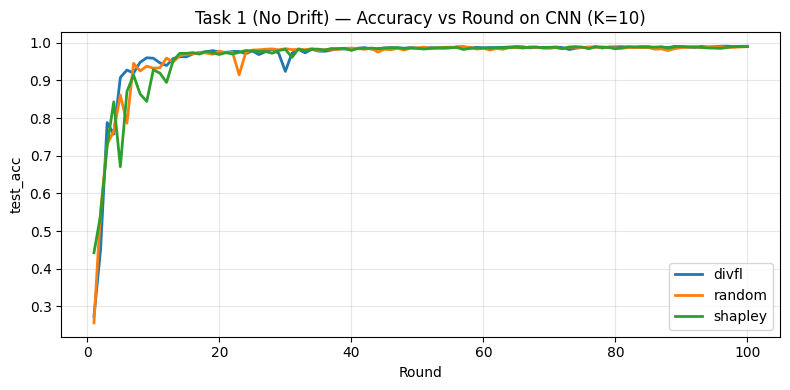

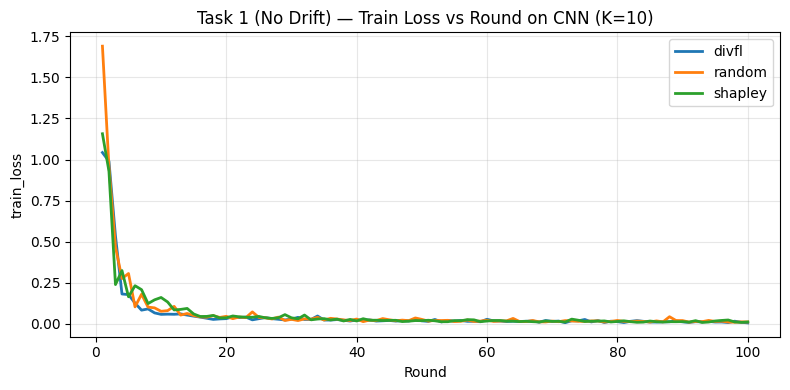

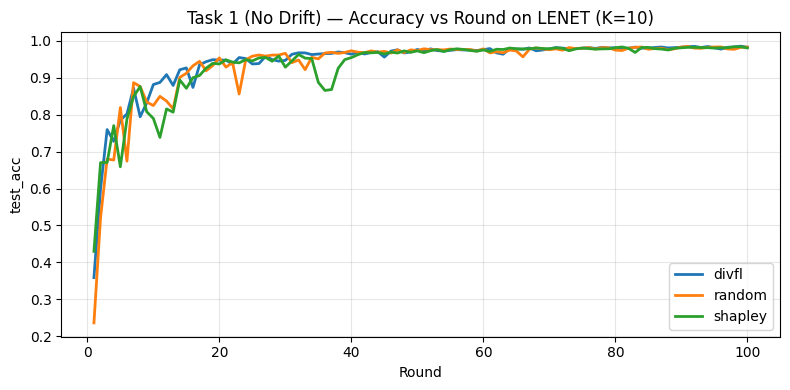

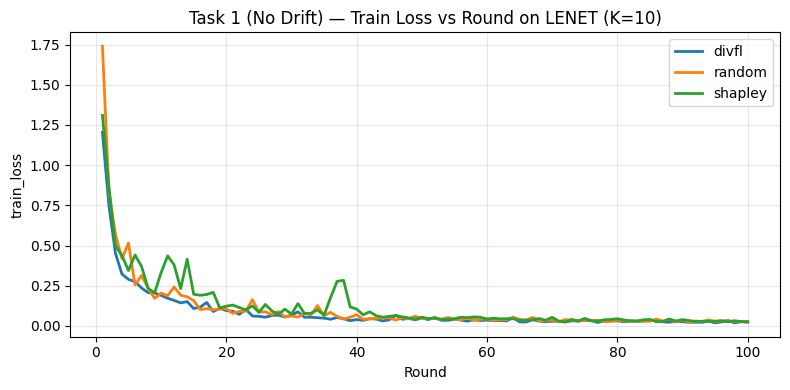

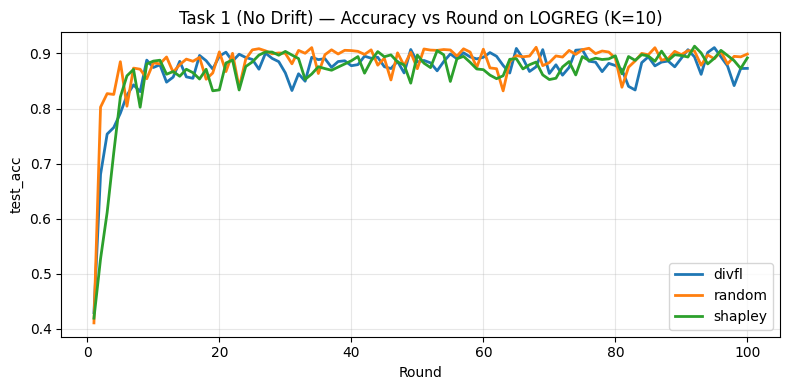

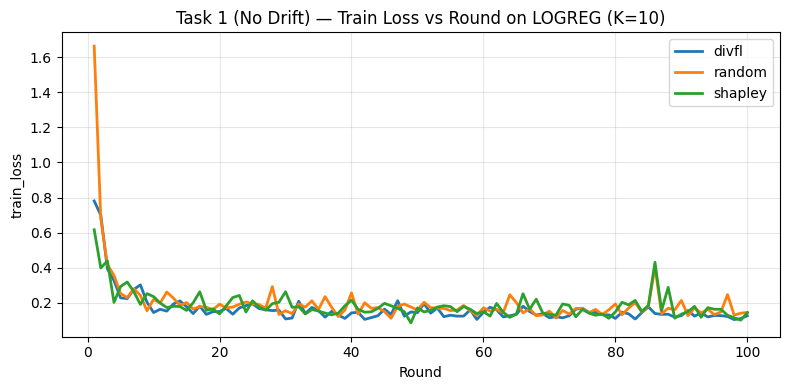

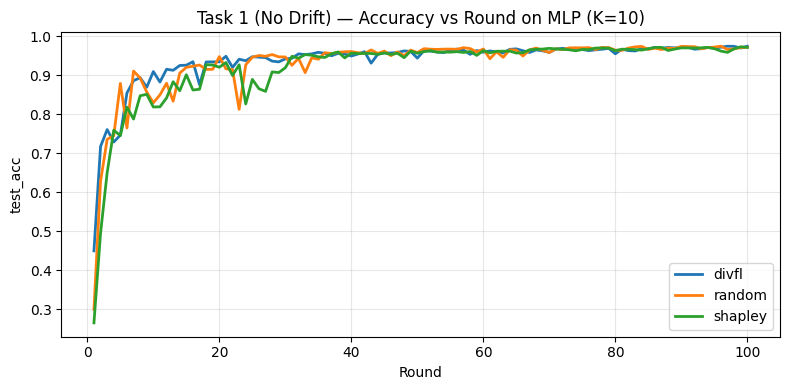

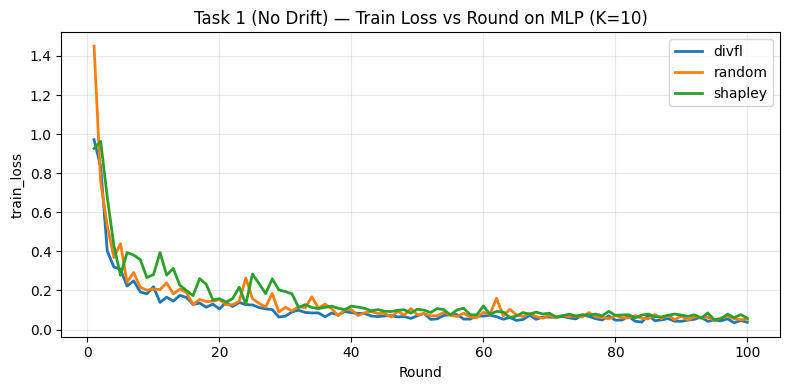

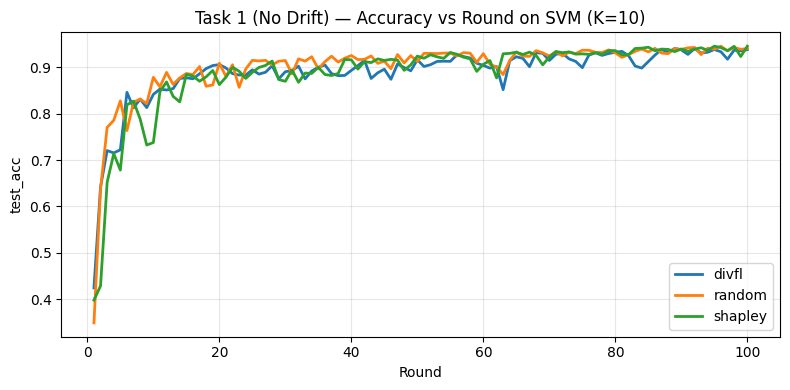

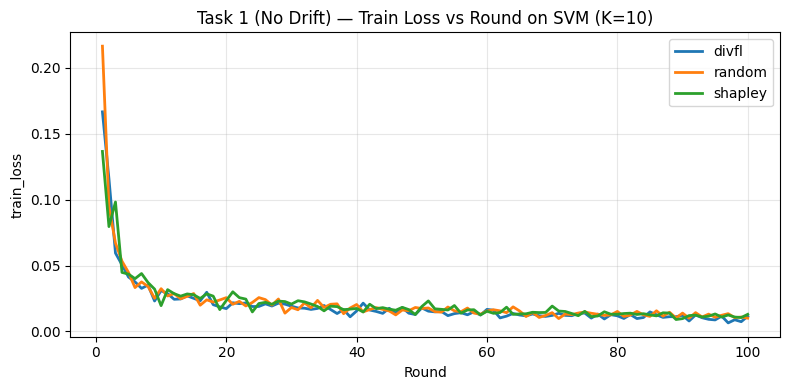

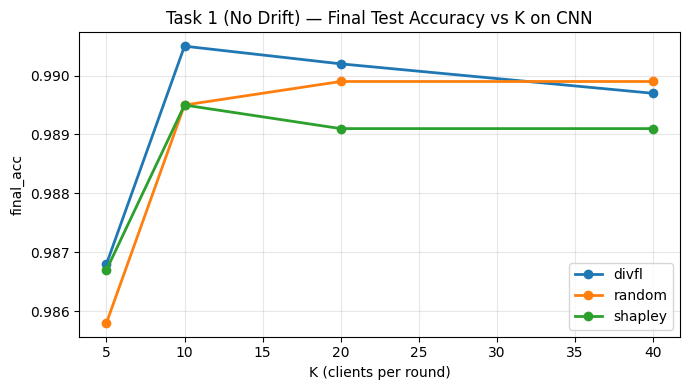

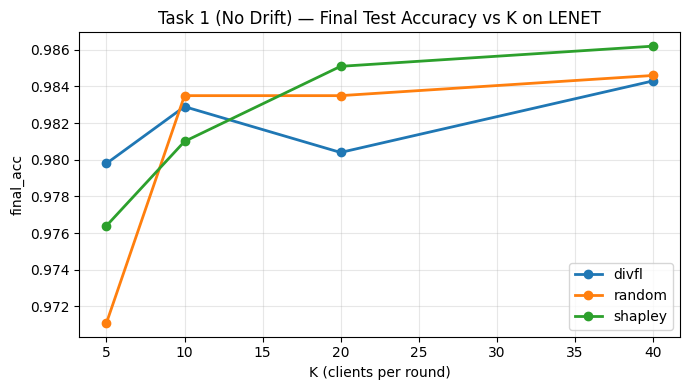

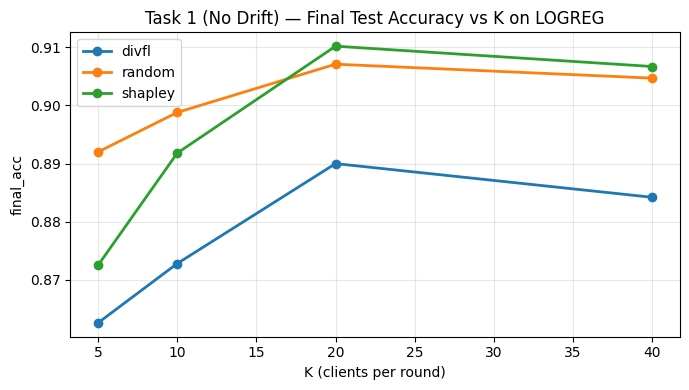

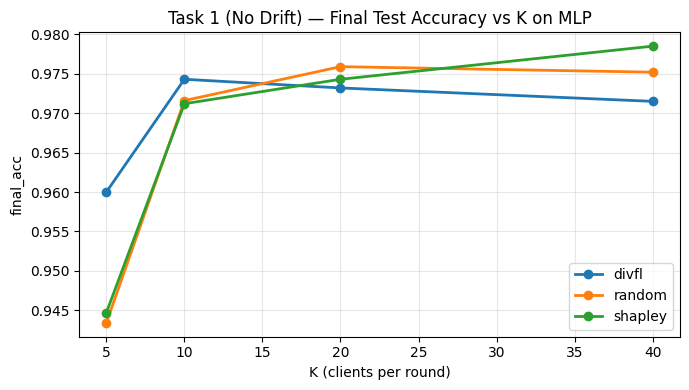

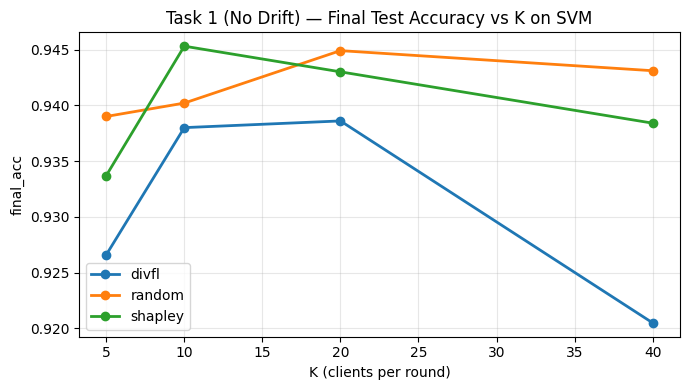

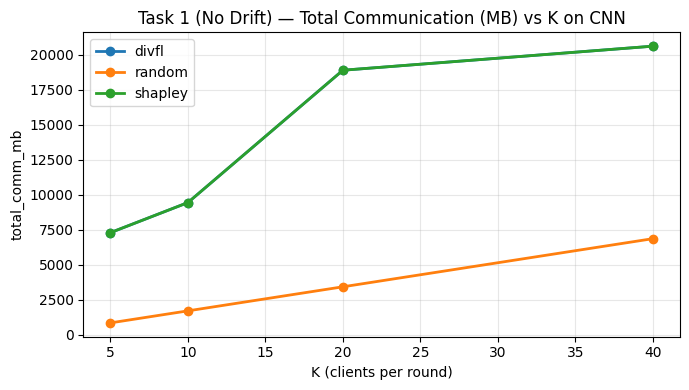

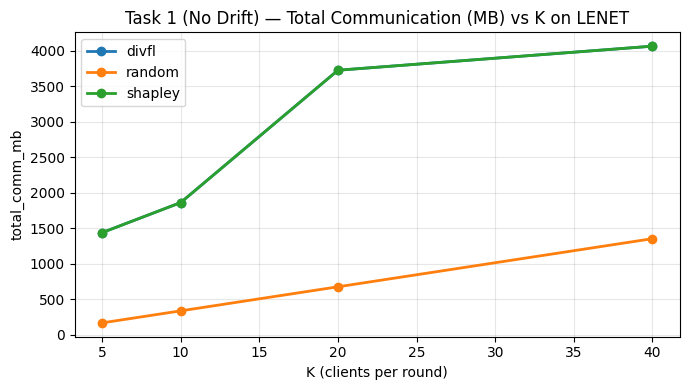

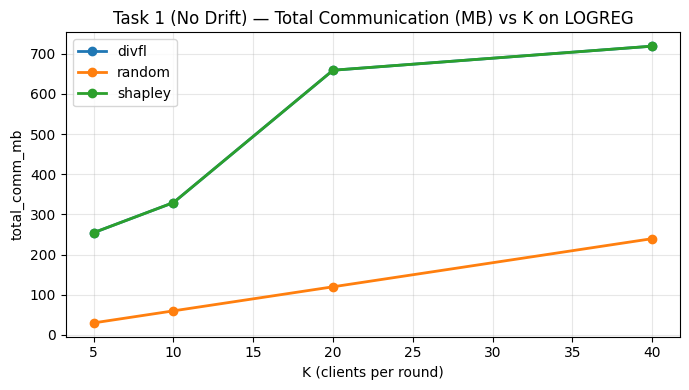

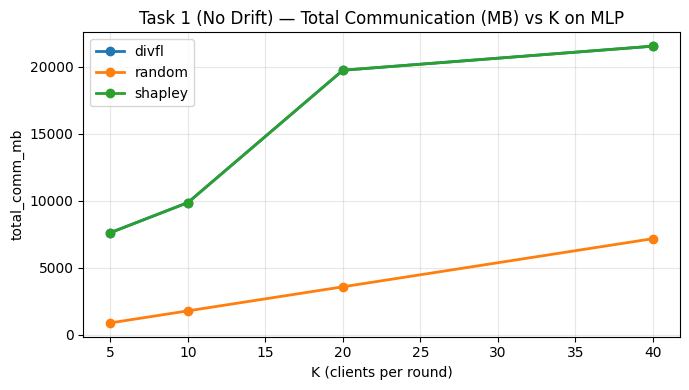

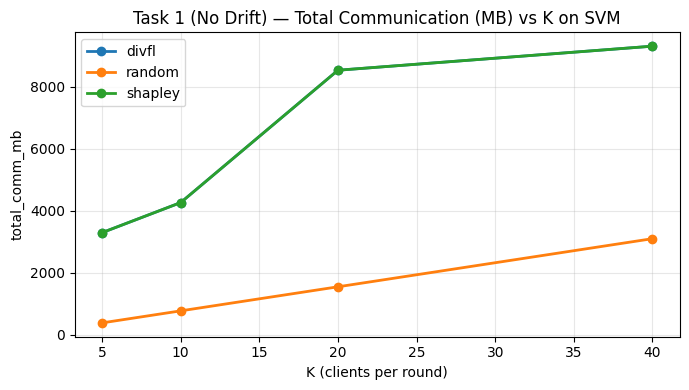

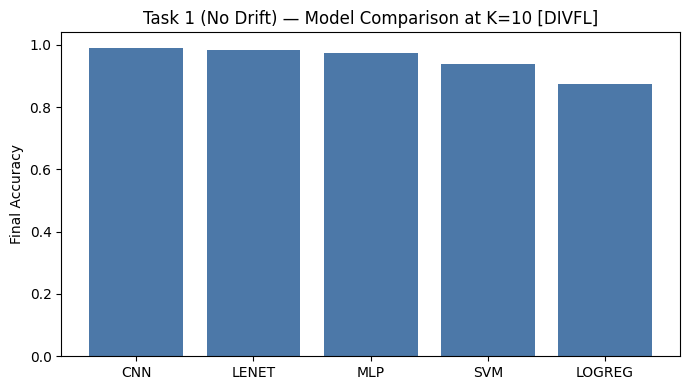

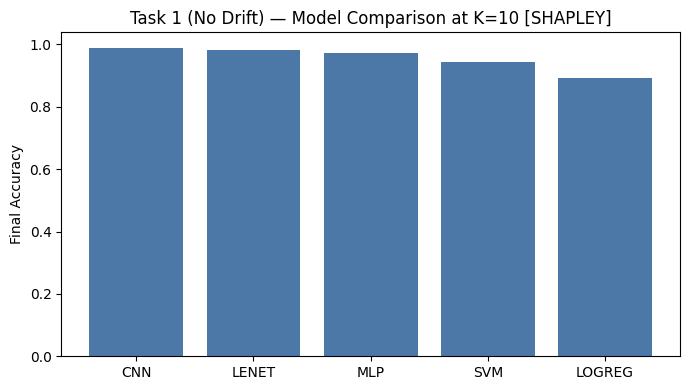

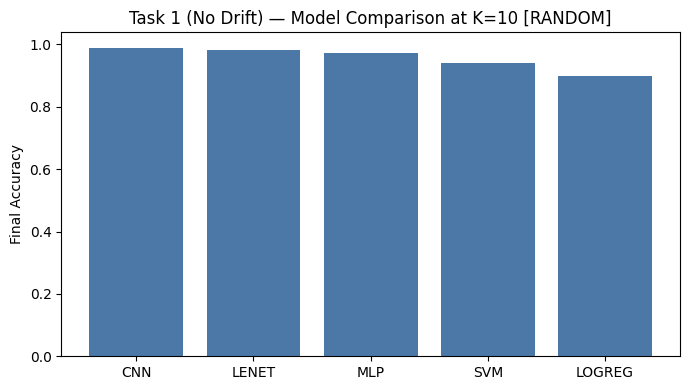

In [ ]:
if "results" not in globals():
    print("Run the Task 1 experiment cell first to create `results`.")
else:
    task1_summary = summarize_runs(
        results,
        group_cols=["model", "strategy", "clients_per_round"],
    ).sort_values(["model", "clients_per_round", "strategy"])
    display(task1_summary)

    # Convergence curves: for each model, show K=10 comparison (DivFL vs Shapley)
    for m in sorted(task1_summary["model"].unique()):
        if (task1_summary["clients_per_round"] == 10).any():
            plot_convergence(
                results,
                title=f"Task 1 (No Drift) — Accuracy vs Round on {m.upper()} (K=10)",
                filter_dict={"model": m, "clients_per_round": 10},
                hue="strategy",
                y="test_acc",
            )
            if "train_loss" in results.columns:
                plot_convergence(
                    results,
                    title=f"Task 1 (No Drift) — Train Loss vs Round on {m.upper()} (K=10)",
                    filter_dict={"model": m, "clients_per_round": 10},
                    hue="strategy",
                    y="train_loss",
                )

    # Final accuracy vs K for each model
    for m in sorted(task1_summary["model"].unique()):
        plot_final_vs_k(
            task1_summary,
            title=f"Task 1 (No Drift) — Final Test Accuracy vs K on {m.upper()}",
            filter_dict={"model": m},
            x="clients_per_round",
            hue="strategy",
            y="final_acc",
        )

    # Cost trade-off (communication) vs K for each model
    for m in sorted(task1_summary["model"].unique()):
        plot_final_vs_k(
            task1_summary,
            title=f"Task 1 (No Drift) — Total Communication (MB) vs K on {m.upper()}",
            filter_dict={"model": m},
            x="clients_per_round",
            hue="strategy",
            y="total_comm_mb",
        )

    # Model comparison for K=10 by strategy
    for strat in ["divfl", "shapley", "random"]:
        plot_model_comparison(
            task1_summary,
            title=f"Task 1 (No Drift) — Model Comparison at K=10 [{strat.upper()}]",
            k_value=10,
            strategy=strat,
        )

# Task 2 — Concept Drift in Federated Learning

Existing FL solutions often assume the training distribution is stable. In practice, the data distribution can be non-stationary (concept drift), causing performance degradation [4]. Here we evaluate **DivFL** and **S-FedAvg** under drift using MNIST.

For each drift scenario:
- Run the FL loop for all models (CNN, LogReg, SVM, MLP, LeNet) under both client selection strategies.
- Use 100 clients and run 50 federated rounds.
- Compare accuracy/convergence and communication/computation proxies.

**Drift scenarios implemented (Task 2):**
- **Label drift (mapping drift):** a global label mapping (e.g., digit 3 is treated as another digit) changes only at a few random rounds. Each client **adopts the latest mapping only at the start of its own drift period** (cycle boundary), then applies it sudden/gradual within-cycle. A fraction of clients remain **clean (identity mapping)** to simulate positive vs negative client impact.
- **Feature drift:** for drifting clients, images are transformed (rotation/noise/brightness/contrast/blur) while labels stay unchanged.
- **Sudden vs gradual drift:** sudden applies the mapping/transform immediately within a client cycle; gradual ramps up over ~60% of that client’s cycle and then stays stable for the remaining ~40%.

Task 3 then proposes a drift-aware bandit selector and compares it against these Task 2 baselines.

In [ ]:
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset

class ClientDriftDataset(Dataset):
    """Per-client dataset wrapper that can be updated in-place (indices/transform)."""
    def __init__(self, base_ds, indices, transform=None, target_transform=None) -> None:
        self.base_ds = base_ds
        self.indices = np.array(indices, dtype=int)
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        base_idx = int(self.indices[idx])
        img, y = self.base_ds[base_idx]
        if self.transform is not None:
            img = self.transform(img)
        if self.target_transform is not None:
            y = self.target_transform(y)
        return img, y

def build_transform(angle: float = 0.0, noise_std: float = 0.0, blur_sigma: float = 0.0) -> transforms.Compose:
    """Legacy transform builder used by the Task 3 controller (kept for backward-compat)."""
    ops = []
    if abs(angle) > 1e-9:
        ops.append(transforms.Lambda(lambda img: TF.rotate(img, angle)))
    if blur_sigma > 0.0:
        ops.append(transforms.GaussianBlur(kernel_size=3, sigma=blur_sigma))
    ops.append(transforms.ToTensor())
    if noise_std > 0.0:
        ops.append(transforms.Lambda(lambda t: torch.clamp(t + torch.randn_like(t) * noise_std, 0.0, 1.0)))
    ops.append(transforms.Normalize(MNIST_MEAN, MNIST_STD))
    return transforms.Compose(ops)

def build_feature_transform(
    rotation_deg: float = 0.0,
    noise_std: float = 0.0,
    blur_sigma: float = 0.0,
    brightness_delta: float = 0.0,
    contrast_delta: float = 0.0,
) -> transforms.Compose:
    """Feature-drift transform with fixed (per-round) intensity parameters."""
    rotation_deg = float(rotation_deg)
    noise_std = float(noise_std)
    blur_sigma = float(blur_sigma)
    brightness_delta = float(brightness_delta)
    contrast_delta = float(contrast_delta)

    brightness_factor = max(0.1, 1.0 + brightness_delta)
    contrast_factor = max(0.1, 1.0 + contrast_delta)

    ops = []
    if abs(rotation_deg) > 1e-9:
        ops.append(transforms.Lambda(lambda img: TF.rotate(img, rotation_deg, fill=0)))
    if abs(brightness_delta) > 1e-9:
        ops.append(transforms.Lambda(lambda img: TF.adjust_brightness(img, brightness_factor)))
    if abs(contrast_delta) > 1e-9:
        ops.append(transforms.Lambda(lambda img: TF.adjust_contrast(img, contrast_factor)))
    if blur_sigma > 0.0:
        k = 3 if blur_sigma <= 1.0 else 5
        ops.append(transforms.GaussianBlur(kernel_size=k, sigma=blur_sigma))
    ops.append(transforms.ToTensor())
    if noise_std > 0.0:
        ops.append(transforms.Lambda(lambda t: torch.clamp(t + torch.randn_like(t) * noise_std, 0.0, 1.0)))
    ops.append(transforms.Normalize(MNIST_MEAN, MNIST_STD))
    return transforms.Compose(ops)

def _normalize_dist(p: np.ndarray) -> np.ndarray:
    p = np.asarray(p, dtype=np.float64)
    p = np.maximum(p, 0.0)
    s = float(p.sum())
    if s <= 0.0:
        return np.ones_like(p, dtype=np.float64) / float(len(p))
    return p / s

def _l1(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sum(np.abs(a - b)))

def _allocate_counts(n: int, dist: np.ndarray) -> np.ndarray:
    dist = _normalize_dist(dist)
    raw = dist * int(n)
    counts = np.floor(raw).astype(int)
    rem = int(n - counts.sum())
    if rem > 0:
        frac = raw - counts
        order = np.argsort(-frac)
        for i in range(rem):
            counts[int(order[i % len(order)])] += 1
    return counts

def _resample_indices_by_dist(
    rng: np.random.Generator,
    class_to_indices: Dict[int, List[int]],
    counts: np.ndarray,
    n_total: int,
) -> np.ndarray:
    out: List[int] = []
    for cls, cnt in enumerate(counts.tolist()):
        pool = class_to_indices.get(int(cls), [])
        if cnt <= 0:
            continue
        if len(pool) == 0:
            continue
        replace = len(pool) < cnt
        out.extend(rng.choice(pool, size=int(cnt), replace=replace).tolist())
    if len(out) < int(n_total):
        pool_all: List[int] = []
        for v in class_to_indices.values():
            pool_all.extend(v)
        if len(pool_all) > 0:
            out.extend(rng.choice(pool_all, size=int(n_total) - len(out), replace=True).tolist())
    rng.shuffle(out)
    return np.asarray(out[: int(n_total)], dtype=int)

def _sample_target_distribution(
    rng: np.random.Generator,
    num_classes: int,
    concentration: float,
    available_mask: Optional[np.ndarray] = None,
) -> np.ndarray:
    if available_mask is None:
        a = np.full(num_classes, float(concentration), dtype=np.float64)
        return _normalize_dist(rng.dirichlet(a))
    m = np.asarray(available_mask, dtype=bool)
    idx = np.where(m)[0]
    if len(idx) == 0:
        return np.ones(num_classes, dtype=np.float64) / float(num_classes)
    a = np.full(len(idx), float(concentration), dtype=np.float64)
    sub = rng.dirichlet(a)
    out = np.zeros(num_classes, dtype=np.float64)
    out[idx] = sub
    return _normalize_dist(out)

def make_periodic_drift_plan(
    num_clients: int,
    periods: List[int],
    clients_per_period: int,
    seed: int = 42,
) -> Tuple[Dict[int, int], Dict[int, int]]:
    """Return (period_by_client, start_round_by_client) for periodic drift."""
    rng = np.random.default_rng(int(seed))
    num_clients = int(num_clients)
    periods = [int(p) for p in periods]
    clients_per_period = int(clients_per_period)
    if num_clients <= 0:
        raise ValueError("num_clients must be positive")
    if any(p <= 0 for p in periods):
        raise ValueError("periods must be positive")
    if clients_per_period < 0:
        raise ValueError("clients_per_period must be non-negative")
    total_needed = clients_per_period * len(periods)
    if total_needed > num_clients:
        raise ValueError("clients_per_period * len(periods) exceeds num_clients")

    all_clients = rng.permutation(num_clients).tolist()
    chosen = all_clients[:total_needed]
    period_by_client: Dict[int, int] = {}
    start_by_client: Dict[int, int] = {}
    idx = 0
    for p in periods:
        group = chosen[idx: idx + clients_per_period]
        idx += clients_per_period
        # Staggered starts to avoid all clients drifting on the same round.
        # For period=4, this yields starts like round 1 and round 3 (as requested).
        start_candidates = [1]
        mid = 1 + int(p // 2)
        start_candidates.append(min(p, mid))
        if p >= 5:
            start_candidates.append(min(p, 5))
        start_candidates = sorted(set(int(x) for x in start_candidates if x >= 1))
        rng.shuffle(group)
        for j, cid in enumerate(group):
            period_by_client[int(cid)] = int(p)
            start_by_client[int(cid)] = int(start_candidates[j % len(start_candidates)])
    return period_by_client, start_by_client

def _periodic_alpha(pos_in_cycle: int, period: int, mode: str) -> float:
    """pos_in_cycle is 0-based index within cycle."""
    mode = str(mode).lower()
    period = int(period)
    pos_in_cycle = int(pos_in_cycle)
    if mode == "sudden":
        return 1.0
    if mode == "gradual":
        drift_len = int(math.ceil(0.60 * period))
        drift_len = max(drift_len, 1)
        if pos_in_cycle < drift_len:
            return float((pos_in_cycle + 1) / drift_len)
        return 1.0
    raise ValueError("mode must be 'sudden' or 'gradual'")

class Task2PeriodicConceptDriftController:
    """Task 2 controller: periodic concept drift with per-client schedules."""
    def __init__(
        self,
        drift_category: str,
        periodic_mode: str,
        period_by_client: Dict[int, int],
        start_round_by_client: Dict[int, int],
        num_classes: int = 10,
        label_concentration: float = 0.05,
        label_min_l1_shift: float = 1.2,
        max_rotation_deg: float = 55.0,
        max_noise_std: float = 0.45,
        max_blur_sigma: float = 2.0,
        max_brightness_delta: float = 0.6,
        max_contrast_delta: float = 0.6,
        seed: int = 42,
    ) -> None:
        drift_category = str(drift_category).lower()
        periodic_mode = str(periodic_mode).lower()
        if drift_category not in {"label", "feature"}:
            raise ValueError("drift_category must be 'label' or 'feature'")
        if periodic_mode not in {"sudden", "gradual"}:
            raise ValueError("periodic_mode must be 'sudden' or 'gradual'")
        self.drift_category = drift_category
        self.periodic_mode = periodic_mode
        self.period_by_client = {int(k): int(v) for k, v in period_by_client.items()}
        self.start_round_by_client = {int(k): int(v) for k, v in start_round_by_client.items()}
        self.num_classes = int(num_classes)
        self.label_concentration = float(label_concentration)
        self.label_min_l1_shift = float(label_min_l1_shift)
        self.max_rotation_deg = float(max_rotation_deg)
        self.max_noise_std = float(max_noise_std)
        self.max_blur_sigma = float(max_blur_sigma)
        self.max_brightness_delta = float(max_brightness_delta)
        self.max_contrast_delta = float(max_contrast_delta)
        self.rng = np.random.default_rng(int(seed))

        self.base_transform = build_feature_transform()

        # Pre-create datasets + loaders (updated in-place per round)
        self.datasets: Dict[int, ClientDriftDataset] = {}
        self.loaders: Dict[int, DataLoader] = {}
        for cid in range(cfg.num_clients):
            ds = ClientDriftDataset(
                base_ds=train_ds_raw,
                indices=client_id_to_indices[cid],
                transform=self.base_transform,
                target_transform=None,
            )
            self.datasets[cid] = ds
            self.loaders[cid] = DataLoader(
                ds,
                batch_size=cfg.batch_size,
                shuffle=True,
                drop_last=False,
                num_workers=cfg.num_workers,
                pin_memory=(DEVICE.type == "cuda"),
            )

        # Per-client label pools (for label drift)
        self._client_class_to_indices: Dict[int, Dict[int, List[int]]] = {}
        self._label_state: Dict[int, Dict[str, object]] = {}

        # Per-client feature params (for feature drift)
        self._feature_state: Dict[int, Dict[str, object]] = {}

        targets = getattr(train_ds_raw, "targets", None)
        for cid in range(cfg.num_clients):
            base_indices = [int(i) for i in client_id_to_indices[cid]]
            class_to_idx: Dict[int, List[int]] = {k: [] for k in range(self.num_classes)}
            for bi in base_indices:
                y = int(targets[bi]) if targets is not None else int(train_ds_raw[bi][1])
                class_to_idx[y].append(int(bi))
            self._client_class_to_indices[cid] = class_to_idx

            counts = np.array([len(class_to_idx[k]) for k in range(self.num_classes)], dtype=np.float64)
            dist0 = _normalize_dist(counts)
            avail = counts > 0
            self._label_state[cid] = {
                "cycle": -1,
                "old": dist0,
                "target": dist0,
                "current": dist0,
                "available_mask": avail,
            }
            self._feature_state[cid] = {
                "cycle": -1,
                "target": {
                    "rotation_deg": 0.0,
                    "noise_std": 0.0,
                    "blur_sigma": 0.0,
                    "brightness_delta": 0.0,
                    "contrast_delta": 0.0,
                },
            }

    def _is_drifting_client(self, cid: int) -> bool:
        return int(cid) in self.period_by_client

    def _maybe_start_new_cycle(self, cid: int, cycle_idx: int) -> None:
        if self.drift_category == "label":
            state = self._label_state[cid]
            if int(state["cycle"]) != int(cycle_idx):
                old = np.asarray(state["current"], dtype=np.float64)
                state["old"] = old
                mask = np.asarray(state["available_mask"], dtype=bool)
                for _ in range(50):
                    tgt = _sample_target_distribution(self.rng, self.num_classes, self.label_concentration, available_mask=mask)
                    if _l1(old, tgt) >= self.label_min_l1_shift:
                        state["target"] = tgt
                        break
                else:
                    state["target"] = _sample_target_distribution(self.rng, self.num_classes, self.label_concentration, available_mask=mask)
                state["cycle"] = int(cycle_idx)

        if self.drift_category == "feature":
            fstate = self._feature_state[cid]
            if int(fstate["cycle"]) != int(cycle_idx):
                rot = float(self.rng.uniform(-self.max_rotation_deg, self.max_rotation_deg))
                noise = float(self.rng.uniform(0.0, self.max_noise_std))
                blur = float(self.rng.uniform(0.0, self.max_blur_sigma))
                bright = float(self.rng.uniform(-self.max_brightness_delta, self.max_brightness_delta))
                contrast = float(self.rng.uniform(-self.max_contrast_delta, self.max_contrast_delta))
                fstate["target"] = {
                    "rotation_deg": rot,
                    "noise_std": noise,
                    "blur_sigma": blur,
                    "brightness_delta": bright,
                    "contrast_delta": contrast,
                }
                fstate["cycle"] = int(cycle_idx)

    def update_round(self, round_num: int) -> Dict[str, object]:
        round_num = int(round_num)
        active = 0
        for cid, ds in self.datasets.items():
            if not self._is_drifting_client(cid):
                if self.drift_category == "feature":
                    ds.transform = self.base_transform
                if self.drift_category == "label":
                    ds.indices = np.asarray(client_id_to_indices[cid], dtype=int)
                continue

            start = int(self.start_round_by_client.get(cid, 1))
            if round_num < start:
                if self.drift_category == "feature":
                    ds.transform = self.base_transform
                if self.drift_category == "label":
                    ds.indices = np.asarray(client_id_to_indices[cid], dtype=int)
                continue

            period = int(self.period_by_client[cid])
            t = round_num - start
            cycle_idx = int(t // period)
            pos = int(t % period)
            self._maybe_start_new_cycle(cid, cycle_idx)

            alpha = _periodic_alpha(pos_in_cycle=pos, period=period, mode=self.periodic_mode)
            active += 1

            if self.drift_category == "label":
                st = self._label_state[cid]
                old = np.asarray(st["old"], dtype=np.float64)
                tgt = np.asarray(st["target"], dtype=np.float64)
                cur = _normalize_dist((1.0 - alpha) * old + alpha * tgt)
                st["current"] = cur
                n = int(len(client_id_to_indices[cid]))
                counts = _allocate_counts(n, cur)
                ds.indices = _resample_indices_by_dist(
                    self.rng, self._client_class_to_indices[cid], counts, n_total=n
                )

            elif self.drift_category == "feature":
                tgtp = dict(self._feature_state[cid]["target"])
                ds.transform = build_feature_transform(
                    rotation_deg=float(tgtp["rotation_deg"]) * alpha,
                    noise_std=float(tgtp["noise_std"]) * alpha,
                    blur_sigma=float(tgtp["blur_sigma"]) * alpha,
                    brightness_delta=float(tgtp["brightness_delta"]) * alpha,
                    contrast_delta=float(tgtp["contrast_delta"]) * alpha,
                )

        drift_fraction = float(active) / float(cfg.num_clients)
        return {
            "drift": self.drift_category,
            "drift_mode": self.periodic_mode,
            "drift_fraction": drift_fraction,
        }

def make_label_shift_map(shift: int = 1, num_classes: int = 10) -> Dict[int, int]:
    return {i: (i + shift) % num_classes for i in range(num_classes)}

def make_label_shift_fn(shift_map: Dict[int, int]):
    def _map(y):
        return int(shift_map.get(int(y), int(y)))
    return _map

def drift_schedule(
    round_num: int,
    shift_round: int,
    mode: str,
    drift_steps: int,
    milestones: Optional[List[Tuple[int, float]]] = None,
) -> float:
    if mode == "sudden":
        return 1.0 if round_num >= shift_round else 0.0
    if mode == "gradual":
        if milestones:
            ms = sorted([(int(r), float(v)) for r, v in milestones], key=lambda x: x[0])
            if round_num < ms[0][0]:
                return 0.0
            for (r0, v0), (r1, v1) in zip(ms, ms[1:]):
                if r0 <= round_num <= r1:
                    frac = (round_num - r0) / max(r1 - r0, 1)
                    return v0 + frac * (v1 - v0)
            return ms[-1][1]
        if round_num < shift_round:
            return 0.0
        return min(1.0, (round_num - shift_round + 1) / max(drift_steps, 1))
    raise ValueError("drift_mode must be 'sudden' or 'gradual'")

class ConceptDriftController:
    """Updates client datasets over rounds to simulate drift (label or feature)."""
    def __init__(
        self,
        drift_type: str,
        drift_mode: str,
        shift_round: int,
        drift_steps: int,
        drift_client_fraction: float,
        drift_angle: float,
        drift_noise_std: float,
        drift_blur_sigma: float,
        label_shift: int,
        gradual_milestones: Optional[List[Tuple[int, float]]] = None,
        seed: int = 42,
    ) -> None:
        self.drift_type = drift_type
        self.drift_mode = drift_mode
        self.shift_round = int(shift_round)
        self.drift_steps = int(drift_steps)
        self.drift_client_fraction = float(drift_client_fraction)
        self.drift_angle = float(drift_angle)
        self.drift_noise_std = float(drift_noise_std)
        self.drift_blur_sigma = float(drift_blur_sigma)
        self.label_shift = int(label_shift)
        self.gradual_milestones = gradual_milestones
        self.rng = np.random.default_rng(seed)

        self.base_transform = build_transform(angle=0.0, noise_std=0.0, blur_sigma=0.0)
        self.label_shift_map = make_label_shift_map(shift=self.label_shift, num_classes=10)
        self.label_shift_fn = make_label_shift_fn(self.label_shift_map)
        self.client_order = self.rng.permutation(cfg.num_clients).tolist()

        # Pre-create datasets + loaders (updated in-place per round)
        self.datasets: Dict[int, ClientDriftDataset] = {}
        self.loaders: Dict[int, DataLoader] = {}
        for cid in range(cfg.num_clients):
            ds = ClientDriftDataset(
                base_ds=train_ds_raw,
                indices=client_id_to_indices[cid],
                transform=self.base_transform,
                target_transform=None,
            )
            self.datasets[cid] = ds
            self.loaders[cid] = DataLoader(
                ds,
                batch_size=cfg.batch_size,
                shuffle=True,
                drop_last=False,
                num_workers=cfg.num_workers,
                pin_memory=(DEVICE.type == "cuda"),
            )

    def update_round(self, round_num: int) -> Dict[str, object]:
        s = drift_schedule(
            round_num,
            self.shift_round,
            self.drift_mode,
            self.drift_steps,
            milestones=self.gradual_milestones,
        )
        effective_fraction = float(self.drift_client_fraction * s)
        n_aff = int(round(cfg.num_clients * effective_fraction))
        affected = set(self.client_order[:n_aff])

        # Build drift transform for this round (severity scales with s for gradual drift)
        if self.drift_type == "feature" and s > 0.0:
            drift_transform = build_transform(
                angle=self.drift_angle * s,
                noise_std=self.drift_noise_std * s,
                blur_sigma=self.drift_blur_sigma * s,
            )
        else:
            drift_transform = self.base_transform

        for cid, ds in self.datasets.items():
            # feature drift
            if self.drift_type == "feature" and cid in affected and s > 0.0:
                ds.transform = drift_transform
            else:
                ds.transform = self.base_transform
            # label drift
            if self.drift_type == "label" and cid in affected and s > 0.0:
                ds.target_transform = self.label_shift_fn
            else:
                ds.target_transform = None

        return {
            "drift": self.drift_type,
            "drift_mode": self.drift_mode,
            "drift_fraction": effective_fraction,
        }

In [ ]:
class Task2StrongContinuousDriftController(Task2PeriodicConceptDriftController):
    """Stronger Task 2 drift while keeping Task 1 unchanged.

    Supports two independent categories (run in separate experiments):
    - drift_category='label': periodic *label mapping* drift (relabeling).
      A global mapping is sampled at a few change rounds, and each client adopts the latest mapping
      only at the start of its own period (cycle boundary), then applies it sudden/gradual within-cycle.
    - drift_category='feature': periodic feature-transform drift (labels unchanged).
    """
    def __init__(
        self,
        *args,
        # Feature drift strengthening (continuous random-walk)
        feature_min_frac: float = 0.60,
        feature_target_jitter: float = 0.22,
        # Label mapping drift schedule
        label_change_rounds: Optional[List[int]] = None,
        label_identity_prob: float = 0.20,
        label_perm_walk_prob: float = 0.00,
        label_perm_walk_swaps: int = 0,
        label_min_moved_classes: int = 4,
        label_clean_client_fraction: float = 0.35,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.feature_min_frac = float(feature_min_frac)
        self.feature_target_jitter = float(feature_target_jitter)

        if label_change_rounds is None:
            label_change_rounds = [1]
        self.label_change_rounds = sorted({int(r) for r in label_change_rounds if int(r) >= 1})
        if 1 not in self.label_change_rounds:
            self.label_change_rounds = [1] + self.label_change_rounds
        self._label_change_rounds_set = set(self.label_change_rounds)

        self.label_identity_prob = float(np.clip(label_identity_prob, 0.0, 1.0))
        self.label_perm_walk_prob = float(np.clip(label_perm_walk_prob, 0.0, 1.0))
        self.label_perm_walk_swaps = int(max(0, label_perm_walk_swaps))
        self.label_min_moved_classes = int(max(1, label_min_moved_classes))

        self.label_clean_client_fraction = float(np.clip(label_clean_client_fraction, 0.0, 1.0))
        all_cids = list(self.datasets.keys())
        n_clean = int(round(self.label_clean_client_fraction * len(all_cids)))
        n_clean = max(0, min(len(all_cids), n_clean))
        clean = set(self.rng.choice(all_cids, size=n_clean, replace=False).tolist()) if n_clean > 0 else set()
        self._label_clean_clients = clean
        self._label_drifting_clients = set(all_cids) - clean

        # Global mapping currently "in effect" (clients adopt it on their cycle boundary).
        self._global_label_perm: np.ndarray = np.arange(self.num_classes, dtype=int)

        # Per-client mapping state (each client keeps a permutation; updated only on its cycle boundaries).
        self._label_state: Dict[int, Dict[str, object]] = {}
        for cid in all_cids:
            perm = np.arange(self.num_classes, dtype=int)
            self._label_state[int(cid)] = {
                "perm": perm,
                "cycle": -1,
                "swap_plan": [],
                "progress_k": 0,
            }

    def _sample_signed_mag(self, max_abs: float, min_frac: float) -> float:
        max_abs = float(max_abs)
        min_abs = float(min_frac) * max_abs
        if max_abs <= 0.0:
            return 0.0
        mag = float(self.rng.uniform(min_abs, max_abs))
        return mag if self.rng.random() < 0.5 else -mag

    def _sample_feature_target_strong(self) -> Dict[str, float]:
        f = float(np.clip(self.feature_min_frac, 0.0, 0.99))
        rot = self._sample_signed_mag(self.max_rotation_deg, f)
        noise = float(self.rng.uniform(f * self.max_noise_std, self.max_noise_std)) if self.max_noise_std > 0 else 0.0
        blur = float(self.rng.uniform(f * self.max_blur_sigma, self.max_blur_sigma)) if self.max_blur_sigma > 0 else 0.0
        bright = self._sample_signed_mag(self.max_brightness_delta, f)
        contrast = self._sample_signed_mag(self.max_contrast_delta, f)
        return {
            "rotation_deg": rot,
            "noise_std": noise,
            "blur_sigma": blur,
            "brightness_delta": bright,
            "contrast_delta": contrast,
        }

    def _jitter_feature_target(self, cid: int) -> None:
        eta = float(np.clip(self.feature_target_jitter, 0.0, 1.0))
        if eta <= 0.0:
            return
        st = self._feature_state[cid]
        tgt = dict(st["target"])
        jitter = self._sample_feature_target_strong()
        for k in tgt.keys():
            tgt[k] = float((1.0 - eta) * float(tgt[k]) + eta * float(jitter[k]))
        st["target"] = tgt

    def _sample_label_perm(self) -> np.ndarray:
        # Sometimes return identity to allow recovery (higher accuracy).
        if self.rng.random() < self.label_identity_prob:
            return np.arange(self.num_classes, dtype=int)

        for _ in range(200):
            perm = self.rng.permutation(self.num_classes).astype(int)
            moved = int(np.sum(perm != np.arange(self.num_classes)))
            if moved >= self.label_min_moved_classes:
                return perm

        perm = self.rng.permutation(self.num_classes).astype(int)
        if np.all(perm == np.arange(self.num_classes)):
            perm = np.roll(perm, 1)
        return perm

    def _compute_swap_plan(self, start_perm: np.ndarray, target_perm: np.ndarray) -> List[Tuple[int, int]]:
        perm = start_perm.copy().astype(int)
        target = target_perm.astype(int)
        plan: List[Tuple[int, int]] = []
        for i in range(self.num_classes):
            if perm[i] == target[i]:
                continue
            j = int(np.where(perm == target[i])[0][0])
            plan.append((int(i), int(j)))
            perm[i], perm[j] = perm[j], perm[i]
        return plan

    def _maybe_update_global_label_perm(self, round_num: int) -> None:
        r = int(round_num)
        if r in self._label_change_rounds_set:
            self._global_label_perm = self._sample_label_perm()
            return
        if self.label_perm_walk_prob > 0.0 and self.rng.random() < self.label_perm_walk_prob:
            swaps = max(0, int(self.label_perm_walk_swaps))
            for _ in range(swaps):
                i, j = self.rng.choice(self.num_classes, size=2, replace=False).tolist()
                self._global_label_perm[int(i)], self._global_label_perm[int(j)] = (
                    self._global_label_perm[int(j)],
                    self._global_label_perm[int(i)],
                )

    def _advance_client_perm(self, cid: int, desired_k: int) -> None:
        st = self._label_state[int(cid)]
        plan: List[Tuple[int, int]] = st["swap_plan"]  
        perm: np.ndarray = st["perm"] 
        k = int(st["progress_k"]) 
        desired_k = int(max(0, min(len(plan), desired_k)))
        while k < desired_k:
            i, j = plan[k]
            perm[i], perm[j] = perm[j], perm[i]
            k += 1
        st["progress_k"] = int(k)

    def _maybe_start_new_cycle(self, cid: int, cycle_idx: int) -> None:
        # Label drift is handled inside update_round; feature drift uses base behavior here.
        if self.drift_category == "feature":
            fstate = self._feature_state[cid]
            if int(fstate["cycle"]) != int(cycle_idx):
                fstate["target"] = self._sample_feature_target_strong()
                fstate["cycle"] = int(cycle_idx)

    def update_round(self, round_num: int) -> Dict[str, object]:
        round_num = int(round_num)
        active = 0

        if self.drift_category == "label":
            self._maybe_update_global_label_perm(round_num)

            for cid, ds in self.datasets.items():
                ds.indices = np.asarray(client_id_to_indices[cid], dtype=int)

                if int(cid) in self._label_clean_clients:
                    ds.target_transform = None
                    continue

                # drifting clients adopt new mapping only at the start of their period
                start = int(self.start_round_by_client.get(cid, 1))
                if round_num < start:
                    ds.target_transform = None
                    continue

                period = int(self.period_by_client[cid])
                t = int(round_num - start)
                cycle_idx = int(t // period)
                pos = int(t % period)

                st = self._label_state[int(cid)]
                if int(st["cycle"]) != int(cycle_idx):
                    # latch the latest global mapping at the cycle boundary
                    st["cycle"] = int(cycle_idx)
                    start_perm = np.asarray(st["perm"], dtype=int).copy()
                    target_perm = np.asarray(self._global_label_perm, dtype=int).copy()
                    st["swap_plan"] = self._compute_swap_plan(start_perm, target_perm)
                    st["progress_k"] = 0

                alpha = _periodic_alpha(pos_in_cycle=pos, period=period, mode=self.periodic_mode)
                plan: List[Tuple[int, int]] = st["swap_plan"]  # type: ignore[assignment]
                desired_k = int(round(float(alpha) * float(len(plan))))
                self._advance_client_perm(cid, desired_k)

                perm: np.ndarray = st["perm"]  # type: ignore[assignment]
                ds.target_transform = (lambda y, p=perm: int(p[int(y)]))
                active += 1

            drift_fraction = float(active) / float(cfg.num_clients)
            return {"drift": "label", "drift_mode": self.periodic_mode, "drift_fraction": drift_fraction}

        # Feature drift path (per-client periodic + continuous jitter)
        for cid, ds in self.datasets.items():
            if not self._is_drifting_client(cid):
                ds.transform = self.base_transform
                continue

            start = int(self.start_round_by_client.get(cid, 1))
            if round_num < start:
                ds.transform = self.base_transform
                continue

            period = int(self.period_by_client[cid])
            t = round_num - start
            cycle_idx = int(t // period)
            pos = int(t % period)
            self._maybe_start_new_cycle(cid, cycle_idx)
            self._jitter_feature_target(cid)

            alpha = _periodic_alpha(pos_in_cycle=pos, period=period, mode=self.periodic_mode)
            active += 1

            tgtp = dict(self._feature_state[cid]["target"])
            ds.transform = build_feature_transform(
                rotation_deg=float(tgtp["rotation_deg"]) * alpha,
                noise_std=float(tgtp["noise_std"]) * alpha,
                blur_sigma=float(tgtp["blur_sigma"]) * alpha,
                brightness_delta=float(tgtp["brightness_delta"]) * alpha,
                contrast_delta=float(tgtp["contrast_delta"]) * alpha,
            )

        drift_fraction = float(active) / float(cfg.num_clients)
        return {"drift": "feature", "drift_mode": self.periodic_mode, "drift_fraction": drift_fraction}

In [ ]:

drift_scenarios = [
    {"drift_type": "label", "drift_mode": "sudden"},
    {"drift_type": "label", "drift_mode": "gradual"},
    {"drift_type": "feature", "drift_mode": "sudden"},
    {"drift_type": "feature", "drift_mode": "gradual"},
]

# Shared drift parameters (legacy shift-round drift used by Task 3)
drift_common = {
    "shift_round": 51,
    "drift_steps": 50,
    "drift_client_fraction": 0.5,
    "drift_angle": 30.0,
    "drift_noise_std": 0.2,
    "drift_blur_sigma": 1.0,
    "label_shift": 1,
    "gradual_milestones": [
        (50, 0.10),
        (60, 0.30),
        (70, 0.50),
        (80, 0.70),
        (100, 1.00),
    ],
}

TASK2_NUM_CLIENTS = 100
TASK2_ROUNDS = 50
TASK2_PRINT_EVERY = 2

assert int(cfg.num_clients) == TASK2_NUM_CLIENTS, f"cfg.num_clients must be {TASK2_NUM_CLIENTS}"

# Periodic drift: different client subsets drift with different intervals
TASK2_PERIODS = [4, 5, 6, 7, 8]

# Keep all clients eligible for drift scheduling (period assignment)
TASK2_CLIENTS_PER_PERIOD = 20  # 5 periods × 20 clients = 100 clients
task2_period_by_client, task2_start_by_client = make_periodic_drift_plan(
    num_clients=cfg.num_clients,
    periods=TASK2_PERIODS,
    clients_per_period=TASK2_CLIENTS_PER_PERIOD,
    seed=SEED,
 )

# Make each client's drift start independent and realistic: random offset in rounds 1..5 (clipped by its period)
_rng_task2_offsets = np.random.default_rng(int(SEED) + 2026)
for _cid, _p in task2_period_by_client.items():
    task2_start_by_client[int(_cid)] = int(_rng_task2_offsets.integers(1, min(5, int(_p)) + 1))

# Tuned here to be harsher (to reduce accuracy vs the earlier softened config).
_rng_label_sched = np.random.default_rng(int(SEED) + 3033)
TASK2_LABEL_NUM_CHANGES = 14  # more frequent global mapping change points within 50 rounds
TASK2_LABEL_MIN_GAP = 2       # allow closer mapping changes
_label_changes = [1]
_tries = 0
while len(_label_changes) < int(TASK2_LABEL_NUM_CHANGES) and _tries < 2000:
    _tries += 1
    cand = int(_rng_label_sched.integers(2, int(TASK2_ROUNDS) + 1))
    if all(abs(cand - r) >= int(TASK2_LABEL_MIN_GAP) for r in _label_changes):
        _label_changes.append(cand)
TASK2_LABEL_CHANGE_ROUNDS = sorted(set(_label_changes))

# Label mapping parameters for Task 2 controller
TASK2_LABEL_PARAMS = {
    "label_change_rounds": TASK2_LABEL_CHANGE_ROUNDS,
    "label_identity_prob": 0.05,       
    "label_perm_walk_prob": 0.50,      
    "label_perm_walk_swaps": 3,           
    "label_min_moved_classes": 7,         
    "label_clean_client_fraction": 0.10,  
}

# Feature drift parameters (stronger).
TASK2_FEATURE_PARAMS = {
    "max_rotation_deg": 110.0,
    "max_noise_std": 1.0,
    "max_blur_sigma": 4.5,
    "max_brightness_delta": 1.2,
    "max_contrast_delta": 1.2,
}

TASK_COMPARE_SCENARIOS = [
    ("label", "sudden"),
    ("label", "gradual"),
    ("feature", "sudden"),
    ("feature", "gradual"),
]
TASK_COMPARE_K_VALUES = [10]
TASK_COMPARE_ROUNDS = int(TASK2_ROUNDS)  

In [ ]:
def run_task2_periodic_drift_experiment(
    drift_category: str,
    periodic_mode: str,
    k_values: List[int],
    models_to_run: List[str],
    strategies: List[str],
 ) -> pd.DataFrame:
    """Run a single Task 2 scenario (label/feature × sudden/gradual) for 50 rounds."""
    all_hist = []
    for k in k_values:
        for model_name in models_to_run:
            for strat in strategies:
                controller = Task2StrongContinuousDriftController(
                    drift_category=drift_category,
                    periodic_mode=periodic_mode,
                    period_by_client=task2_period_by_client,
                    start_round_by_client=task2_start_by_client,
                    seed=int(SEED) + 1000,
                    **(TASK2_LABEL_PARAMS if drift_category == "label" else {}),
                    **(TASK2_FEATURE_PARAMS if drift_category == "feature" else {}),
                )
                print(
                    f"\n=== Task2 Periodic Drift: {drift_category}:{periodic_mode} model={model_name} strat={strat} K={k} ==="
                )
                hist = federated_train(
                    model_name=model_name,
                    strategy=strat,
                    clients_per_round=k,
                    drift_controller=controller,
                    drift_meta={"drift": drift_category, "drift_mode": periodic_mode, "drift_fraction": 0.0},
                    rounds=TASK2_ROUNDS,
                    print_every=TASK2_PRINT_EVERY,
                )
                all_hist.append(hist)
    return pd.concat(all_hist, ignore_index=True)

In [ ]:


_need = [
    "Task2StrongContinuousDriftController",
    "task2_period_by_client",
    "task2_start_by_client",
    "TASK2_LABEL_PARAMS",
    "federated_train",
    "cfg",
    "SEED",
    "pd",
]
_missing = [n for n in _need if n not in globals()]
if _missing:
    raise RuntimeError(f"Run earlier setup + Task 2 config cells first; missing: {_missing}")

TASK2_LABEL_COMPARE_MODEL = "cnn"
TASK2_LABEL_COMPARE_STRATEGY = "shapley"  # or "divfl"
TASK2_LABEL_COMPARE_K = int(TASK_COMPARE_K_VALUES[0]) if "TASK_COMPARE_K_VALUES" in globals() and len(TASK_COMPARE_K_VALUES) > 0 else 10
TASK2_LABEL_COMPARE_ROUNDS = int(TASK_COMPARE_ROUNDS) if "TASK_COMPARE_ROUNDS" in globals() else int(TASK2_ROUNDS)

_old_eval_test_every = int(getattr(cfg, "eval_test_every", 5))
try:
    # Print test accuracy every round for live monitoring.
    cfg.eval_test_every = 1

    task2_label_hist = []
    for mode in ["sudden", "gradual"]:
        controller = Task2StrongContinuousDriftController(
            drift_category="label",
            periodic_mode=mode,
            period_by_client=task2_period_by_client,
            start_round_by_client=task2_start_by_client,
            seed=int(SEED) + 1200,
            **TASK2_LABEL_PARAMS,
        )

        print(
            f"Running Task 2 label:{mode} | model={TASK2_LABEL_COMPARE_MODEL} | "
            f"strategy={TASK2_LABEL_COMPARE_STRATEGY} | rounds={TASK2_LABEL_COMPARE_ROUNDS} | K={TASK2_LABEL_COMPARE_K}"
        )

        # Live prints come from federated_train(print_every=1) in round/accuracy format.
        h = federated_train(
            model_name=TASK2_LABEL_COMPARE_MODEL,
            strategy=TASK2_LABEL_COMPARE_STRATEGY,
            clients_per_round=int(TASK2_LABEL_COMPARE_K),
            drift_controller=controller,
            rounds=int(TASK2_LABEL_COMPARE_ROUNDS),
            print_every=1,
        )

        if "drift" not in h.columns:
            h["drift"] = "label"
        if "drift_mode" not in h.columns:
            h["drift_mode"] = mode

        task2_label_hist.append(h)

    task2_label_compare_results = pd.concat(task2_label_hist, ignore_index=True) if task2_label_hist else pd.DataFrame()

    task2_label_compare_acc = task2_label_compare_results[
        [
            c
            for c in ["round", "val_acc", "test_acc", "model", "strategy", "clients_per_round", "drift", "drift_mode"]
            if c in task2_label_compare_results.columns
        ]
    ].copy()

    # Keep compatibility with other comparison cells.
    task2_compare_results = task2_label_compare_results.copy()
    task2_acc = task2_label_compare_acc.copy()
finally:
    cfg.eval_test_every = _old_eval_test_every

Running Task 2 label:sudden | model=cnn | strategy=shapley | rounds=50 | K=10
round 1/50 val_acc=0.3506 test_acc=0.3579
round 2/50 val_acc=0.5825 test_acc=0.6002
round 3/50 val_acc=0.6611 test_acc=0.6929
round 4/50 val_acc=0.2656 test_acc=0.2793
round 5/50 val_acc=0.6328 test_acc=0.6330
round 6/50 val_acc=0.7837 test_acc=0.7997
round 7/50 val_acc=0.5884 test_acc=0.6265
round 8/50 val_acc=0.5625 test_acc=0.5732
round 9/50 val_acc=0.4575 test_acc=0.4562
round 10/50 val_acc=0.2656 test_acc=0.2513
round 11/50 val_acc=0.3809 test_acc=0.3946
round 12/50 val_acc=0.1948 test_acc=0.1953
round 13/50 val_acc=0.6138 test_acc=0.6106
round 14/50 val_acc=0.0518 test_acc=0.0454
round 15/50 val_acc=0.2100 test_acc=0.2265
round 16/50 val_acc=0.2744 test_acc=0.2840
round 17/50 val_acc=0.2031 test_acc=0.2222
round 18/50 val_acc=0.4946 test_acc=0.4922
round 19/50 val_acc=0.5342 test_acc=0.5487
round 20/50 val_acc=0.3711 test_acc=0.3885
round 21/50 val_acc=0.3145 test_acc=0.3186
round 22/50 val_acc=0.5615 t

In [ ]:
_ctrl_label = Task2StrongContinuousDriftController(
    drift_category="label",
    periodic_mode="gradual",
    period_by_client=task2_period_by_client,
    start_round_by_client=task2_start_by_client,
    seed=int(SEED) + 999,
    **TASK2_LABEL_PARAMS,
 )
for _r in range(1, 10):
    _ = _ctrl_label.update_round(_r)
    # dataset length should stay constant per client
    for _cid in range(cfg.num_clients):
        assert len(_ctrl_label.datasets[_cid]) == len(client_id_to_indices[_cid])
    # any ACTIVE drifting client's mapping should be a permutation of 0..9 at any round
    _active_drifter = None
    for _cid in _ctrl_label._label_drifting_clients:
        if _r >= int(task2_start_by_client.get(int(_cid), 1)):
            _active_drifter = int(_cid)
            break
    if _active_drifter is not None:
        assert _ctrl_label.datasets[_active_drifter].target_transform is not None
        _perm_vals = [_ctrl_label.datasets[_active_drifter].target_transform(i) for i in range(10)]
        assert sorted(_perm_vals) == list(range(10))
    # any clean client's mapping should be identity (target_transform None)
    _any_clean = next(iter(_ctrl_label._label_clean_clients)) if len(_ctrl_label._label_clean_clients) else None
    if _any_clean is not None:
        assert _ctrl_label.datasets[int(_any_clean)].target_transform is None
print("Label-mapping drift controller OK")

_ctrl_feat = Task2StrongContinuousDriftController(
    drift_category="feature",
    periodic_mode="sudden",
    period_by_client=task2_period_by_client,
    start_round_by_client=task2_start_by_client,
    seed=int(SEED) + 1001,
    **TASK2_FEATURE_PARAMS,
 )
for _r in range(1, 6):
    _ = _ctrl_feat.update_round(_r)
    for _cid in range(cfg.num_clients):
        assert len(_ctrl_feat.datasets[_cid]) == len(client_id_to_indices[_cid])
print("Feature-drift controller OK")

Label-mapping drift controller OK
Feature-drift controller OK


In [ ]:
models_to_run_task2 = ["cnn", "lenet", "mlp", "logreg", "svm"]
strategies_task2 = ["divfl", "shapley"]  # DivFL and S-FedAvg (Shapley)
k_values_task2 = [10]  # set K; keep small for runtime

task2_label_sudden_results = run_task2_periodic_drift_experiment(
    drift_category="label",
    periodic_mode="sudden",
    k_values=k_values_task2,
    models_to_run=models_to_run_task2,
    strategies=strategies_task2,
)
task2_label_sudden_results.tail()


=== Task2 Periodic Drift: label:sudden model=cnn strat=divfl K=10 ===
round 1/50 val_acc=0.5015 test_acc=0.4995
round 2/50 val_acc=0.5308 test_acc=0.5704
round 4/50 val_acc=0.1660 test_acc=0.1756
round 6/50 val_acc=0.0825 test_acc=0.0803
round 8/50 val_acc=0.1040 test_acc=0.0962
round 10/50 val_acc=0.1172 test_acc=0.1174
round 12/50 val_acc=0.1152 test_acc=0.1044
round 14/50 val_acc=0.2998 test_acc=0.2985
round 16/50 val_acc=0.5283 test_acc=0.5490
round 18/50 val_acc=0.5117 test_acc=0.5036
round 20/50 val_acc=0.5493 test_acc=0.5775
round 22/50 val_acc=0.5913 test_acc=0.6191
round 24/50 val_acc=0.5928 test_acc=0.6163
round 26/50 val_acc=0.5059 test_acc=0.5330
round 28/50 val_acc=0.4033 test_acc=0.3934
round 30/50 val_acc=0.2803 test_acc=0.2869
round 32/50 val_acc=0.2256 test_acc=0.2299
round 34/50 val_acc=0.3604 test_acc=0.3554
round 36/50 val_acc=0.0332 test_acc=0.0313
round 38/50 val_acc=0.5640 test_acc=0.5676
round 40/50 val_acc=0.5161 test_acc=0.5445
round 42/50 val_acc=0.6348 test

,round,model,strategy,clients_per_round,train_loss,val_loss,val_acc,test_loss,test_acc,comm_bytes,...,selection_samples,compute_samples_selected,compute_samples_total,bandit_reward_mean,bandit_comm_penalty,bandit_diversity_bonus,selected_clients,drift,drift_mode,drift_fraction
495,46,svm,shapley,10,0.127398,0.241988,0.646973,0.216980,0.6727,44778800,...,3200,9100,12300,NaN,NaN,NaN,"[30, 19, 57, 33, 32, 75, 36, 59, 23, 69]",label,sudden,0.9
496,47,svm,shapley,10,0.077958,0.240098,0.660645,0.215809,0.6862,44778800,...,3200,12372,15572,NaN,NaN,NaN,"[30, 76, 46, 72, 14, 99, 45, 34, 83, 74]",label,sudden,0.9
497,48,svm,shapley,10,0.096446,0.293410,0.631348,0.267619,0.6529,44778800,...,3200,10580,13780,NaN,NaN,NaN,"[42, 0, 63, 49, 87, 88, 47, 98, 28, 2]",label,sudden,0.9
498,49,svm,shapley,10,0.092466,0.339804,0.605957,0.318235,0.6240,44778800,...,3200,10690,13890,NaN,NaN,NaN,"[30, 71, 0, 80, 50, 85, 26, 41, 40, 57]",label,sudden,0.9
499,50,svm,shapley,10,0.093304,0.329467,0.587891,0.301879,0.6070,44778800,...,3200,10024,13224,NaN,NaN,NaN,"[74, 50, 34, 55, 64, 33, 94, 13, 67, 48]",label,sudden,0.9


In [ ]:
task2_label_gradual_results = run_task2_periodic_drift_experiment(
    drift_category="label",
    periodic_mode="gradual",
    k_values=k_values_task2,
    models_to_run=models_to_run_task2,
    strategies=strategies_task2,
)
task2_label_gradual_results.tail()


=== Task2 Periodic Drift: label:gradual model=cnn strat=divfl K=10 ===
round 1/50 val_acc=0.2251 test_acc=0.2272
round 2/50 val_acc=0.3198 test_acc=0.3301
round 4/50 val_acc=0.3311 test_acc=0.3268
round 6/50 val_acc=0.1963 test_acc=0.2123
round 8/50 val_acc=0.0742 test_acc=0.0676
round 10/50 val_acc=0.1211 test_acc=0.1069
round 12/50 val_acc=0.1816 test_acc=0.1755
round 14/50 val_acc=0.3198 test_acc=0.3065
round 16/50 val_acc=0.3203 test_acc=0.3247
round 18/50 val_acc=0.5762 test_acc=0.5816
round 20/50 val_acc=0.5508 test_acc=0.5590
round 22/50 val_acc=0.6230 test_acc=0.6610
round 24/50 val_acc=0.3638 test_acc=0.3832
round 26/50 val_acc=0.5967 test_acc=0.6379
round 28/50 val_acc=0.3340 test_acc=0.3637
round 30/50 val_acc=0.2368 test_acc=0.2329
round 32/50 val_acc=0.2192 test_acc=0.2249
round 34/50 val_acc=0.2407 test_acc=0.2312
round 36/50 val_acc=0.1465 test_acc=0.1447
round 38/50 val_acc=0.2178 test_acc=0.2348
round 40/50 val_acc=0.5298 test_acc=0.5140
round 42/50 val_acc=0.5225 tes

,round,model,strategy,clients_per_round,train_loss,val_loss,val_acc,test_loss,test_acc,comm_bytes,...,selection_samples,compute_samples_selected,compute_samples_total,bandit_reward_mean,bandit_comm_penalty,bandit_diversity_bonus,selected_clients,drift,drift_mode,drift_fraction
495,46,svm,shapley,10,0.098861,0.221786,0.597656,0.190003,0.6338,44778800,...,3200,9272,12472,NaN,NaN,NaN,"[9, 30, 19, 33, 58, 21, 48, 97, 4, 34]",label,gradual,0.9
496,47,svm,shapley,10,0.066734,0.263649,0.577148,0.233973,0.5992,44778800,...,3200,12042,15242,NaN,NaN,NaN,"[99, 83, 30, 72, 14, 22, 6, 45, 95, 13]",label,gradual,0.9
497,48,svm,shapley,10,0.099902,0.414107,0.521973,0.382150,0.5491,44778800,...,3200,12710,15910,NaN,NaN,NaN,"[86, 0, 14, 88, 49, 95, 26, 79, 28, 31]",label,gradual,0.9
498,49,svm,shapley,10,0.097113,0.356671,0.605957,0.320327,0.6378,44778800,...,3200,9350,12550,NaN,NaN,NaN,"[0, 32, 30, 71, 85, 50, 95, 17, 60, 26]",label,gradual,0.9
499,50,svm,shapley,10,0.097772,0.447053,0.397461,0.408295,0.4389,44778800,...,3200,13824,17024,NaN,NaN,NaN,"[92, 64, 82, 13, 96, 50, 79, 44, 33, 67]",label,gradual,0.9


In [ ]:
_need = [
    "task2_label_sudden_results",
    "task2_label_gradual_results",
]
_missing = [n for n in _need if n not in globals()]
if _missing:
    print(f"Missing label-drift results. Run these cells first: {_missing}")
else:
    task2_periodic_drift_results = pd.concat(
        [
            task2_label_sudden_results,
            task2_label_gradual_results,
        ],
        ignore_index=True,
    )
    drift_results = task2_periodic_drift_results
    drift_results.tail()

,model,strategy,clients_per_round,drift,drift_mode,final_acc,best_acc,rounds_to_95pct_final,rounds_to_recover,total_comm_mb,total_compute_samples
0,cnn,divfl,10,label,gradual,0.1826,0.7096,1.0,NaN,4721.401215,738974
2,cnn,shapley,10,label,gradual,0.2584,0.9553,1.0,NaN,4721.401215,731992
4,lenet,divfl,10,label,gradual,0.1066,0.7826,1.0,NaN,932.094574,744326
6,lenet,shapley,10,label,gradual,0.3347,0.8098,1.0,NaN,932.094574,708318
8,logreg,divfl,10,label,gradual,0.2018,0.7012,1.0,NaN,164.699554,772692
10,logreg,shapley,10,label,gradual,0.1312,0.7211,1.0,NaN,164.699554,740240
12,mlp,divfl,10,label,gradual,0.3528,0.7270,1.0,NaN,4933.559418,745258
14,mlp,shapley,10,label,gradual,0.1862,0.9199,1.0,NaN,4933.559418,745086
16,svm,divfl,10,label,gradual,0.4399,0.7165,2.0,NaN,2135.219574,802926
18,svm,shapley,10,label,gradual,0.4389,0.8326,2.0,NaN,2135.219574,734156


,model,strategy,clients_per_round,drift,drift_mode,acc_round1,acc_final,acc_drop
0,cnn,divfl,10,label,gradual,0.2272,0.1826,0.0446
2,cnn,shapley,10,label,gradual,0.4375,0.2584,0.1791
4,lenet,divfl,10,label,gradual,0.5513,0.1066,0.4447
6,lenet,shapley,10,label,gradual,0.4402,0.3347,0.1055
8,logreg,divfl,10,label,gradual,0.5478,0.2018,0.3460
10,logreg,shapley,10,label,gradual,0.3646,0.1312,0.2334
12,mlp,divfl,10,label,gradual,0.5755,0.3528,0.2227
14,mlp,shapley,10,label,gradual,0.4650,0.1862,0.2788
16,svm,divfl,10,label,gradual,0.3743,0.4399,-0.0656
18,svm,shapley,10,label,gradual,0.3869,0.4389,-0.0520


Plotting label drift for models: ['cnn', 'lenet', 'logreg', 'mlp', 'svm']


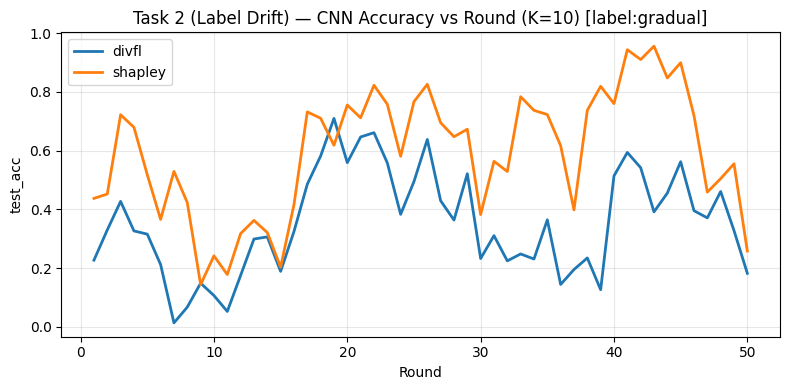

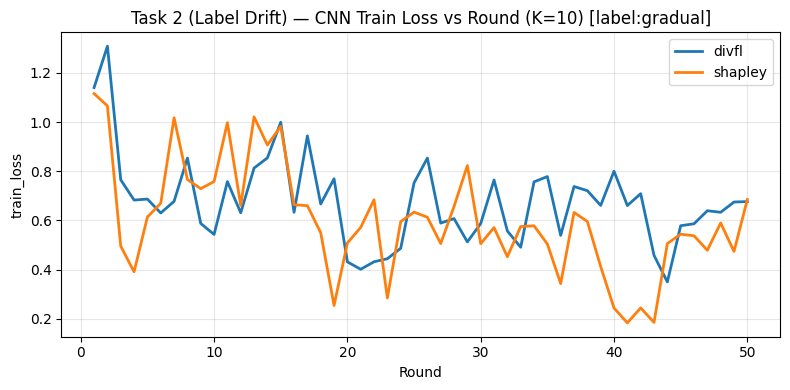

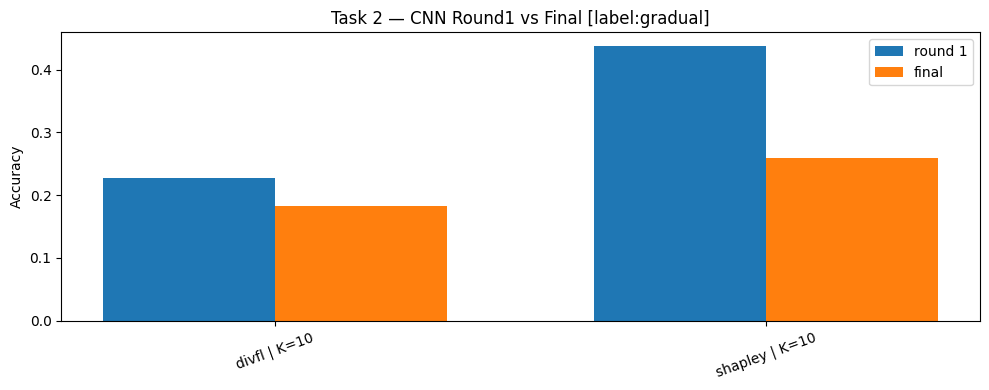

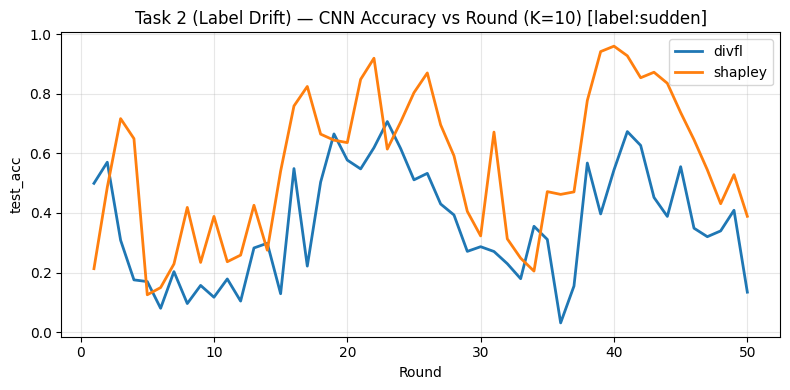

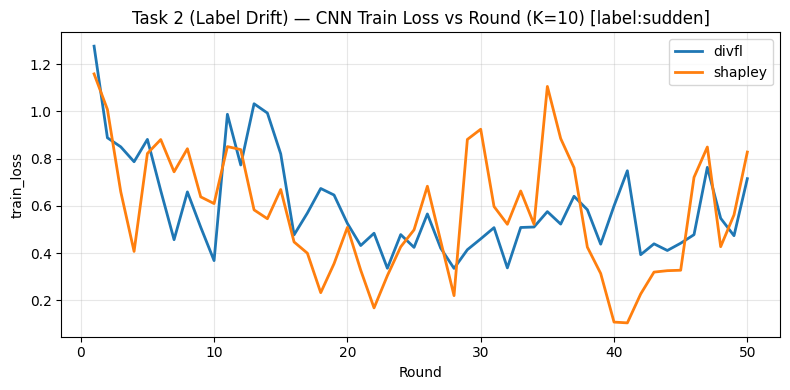

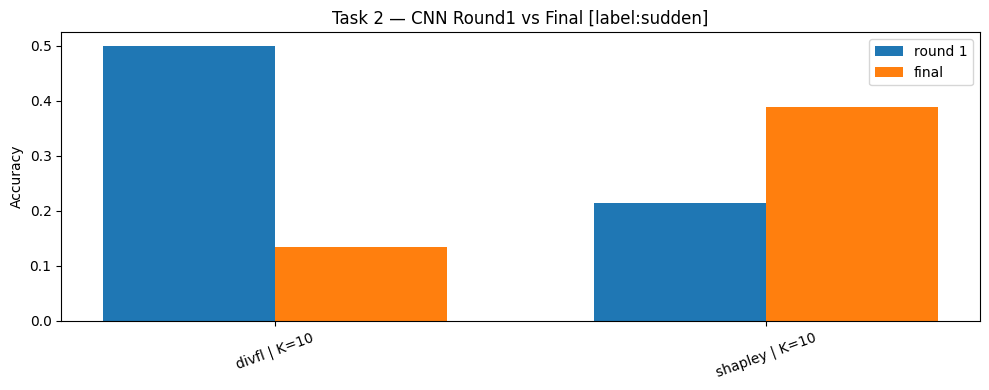

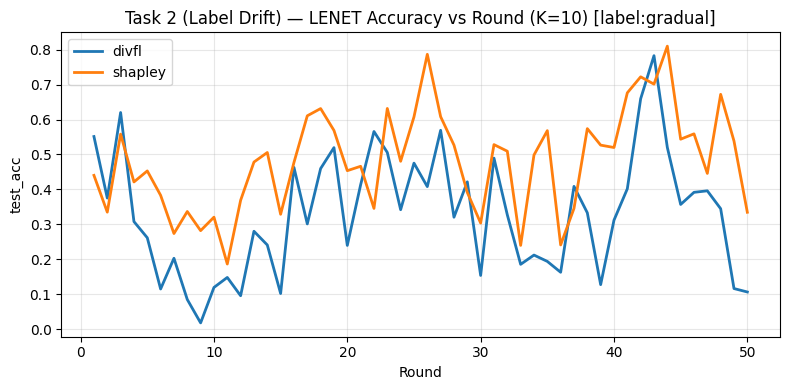

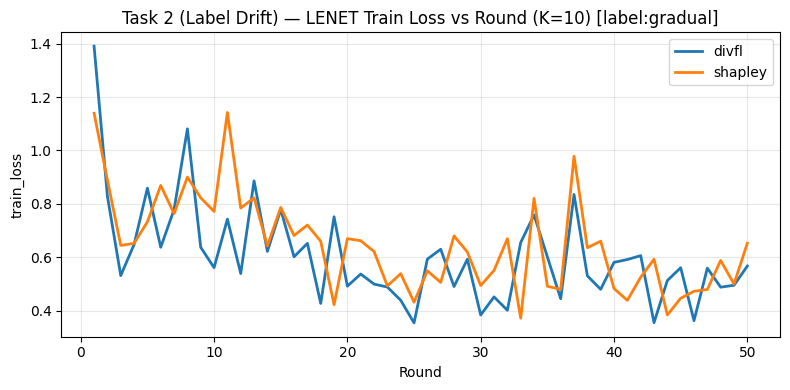

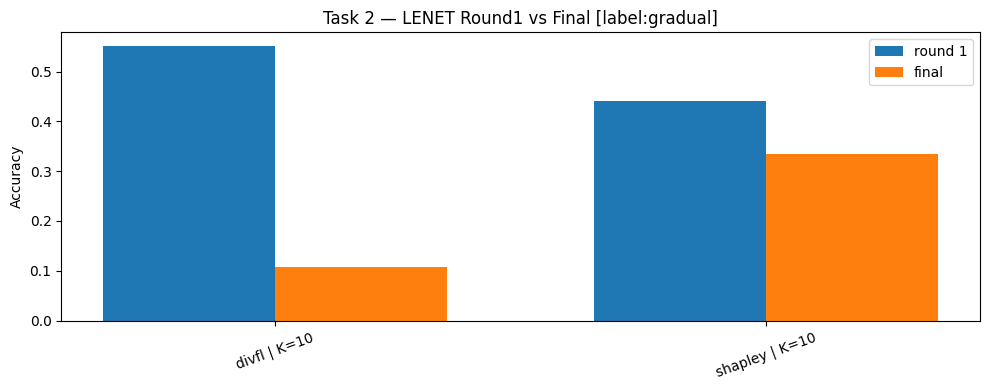

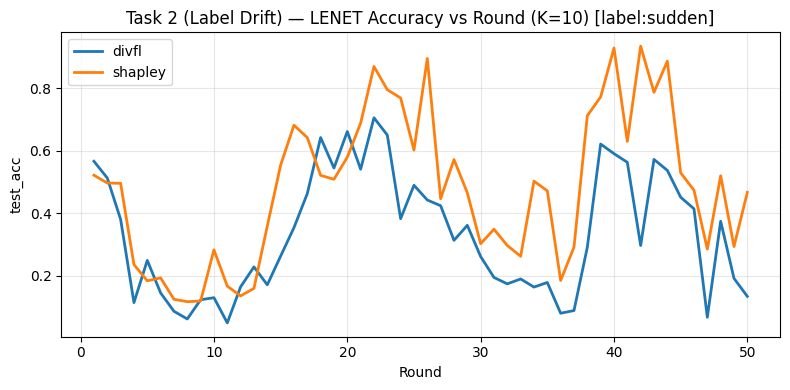

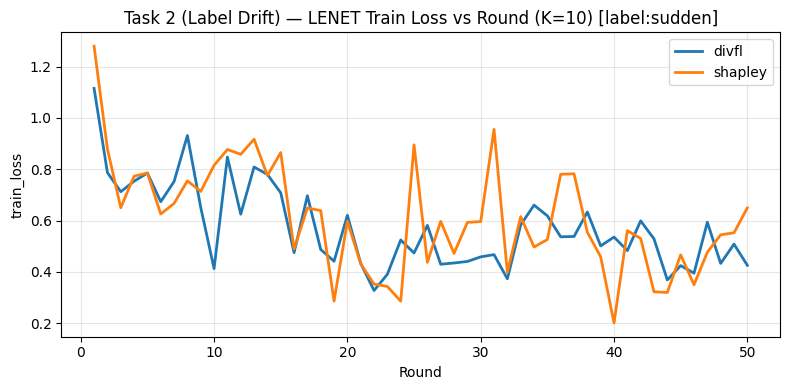

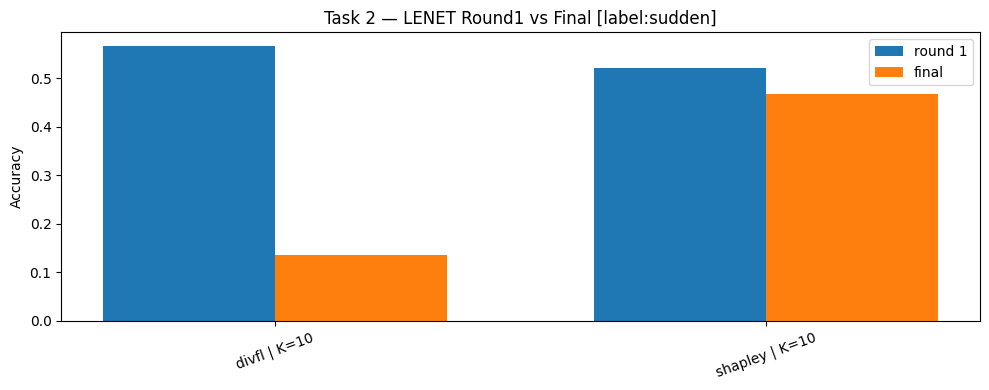

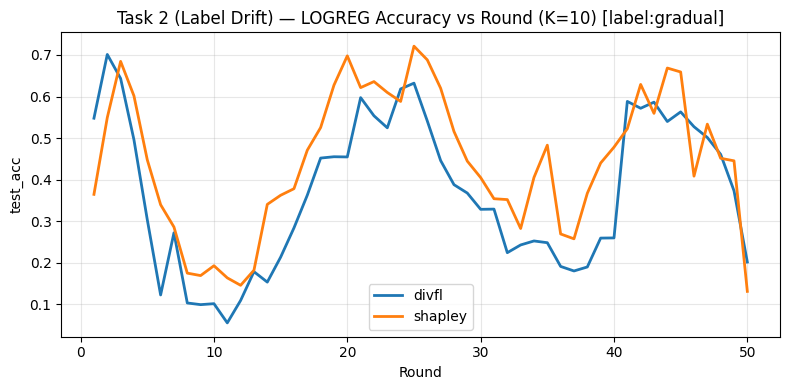

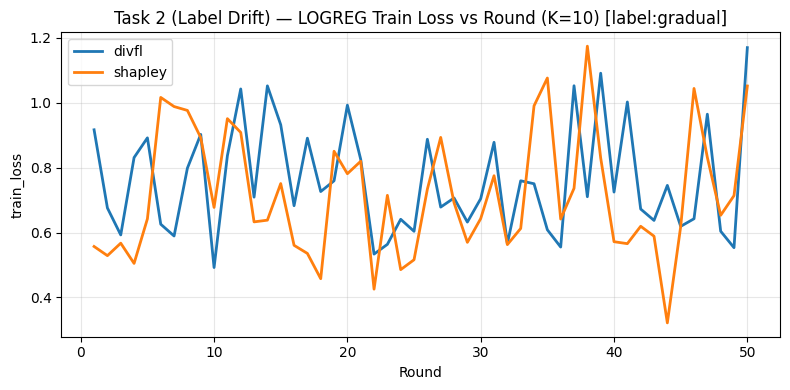

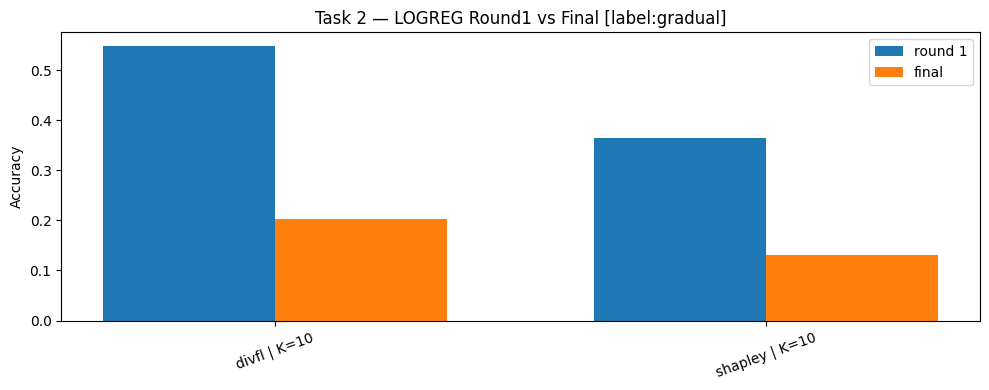

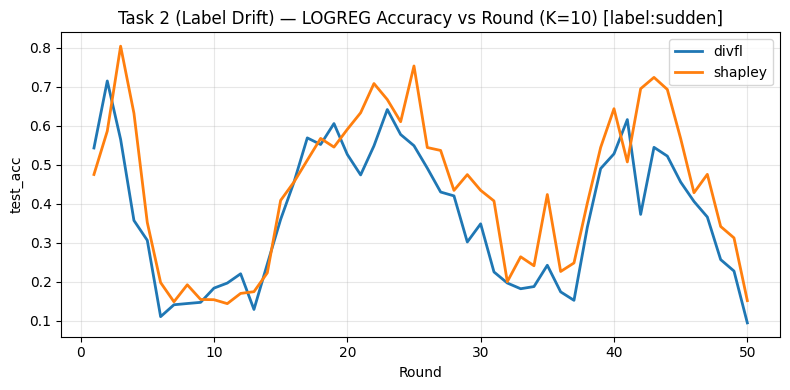

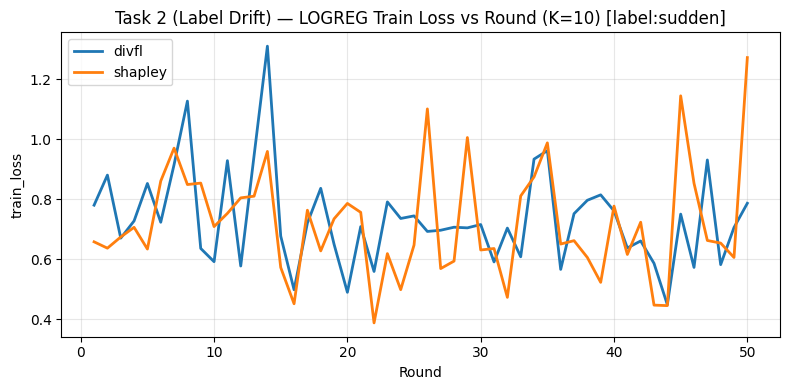

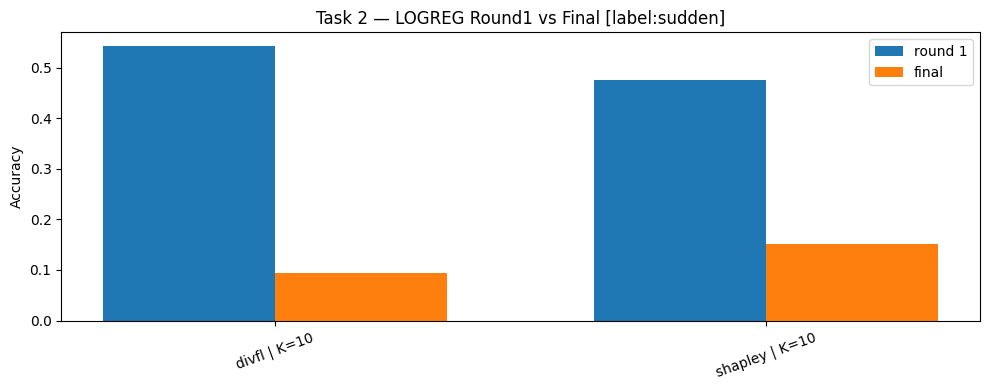

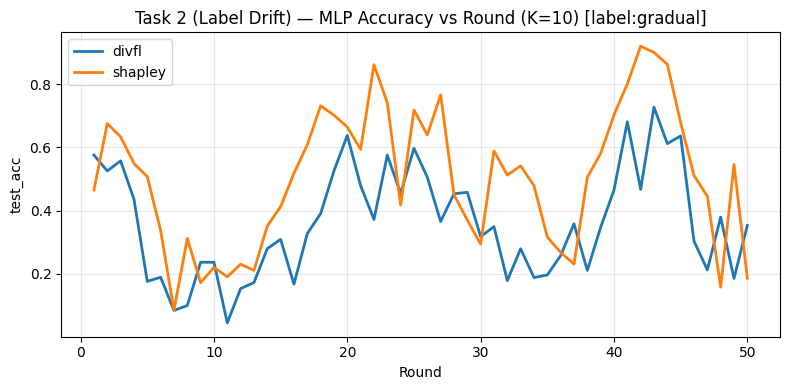

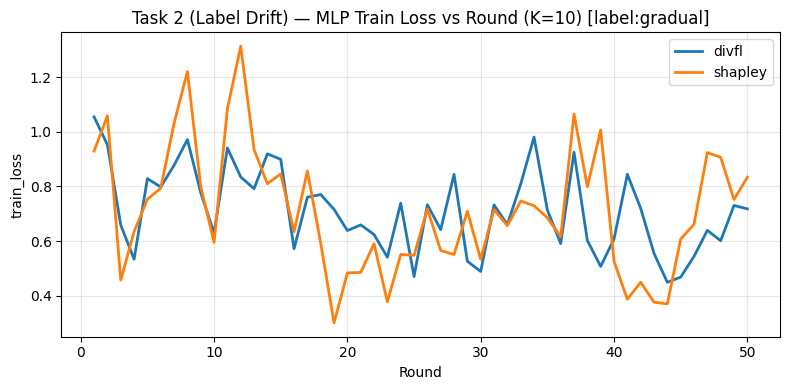

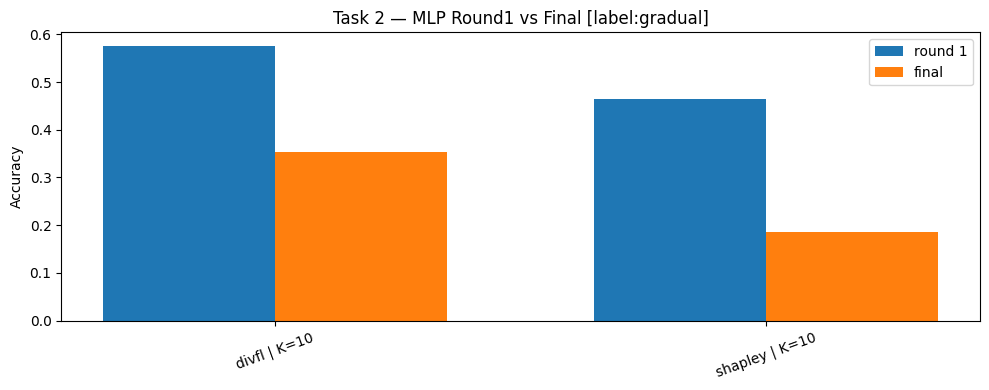

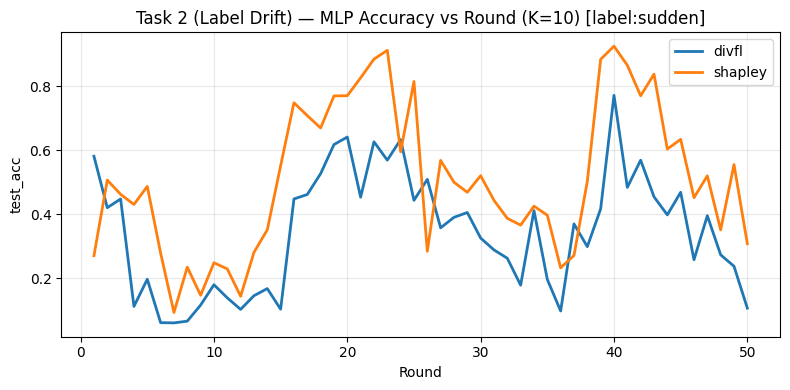

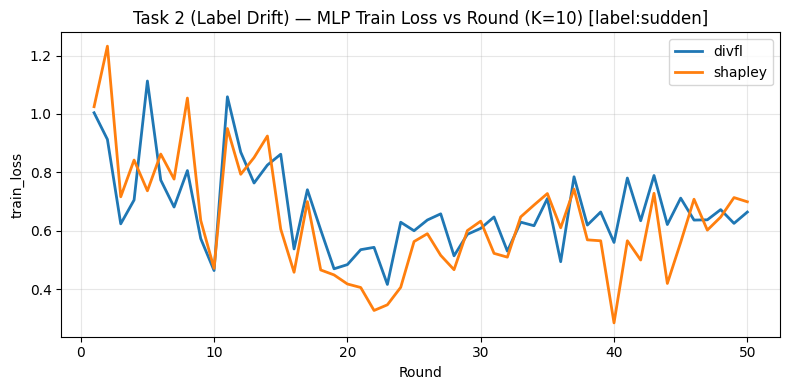

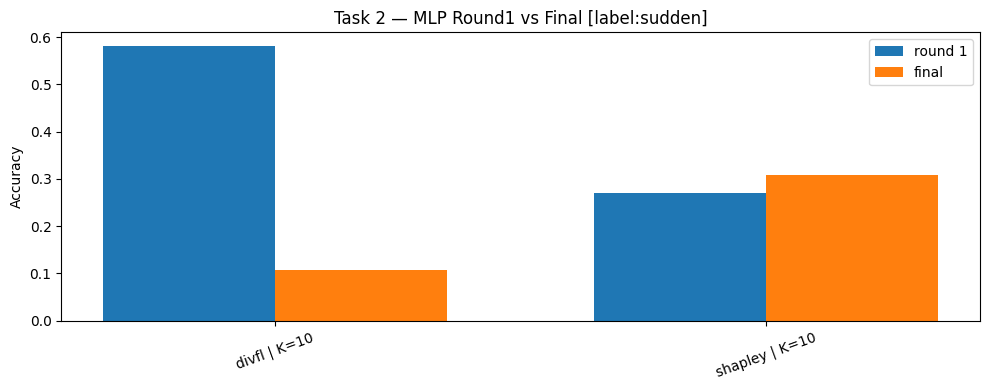

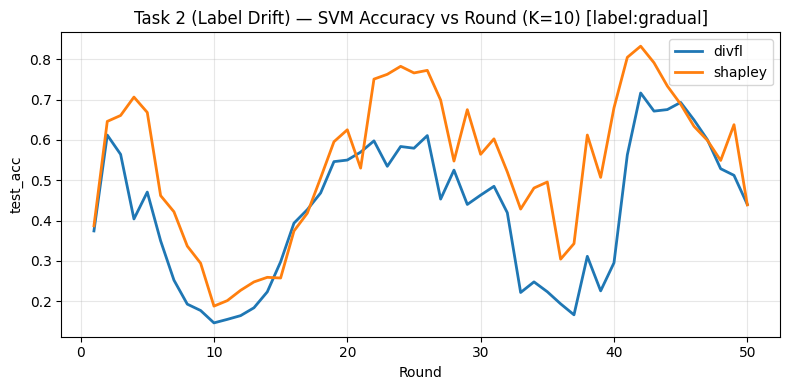

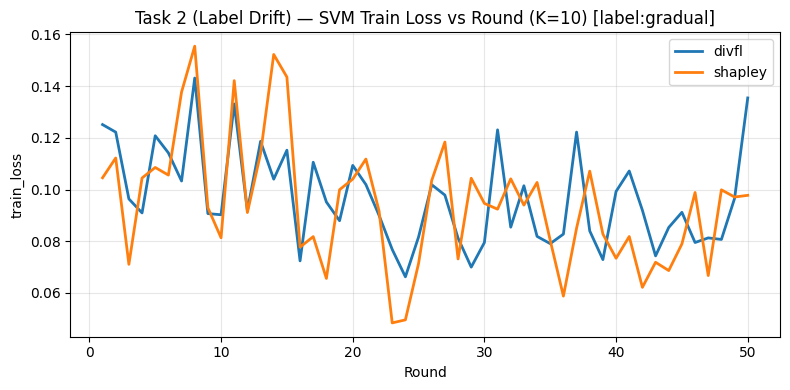

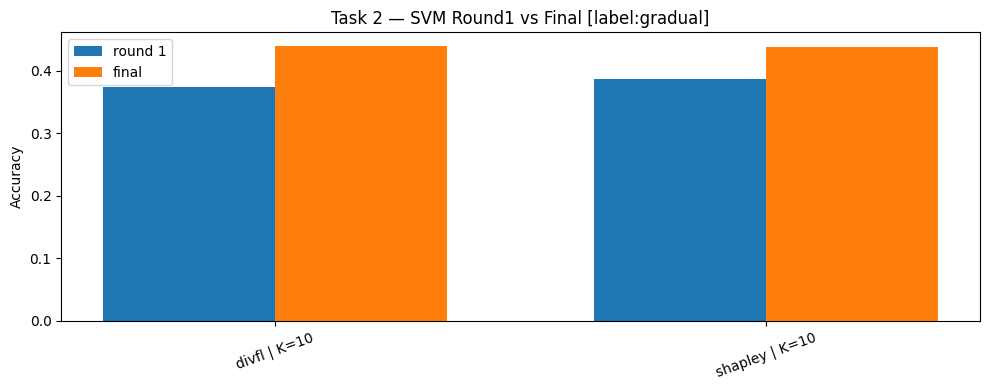

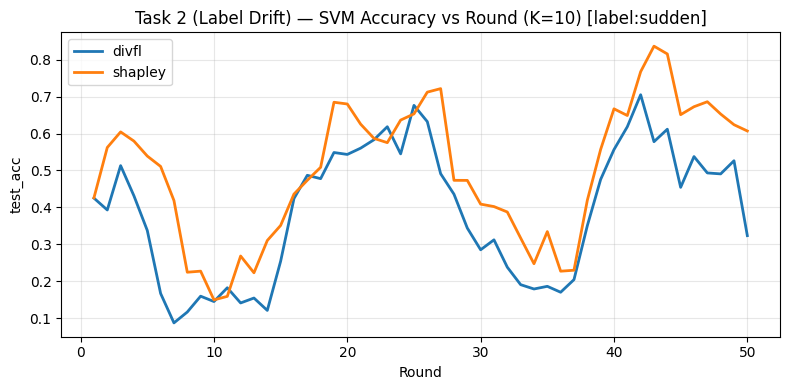

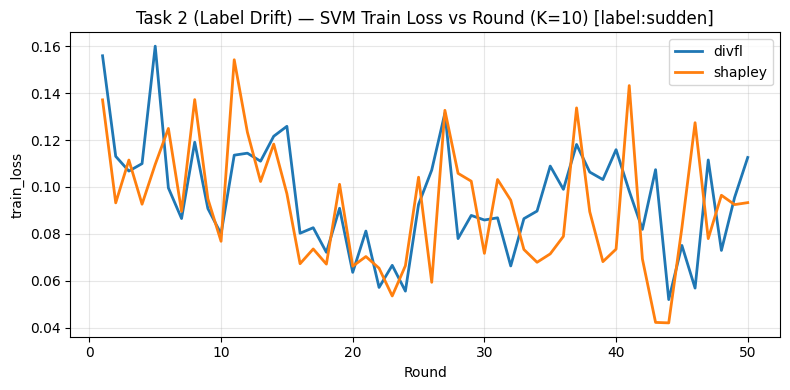

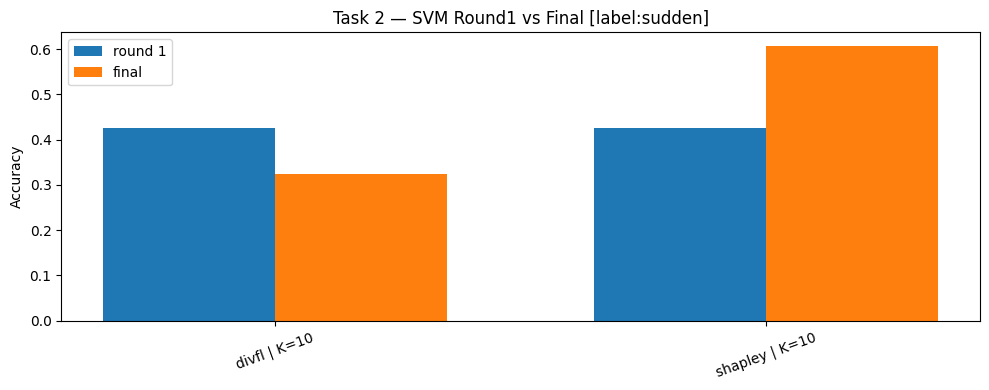

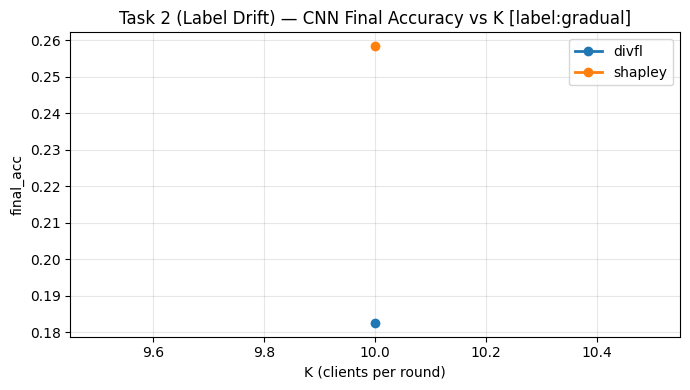

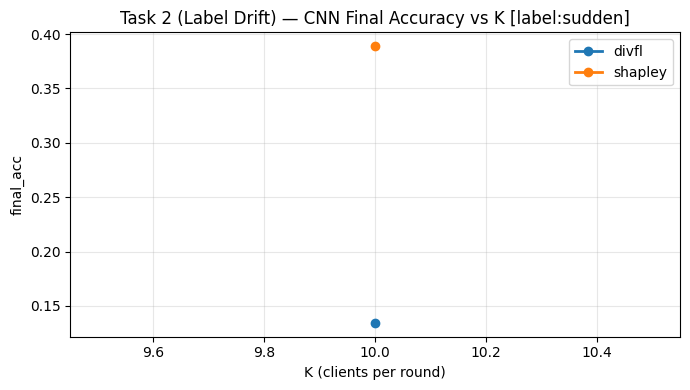

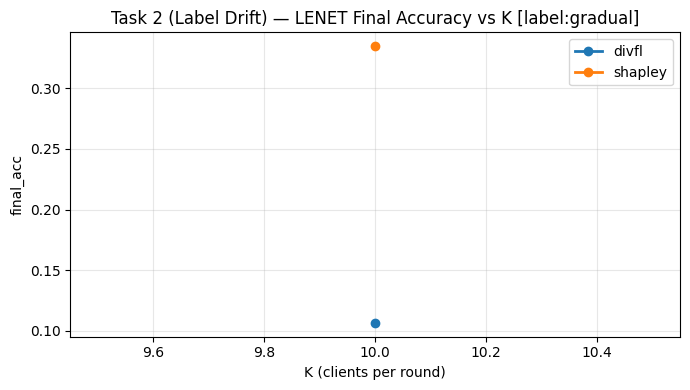

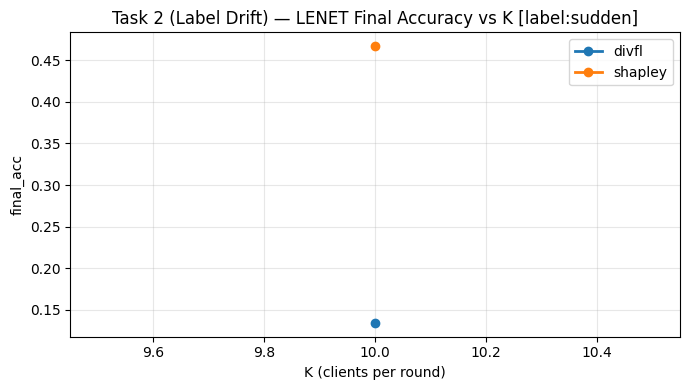

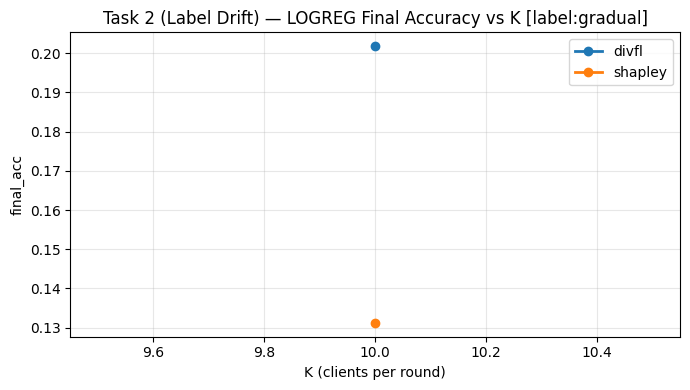

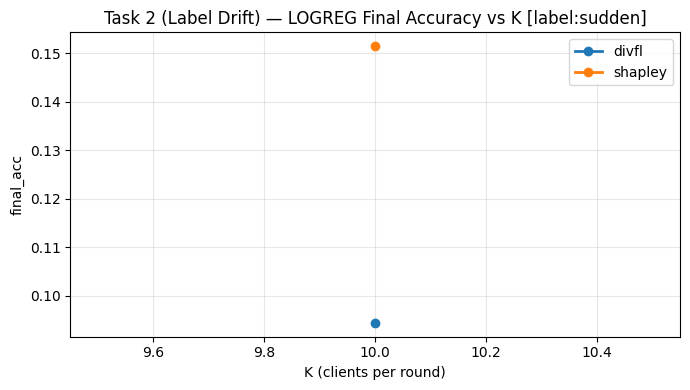

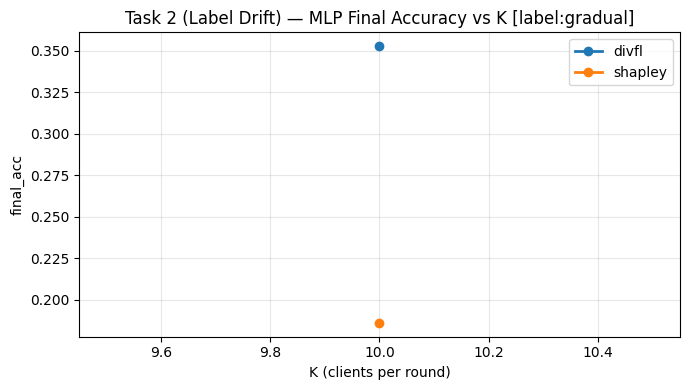

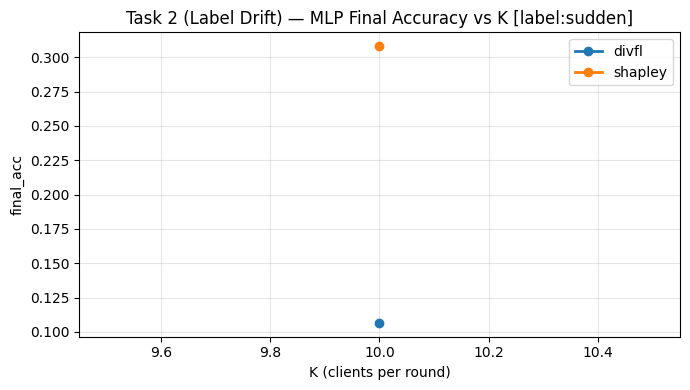

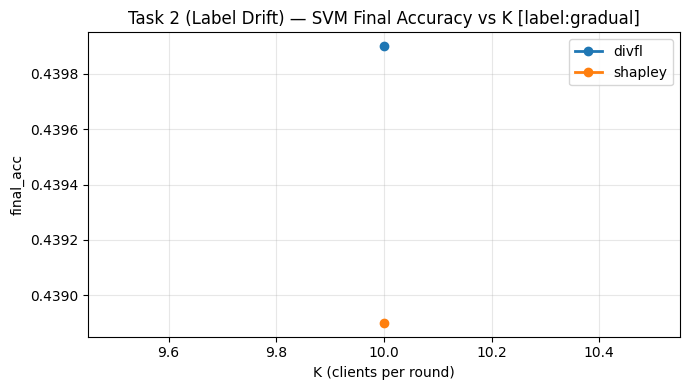

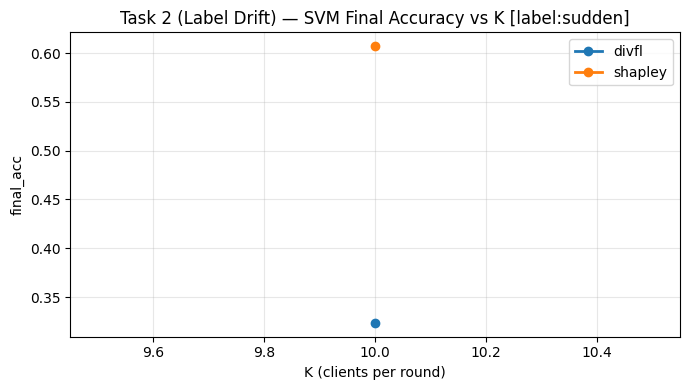

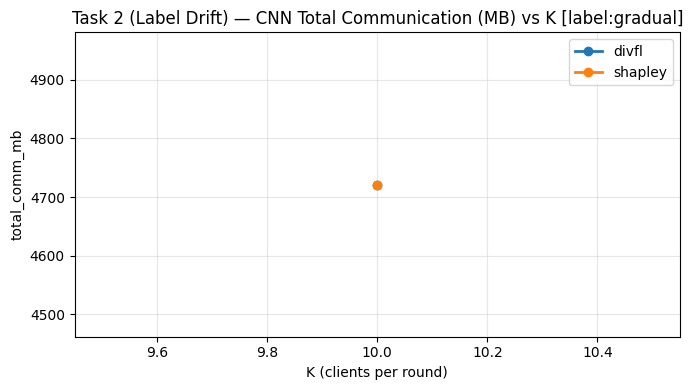

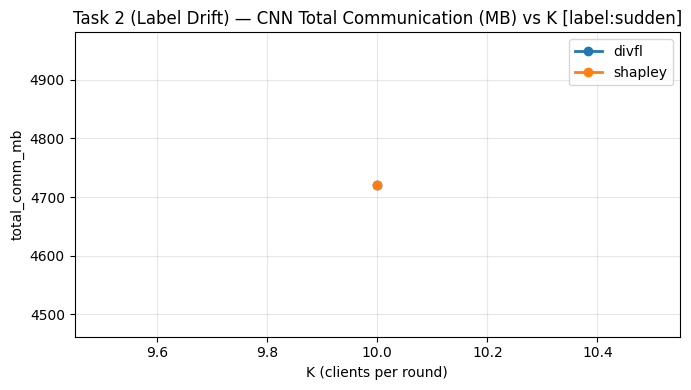

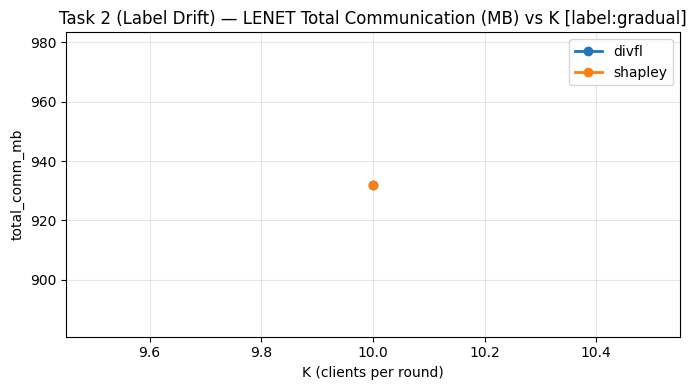

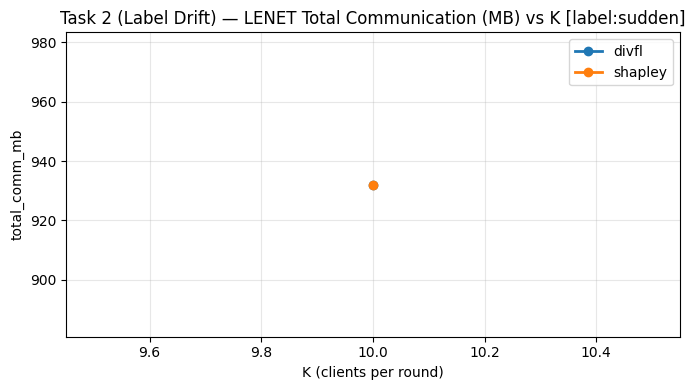

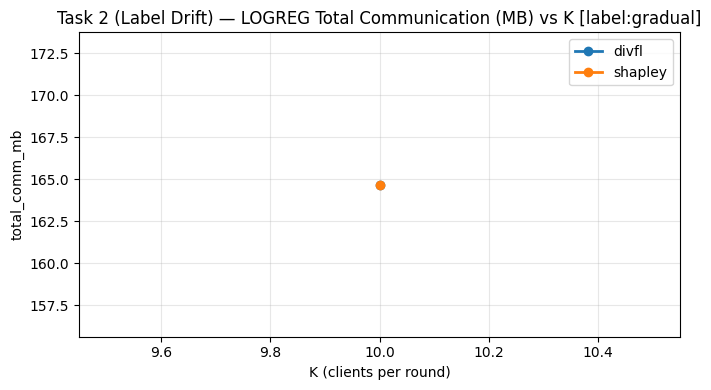

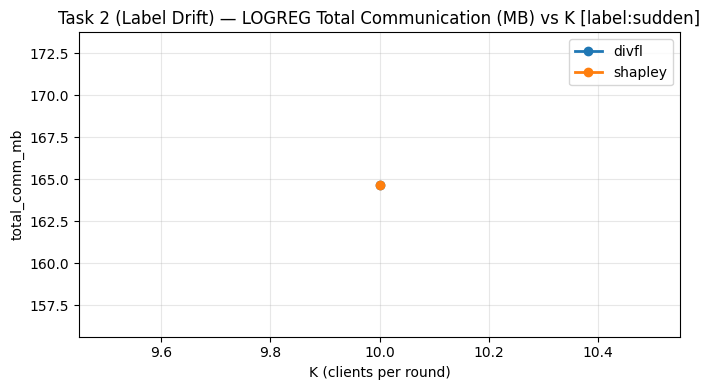

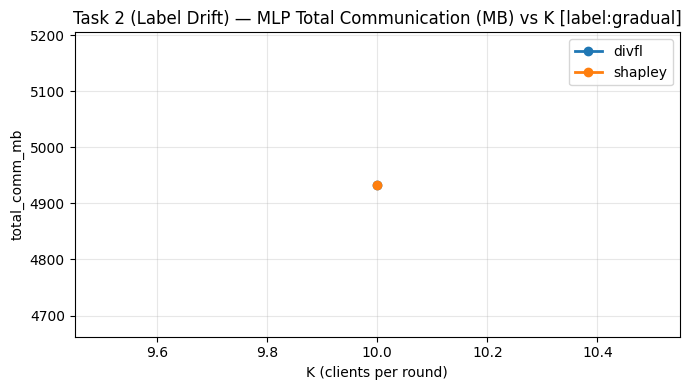

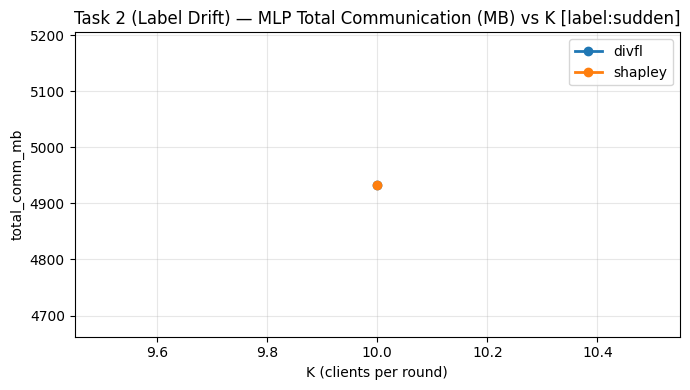

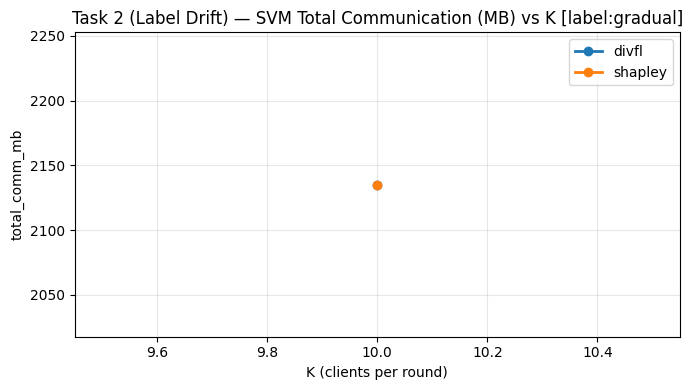

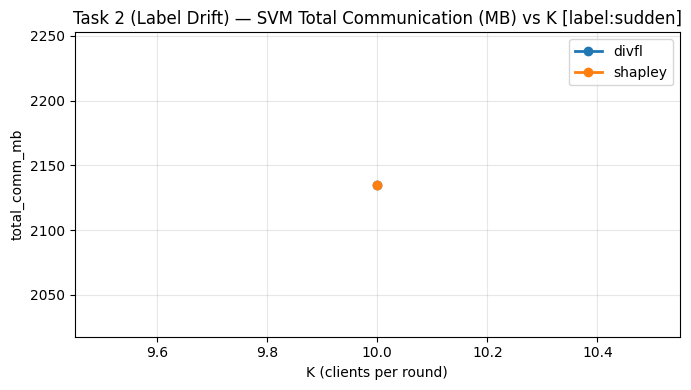

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

_need_plot_helpers = ["summarize_runs", "plot_convergence", "plot_final_vs_k"]
_missing_plot_helpers = [n for n in _need_plot_helpers if n not in globals()]
if _missing_plot_helpers:
    print(f"Missing plotting helper(s). Run setup/utility cells first: {_missing_plot_helpers}")
elif "drift_results" not in globals():
    print("Run the Task 2 drift experiment cells first to create `drift_results`.")
else:
    label_results = drift_results[drift_results["drift"].astype(str).str.lower() == "label"].copy()
    if label_results.empty:
        print("No label-drift rows found in `drift_results`. Run the Label Drift experiment cells first.")
    else:
        # Periodic drift has no single shift point; use round 1 as baseline and skip recovery metrics.
        drift_summary = summarize_runs(
            label_results,
            group_cols=["model", "strategy", "clients_per_round", "drift", "drift_mode"],
            shift_round=None,
        ).sort_values(["drift_mode", "model", "clients_per_round", "strategy"])
        display(drift_summary)

        # Baseline vs final (round 1 vs last round) under LABEL periodic drift only
        sorted_d = label_results.sort_values(["model", "strategy", "clients_per_round", "drift", "drift_mode", "round"]).copy()
        pre = (sorted_d[sorted_d["round"] == 1]
               .groupby(["model", "strategy", "clients_per_round", "drift", "drift_mode"], as_index=False)
               .tail(1)
               .rename(columns={"test_acc": "acc_round1"})
               .loc[:, ["model", "strategy", "clients_per_round", "drift", "drift_mode", "acc_round1"]])
        post = (sorted_d.groupby(["model", "strategy", "clients_per_round", "drift", "drift_mode"], as_index=False)
                .tail(1)
                .rename(columns={"test_acc": "acc_final"})
                .loc[:, ["model", "strategy", "clients_per_round", "drift", "drift_mode", "acc_final"]])
        drift_impact = pre.merge(post, on=["model", "strategy", "clients_per_round", "drift", "drift_mode"], how="inner")
        drift_impact["acc_drop"] = drift_impact["acc_round1"] - drift_impact["acc_final"]
        display(drift_impact.sort_values(["drift_mode", "model", "clients_per_round", "strategy"]))

        models_to_plot = sorted(label_results["model"].astype(str).unique())
        drift_modes_to_plot = sorted(label_results["drift_mode"].astype(str).unique())
        print(f"Plotting label drift for models: {models_to_plot}")

        # Convergence: all models under LABEL drift scenarios for K=10
        for model_name in models_to_plot:
            for drift_mode in drift_modes_to_plot:
                plot_convergence(
                    label_results,
                    title=f"Task 2 (Label Drift) — {model_name.upper()} Accuracy vs Round (K=10) [label:{drift_mode}]",
                    filter_dict={"model": model_name, "clients_per_round": 10, "drift": "label", "drift_mode": drift_mode},
                    hue="strategy",
                    y="test_acc",
                )
                if "train_loss" in label_results.columns:
                    plot_convergence(
                        label_results,
                        title=f"Task 2 (Label Drift) — {model_name.upper()} Train Loss vs Round (K=10) [label:{drift_mode}]",
                        filter_dict={"model": model_name, "clients_per_round": 10, "drift": "label", "drift_mode": drift_mode},
                        hue="strategy",
                        y="train_loss",
                    )

                # Round-1 vs final comparison (model-wise)
                g = drift_impact[
                    (drift_impact["model"] == model_name)
                    & (drift_impact["drift_mode"] == drift_mode)
                ].sort_values(["strategy", "clients_per_round"])
                if not g.empty:
                    labels = [f"{str(s)} | K={int(k)}" for s, k in zip(g["strategy"], g["clients_per_round"])]
                    x = np.arange(len(labels))
                    width = 0.35
                    plt.figure(figsize=(10, 4))
                    plt.bar(x - width / 2, g["acc_round1"], width, label="round 1")
                    plt.bar(x + width / 2, g["acc_final"], width, label="final")
                    plt.xticks(x, labels, rotation=20)
                    plt.ylabel("Accuracy")
                    plt.title(f"Task 2 — {model_name.upper()} Round1 vs Final [label:{drift_mode}]")
                    plt.legend()
                    plt.tight_layout()
                    plt.show()

        # Robustness vs K: all models final accuracy under LABEL drift scenarios
        for model_name in models_to_plot:
            for drift_mode in drift_modes_to_plot:
                plot_final_vs_k(
                    drift_summary,
                    title=f"Task 2 (Label Drift) — {model_name.upper()} Final Accuracy vs K [label:{drift_mode}]",
                    filter_dict={"model": model_name, "drift": "label", "drift_mode": drift_mode},
                    x="clients_per_round",
                    hue="strategy",
                    y="final_acc",
                )

        # Communication trade-off vs K under LABEL drift (all models)
        for model_name in models_to_plot:
            for drift_mode in drift_modes_to_plot:
                plot_final_vs_k(
                    drift_summary,
                    title=f"Task 2 (Label Drift) — {model_name.upper()} Total Communication (MB) vs K [label:{drift_mode}]",
                    filter_dict={"model": model_name, "drift": "label", "drift_mode": drift_mode},
                    x="clients_per_round",
                    hue="strategy",
                    y="total_comm_mb",
                )

# Task 3(a) — Update-Vector Clustering (Driftless)

**What we run (one algorithm):**
- Warm-up 2-3 rounds: send the same initial global model to all clients (or a small sample) and collect their updates.
- Client signature: model update $\Delta_i = w_i - w_{\mathrm{global}}$ using the last linear layer weights.
- Cluster signatures with k-means and sample $K$ clients proportionally from clusters each round.
- Maintain a running sum of each client update vector, refresh the client vector when selected, and re-run k-means every few rounds.
- Train locally (batch size 32, lr 0.001), then apply a FedAdam-style server update to a single global CNN.

**Output**
- The run cell creates `task3a_results` and `task3a_acc` (round / val_acc / test_acc).

In [ ]:
_need = [
    "cfg", "SEED", "DEVICE",
    "client_loaders", "client_num_samples",
    "compute_loss", "evaluate", "make_model",
    "clone_state_dict_cpu", "load_state_into", "fedavg_state_dict",
    "count_params", "estimate_comm_bytes", "estimate_compute_samples_selected",
    "val_loader", "test_loader",
    "torch", "np", "pd", "DataLoader", "nn", "Tuple", "Dict", "List", "Optional",
]
_missing = [n for n in _need if n not in globals()]
if _missing:
    raise RuntimeError(f"Run the earlier setup cells first; missing: {_missing}")

import copy
import math
import sys

# Fixed requirements
TASK3A_BATCH_SIZE = 32
TASK3A_LOCAL_LR = 1e-3


def _kmeans_lloyd(X: np.ndarray, k: int, seed: int, iters: int = 60) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    n, _d = X.shape
    if int(k) <= 1:
        return np.zeros(n, dtype=int)
    rng = np.random.default_rng(int(seed))
    centers = X[rng.choice(n, size=int(k), replace=False)].copy()
    labels = np.zeros(n, dtype=int)
    for _ in range(int(iters)):
        dists = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        new_labels = dists.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        for j in range(int(k)):
            mask = labels == j
            if not np.any(mask):
                centers[j] = X[rng.integers(0, n)]
            else:
                centers[j] = X[mask].mean(axis=0)
    return labels


def _state_zeros_like(state: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    out: Dict[str, torch.Tensor] = {}
    for k, v in state.items():
        out[k] = torch.zeros_like(v) if torch.is_floating_point(v) else v.clone()
    return out


def fedadam_server_step_delta(
    base_state: Dict[str, torch.Tensor],
    avg_state: Dict[str, torch.Tensor],
    m: Dict[str, torch.Tensor],
    v: Dict[str, torch.Tensor],
    t: int,
    beta1: float = 0.9,
    beta2: float = 0.99,
    eta: float = 1.0,
    tau: float = 1.0,
) -> Tuple[Dict[str, torch.Tensor], Dict[str, torch.Tensor], Dict[str, torch.Tensor]]:
    new_state: Dict[str, torch.Tensor] = {}
    b1t = float(beta1) ** float(t)
    b2t = float(beta2) ** float(t)
    for k in base_state.keys():
        w = base_state[k]
        if not torch.is_floating_point(w):
            new_state[k] = avg_state[k].clone()
            continue
        delta = (base_state[k] - avg_state[k])
        m[k] = beta1 * m[k] + (1.0 - beta1) * delta
        v[k] = beta2 * v[k] + (1.0 - beta2) * (delta * delta)
        m_hat = m[k] / max(1.0 - b1t, 1e-12)
        v_hat = v[k] / max(1.0 - b2t, 1e-12)
        new_state[k] = base_state[k] - eta * m_hat / (torch.sqrt(v_hat) + tau)
    return new_state, m, v


def train_one_client_task3a(
    global_model: nn.Module,
    client_loader: DataLoader,
    epochs: int,
    lr: float = TASK3A_LOCAL_LR,
) -> Tuple[Dict[str, torch.Tensor], float]:
    local_model = copy.deepcopy(global_model).to(DEVICE)
    local_model.train()
    opt = torch.optim.Adam(local_model.parameters(), lr=float(lr), weight_decay=float(cfg.weight_decay))
    total_loss = 0.0
    total_n = 0
    for _ in range(int(epochs)):
        for x, y in client_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            scores = local_model(x)
            loss = compute_loss(scores, y, model_name="cnn")
            loss.backward()
            opt.step()
            total_loss += float(loss.item()) * x.size(0)
            total_n += int(x.size(0))
    return clone_state_dict_cpu(local_model), float(total_loss / max(total_n, 1))


def build_task3a_loaders(batch_size: int = TASK3A_BATCH_SIZE) -> Dict[int, DataLoader]:
    loaders: Dict[int, DataLoader] = {}
    for cid, ldr in client_loaders.items():
        loaders[int(cid)] = DataLoader(
            ldr.dataset,
            batch_size=int(batch_size),
            shuffle=True,
            drop_last=False,
            num_workers=cfg.num_workers,
            pin_memory=(DEVICE.type == "cuda"),
        )
    return loaders


def _last_linear_param_names(model: nn.Module) -> List[str]:
    last_name = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            last_name = name
    state = model.state_dict()
    param_names: List[str] = []
    if last_name is not None:
        for suffix in ("weight", "bias"):
            key = f"{last_name}.{suffix}"
            if key in state:
                param_names.append(key)
    if not param_names:
        param_names = [k for k, v in state.items() if torch.is_floating_point(v)]
    if not param_names:
        raise RuntimeError("No float parameters found for update vectors")
    return param_names


def _flatten_update(
    base_state: Dict[str, torch.Tensor],
    client_state: Dict[str, torch.Tensor],
    param_names: List[str],
) -> np.ndarray:
    vecs = []
    for name in param_names:
        if name not in base_state or name not in client_state:
            continue
        delta = client_state[name] - base_state[name]
        vecs.append(delta.detach().cpu().reshape(-1))
    if not vecs:
        raise RuntimeError("Empty update vector; check param_names")
    return torch.cat(vecs).numpy().astype(np.float64)


def _alloc_k_per_cluster(cluster_sizes: Dict[int, int], k_total: int) -> Dict[int, int]:
    k_total = int(k_total)
    if k_total <= 0:
        return {c: 0 for c in cluster_sizes}
    total = float(sum(cluster_sizes.values()))
    raw = {c: (k_total * (sz / total)) for c, sz in cluster_sizes.items()}
    base = {c: int(math.floor(v)) for c, v in raw.items()}
    rem = k_total - sum(base.values())
    if rem > 0:
        frac = sorted(((raw[c] - base[c]), c) for c in base)
        for _, c in reversed(frac[:rem]):
            base[c] += 1
    return base


def _current_client_vectors(
    sums: np.ndarray,
    counts: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    denom = np.maximum(counts, 1.0)[:, None]
    vectors = sums / denom
    zero_mask = counts < 1e-6
    if np.any(zero_mask):
        vectors[zero_mask] = rng.normal(0.0, 1e-6, size=(int(zero_mask.sum()), vectors.shape[1]))
    return vectors


def _build_clusters_from_vectors(
    vectors: np.ndarray,
    num_clusters: int,
    seed: int,
) -> Dict[int, List[int]]:
    labels = _kmeans_lloyd(vectors, k=int(num_clusters), seed=int(seed), iters=60)
    clusters: Dict[int, List[int]] = {j: [] for j in range(int(num_clusters))}
    for cid in range(vectors.shape[0]):
        clusters[int(labels[cid])].append(int(cid))
    return clusters


def _warmup_client_vectors(
    global_model: nn.Module,
    client_loaders_32: Dict[int, DataLoader],
    param_names: List[str],
    warmup_rounds: int = 2,
    warmup_sample_size: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    num_clients = int(cfg.num_clients)
    base_state = clone_state_dict_cpu(global_model)
    dim = int(sum(int(base_state[name].numel()) for name in param_names if name in base_state))
    sums = np.zeros((num_clients, dim), dtype=np.float64)
    counts = np.zeros(num_clients, dtype=np.float64)
    if int(warmup_rounds) <= 0:
        return sums, counts

    rng = np.random.default_rng(int(SEED) + 5001)
    for _ in range(int(warmup_rounds)):
        if warmup_sample_size is None or int(warmup_sample_size) >= num_clients:
            clients = list(range(num_clients))
        else:
            clients = rng.choice(num_clients, size=int(warmup_sample_size), replace=False).tolist()
        for cid in clients:
            st, _loss = train_one_client_task3a(
                global_model=global_model,
                client_loader=client_loaders_32[int(cid)],
                epochs=int(cfg.local_epochs),
                lr=float(TASK3A_LOCAL_LR),
            )
            vec = _flatten_update(base_state, st, param_names)
            sums[int(cid)] += vec
            counts[int(cid)] += 1.0
    return sums, counts


def federated_train_task3a_clustered_fedadam(
    client_loaders_32: Optional[Dict[int, DataLoader]] = None,
    clients_per_round: int = 10,
    rounds: int = 20,
    num_clusters: int = 4,
    warmup_rounds: int = 2,
    warmup_sample_size: Optional[int] = None,
    recluster_every: int = 5,
    server_eta: float = 1.0,
    server_beta1: float = 0.9,
    server_beta2: float = 0.99,
    server_tau: float = 1.0,
    eval_test_every: int = 5,
    print_every: int = 1,
) -> pd.DataFrame:
    """Task 3(a): update-vector clustering + FedAdam server update (single global CNN)."""
    k = int(clients_per_round)
    rounds = int(rounds)
    if k <= 0 or k > cfg.num_clients:
        raise ValueError("invalid clients_per_round")
    if rounds <= 0:
        raise ValueError("rounds must be > 0")
    if client_loaders_32 is None:
        client_loaders_32 = build_task3a_loaders(batch_size=int(TASK3A_BATCH_SIZE))

    rng = np.random.default_rng(int(SEED) + 4001)

    global_model = make_model("cnn").to(DEVICE)
    model_params = int(count_params(global_model))
    param_names = _last_linear_param_names(global_model)

    state = clone_state_dict_cpu(global_model)
    m = _state_zeros_like(state)
    v = _state_zeros_like(state)
    t = 0

    client_vec_sums, client_vec_counts = _warmup_client_vectors(
        global_model=global_model,
        client_loaders_32=client_loaders_32,
        param_names=param_names,
        warmup_rounds=int(warmup_rounds),
        warmup_sample_size=warmup_sample_size,
    )

    client_vectors = _current_client_vectors(client_vec_sums, client_vec_counts, rng=rng)
    clusters = _build_clusters_from_vectors(
        client_vectors,
        num_clusters=int(num_clusters),
        seed=int(SEED) + 6001,
    )
    cluster_sizes = {j: len(v) for j, v in clusters.items() if len(v) > 0}
    if not cluster_sizes:
        raise RuntimeError("Empty clusters; check warmup and vectors")

    if int(print_every) > 0:
        warmup_note = f"warmup_rounds={int(warmup_rounds)}"
        sample_note = "all" if warmup_sample_size is None else str(int(warmup_sample_size))
        print(
            "Running Task 3(a): Update-Vector Clustering + FedAdam | "
            f"rounds={rounds} | K={k} | clusters={int(num_clusters)} | {warmup_note} | warmup_sample={sample_note}"
        )

    rows = []
    for rnd in range(1, rounds + 1):
        if int(recluster_every) > 0 and (rnd == 1 or ((rnd - 1) % int(recluster_every) == 0)):
            client_vectors = _current_client_vectors(client_vec_sums, client_vec_counts, rng=rng)
            clusters = _build_clusters_from_vectors(
                client_vectors,
                num_clusters=int(num_clusters),
                seed=int(SEED) + 6001 + int(rnd),
            )
            cluster_sizes = {j: len(v) for j, v in clusters.items() if len(v) > 0}
            if not cluster_sizes:
                raise RuntimeError("Empty clusters; check warmup and vectors")

        k_alloc = _alloc_k_per_cluster(cluster_sizes, k_total=k)
        selected: List[int] = []
        for j, _sz in cluster_sizes.items():
            kj = int(k_alloc.get(j, 0))
            if kj <= 0:
                continue
            cands = clusters.get(int(j), [])
            if not cands:
                continue
            pick = rng.choice(cands, size=min(kj, len(cands)), replace=False).tolist()
            selected.extend([int(x) for x in pick])
        if len(selected) < k:
            remaining = [cid for cid in range(cfg.num_clients) if cid not in set(selected)]
            need = k - len(selected)
            if remaining and need > 0:
                selected.extend(rng.choice(remaining, size=min(need, len(remaining)), replace=False).tolist())
        selected = selected[:k]

        base_state = state
        client_states: List[Dict[str, torch.Tensor]] = []
        client_weights: List[int] = []
        for cid in selected:
            st, _loss = train_one_client_task3a(
                global_model=global_model,
                client_loader=client_loaders_32[int(cid)],
                epochs=int(cfg.local_epochs),
                lr=float(TASK3A_LOCAL_LR),
            )
            client_states.append(st)
            client_weights.append(int(client_num_samples[int(cid)]))

            vec = _flatten_update(base_state, st, param_names)
            client_vec_sums[int(cid)] += vec
            client_vec_counts[int(cid)] += 1.0

        avg_state = fedavg_state_dict(base_state, client_states, client_weights)
        state, m, v = fedadam_server_step_delta(
            base_state=base_state,
            avg_state=avg_state,
            m=m,
            v=v,
            t=int(t + 1),
            beta1=float(server_beta1),
            beta2=float(server_beta2),
            eta=float(server_eta),
            tau=float(server_tau),
        )
        t += 1
        load_state_into(global_model, state)

        # metrics
        _vloss, val_acc = evaluate(global_model, val_loader, max_batches=None, model_name="cnn")
        _tfloss, test_acc_fast = evaluate(global_model, test_loader, max_batches=25, model_name="cnn")
        test_acc_full = np.nan
        if int(eval_test_every) > 0 and (rnd % int(eval_test_every) == 0 or rnd == 1):
            _tlloss, test_acc_full = evaluate(global_model, test_loader, max_batches=None, model_name="cnn")
        test_acc = float(test_acc_full) if not (isinstance(test_acc_full, float) and math.isnan(test_acc_full)) else float(test_acc_fast)

        comm_bytes = estimate_comm_bytes(num_selected=len(selected), model_params=model_params)
        compute_samples = estimate_compute_samples_selected(selected, epochs=int(cfg.local_epochs))

        rows.append({
            "round": int(rnd),
            "strategy": "task3a_clustered_fedadam",
            "clients_per_round": int(k),
            "num_clusters": int(num_clusters),
            "val_acc": float(val_acc),
            "test_acc": float(test_acc),
            "comm_bytes": int(comm_bytes),
            "compute_samples_total": int(compute_samples),
        })

        if int(print_every) > 0 and (rnd % int(print_every) == 0 or rnd == 1):
            sys.stdout.write(
                f"round {rnd}/{rounds} validation accuracy = {float(val_acc):.4f}, test acc = {float(test_acc):.4f}\n"
            )
            sys.stdout.flush()

    return pd.DataFrame(rows)


In [ ]:
TASK3A_NUM_CLUSTERS = 4
TASK3A_CLIENTS_PER_ROUND = 10
TASK3A_ROUNDS = 50  # set higher for full curves
TASK3A_WARMUP_ROUNDS = 2
TASK3A_WARMUP_SAMPLE = None  # set to int to use a subset of clients in warmup
TASK3A_RECLUSTER_EVERY = 5

task3a_client_loaders_32 = build_task3a_loaders(batch_size=int(TASK3A_BATCH_SIZE))

task3a_results = federated_train_task3a_clustered_fedadam(
    client_loaders_32=task3a_client_loaders_32,
    clients_per_round=int(TASK3A_CLIENTS_PER_ROUND),
    rounds=int(TASK3A_ROUNDS),
    num_clusters=int(TASK3A_NUM_CLUSTERS),
    warmup_rounds=int(TASK3A_WARMUP_ROUNDS),
    warmup_sample_size=TASK3A_WARMUP_SAMPLE,
    recluster_every=int(TASK3A_RECLUSTER_EVERY),
    server_eta=1.0,
    server_beta1=0.9,
    server_beta2=0.99,
    server_tau=1.0,
    eval_test_every=5,
    print_every=1,
)

# Store just the accuracies for easy reporting/plotting
task3a_acc = task3a_results[["round", "val_acc", "test_acc"]].copy()


Running Task 3(a): Update-Vector Clustering + FedAdam | rounds=50 | K=10 | clusters=4 | warmup_rounds=2 | warmup_sample=all
round 1/50 validation accuracy = 0.2896, test acc = 0.2915
round 2/50 validation accuracy = 0.5386, test acc = 0.5281
round 3/50 validation accuracy = 0.5962, test acc = 0.5959
round 4/50 validation accuracy = 0.7168, test acc = 0.7209
round 5/50 validation accuracy = 0.7930, test acc = 0.8110
round 6/50 validation accuracy = 0.8350, test acc = 0.8425
round 7/50 validation accuracy = 0.8652, test acc = 0.8788
round 8/50 validation accuracy = 0.8979, test acc = 0.9100
round 9/50 validation accuracy = 0.9189, test acc = 0.9297
round 10/50 validation accuracy = 0.9307, test acc = 0.9500
round 11/50 validation accuracy = 0.9419, test acc = 0.9503
round 12/50 validation accuracy = 0.9497, test acc = 0.9559
round 13/50 validation accuracy = 0.9551, test acc = 0.9597
round 14/50 validation accuracy = 0.9561, test acc = 0.9623
round 15/50 validation accuracy = 0.9590, tes

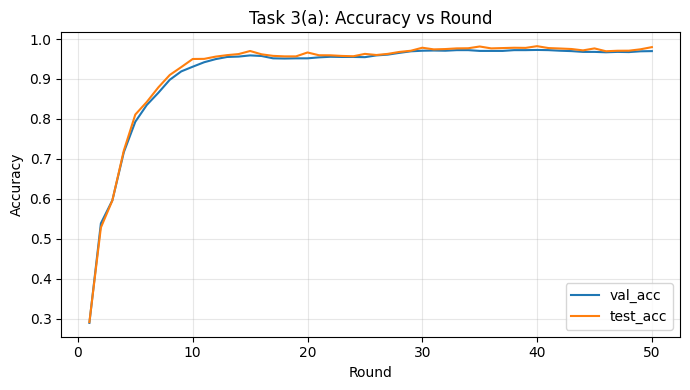

In [ ]:
import matplotlib.pyplot as plt

if "task3a_acc" not in globals():
    print("Run the Task 3(a) cell first to create `task3a_acc`.")
else:
    plt.figure(figsize=(7, 4))
    plt.plot(task3a_acc["round"], task3a_acc["val_acc"], label="val_acc")
    plt.plot(task3a_acc["round"], task3a_acc["test_acc"], label="test_acc")
    plt.title("Task 3(a): Accuracy vs Round")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Task 3(b) — FINAL: DA‑DUCB + Clustering + Multiple Global Models (Task 2 Drift)

**What we run (one algorithm)**
- Use **DA‑DUCB** to select `clients_per_round = K` clients each round.
- Train selected clients from a **consensus** server state.
- **Cluster the selected updates** and apply clusters across **M server models** (`num_server_models`).
- Evaluate with a **val‑weighted ensemble** of the M models.

**Output**
- Prints per round: `strategy`, `round`, `val_acc`, `test_acc`.
- The run cell stores `task3b_results` and a slim `task3b_acc` table for plotting.

In [ ]:

from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import copy
import math

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader



def _require_globals(names: List[str]) -> None:
    missing = [n for n in names if n not in globals()]
    if missing:
        raise RuntimeError(f"Missing required symbols. Run earlier cells first: {missing}")


@torch.no_grad()
def evaluate_ensemble(
    models: List[nn.Module],
    loader: DataLoader,
    max_batches: Optional[int] = None,
    model_name: str = "cnn",
    weights: Optional[List[float]] = None,
) -> Tuple[float, float]:
    """Evaluate an ensemble by averaging (or weighting) logits. Returns (loss, accuracy)."""
    if len(models) == 0:
        return float("nan"), float("nan")
    for m in models:
        m.eval()

    if weights is None:
        w = None
    else:
        w = np.asarray([float(x) for x in weights], dtype=np.float64)
        w = np.clip(w, 0.0, np.inf)
        if float(w.sum()) <= 0.0:
            w = None
        else:
            w = (w / float(w.sum())).astype(np.float64)

    total_loss = 0.0
    total_correct = 0
    total_n = 0
    batches = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits_sum = None
        if w is None:
            for m in models:
                s = m(x)
                logits_sum = s if logits_sum is None else (logits_sum + s)
            logits = logits_sum / float(len(models))
        else:
            for wi, m in zip(w.tolist(), models):
                s = m(x)
                logits_sum = s * float(wi) if logits_sum is None else (logits_sum + s * float(wi))
            logits = logits_sum

        loss = compute_loss(logits, y, model_name=model_name)
        total_loss += float(loss.item()) * x.size(0)
        total_correct += int((logits.argmax(dim=1) == y).sum().item())
        total_n += int(x.size(0))
        batches += 1
        if max_batches is not None and batches >= int(max_batches):
            break
    return total_loss / max(total_n, 1), total_correct / max(total_n, 1)


def _state_zeros_like(state: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    out: Dict[str, torch.Tensor] = {}
    for k, v in state.items():
        out[k] = torch.zeros_like(v) if torch.is_floating_point(v) else v.clone()
    return out


def fedadam_server_step_delta(
    base_state: Dict[str, torch.Tensor],
    avg_state: Dict[str, torch.Tensor],
    m: Dict[str, torch.Tensor],
    v: Dict[str, torch.Tensor],
    t: int,
    beta1: float = 0.9,
    beta2: float = 0.99,
    eta: float = 1.0,
    tau: float = 1.0,
) -> Tuple[Dict[str, torch.Tensor], Dict[str, torch.Tensor], Dict[str, torch.Tensor]]:
    """FedAdam server step using delta = w_t - w_avg (stable with large tau)."""
    new_state: Dict[str, torch.Tensor] = {}
    b1t = float(beta1) ** float(t)
    b2t = float(beta2) ** float(t)
    for k in base_state.keys():
        w = base_state[k]
        if not torch.is_floating_point(w):
            new_state[k] = avg_state[k].clone()
            continue
        delta = (base_state[k] - avg_state[k])
        m[k] = beta1 * m[k] + (1.0 - beta1) * delta
        v[k] = beta2 * v[k] + (1.0 - beta2) * (delta * delta)
        m_hat = m[k] / max(1.0 - b1t, 1e-12)
        v_hat = v[k] / max(1.0 - b2t, 1e-12)
        new_state[k] = base_state[k] - eta * m_hat / (torch.sqrt(v_hat) + tau)
    return new_state, m, v


def _minmax_norm(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=np.float64)
    if v.size == 0:
        return v
    vmin = float(v.min())
    vmax = float(v.max())
    if (vmax - vmin) < 1e-12:
        return np.zeros_like(v)
    return (v - vmin) / (vmax - vmin)


@torch.no_grad()
def _prediction_only_scores(
    model: nn.Module,
    loader: DataLoader,
    max_batches: int = 2,
    num_classes: int = 10,
) -> Tuple[float, float, float, np.ndarray]:
    """Return (entropy_mean, diversity, confidence_mean, pred_dist) with no label use."""
    model.eval()
    entropies = []
    confidences = []
    preds = []
    total = 0
    for b, (x, _) in enumerate(loader):
        x = x.to(DEVICE)
        probs = torch.softmax(model(x), dim=1).detach().cpu().numpy()
        ent = -np.sum(probs * np.log(probs + 1e-12), axis=1)
        conf = probs.max(axis=1)
        pred = probs.argmax(axis=1)
        entropies.append(ent)
        confidences.append(conf)
        preds.append(pred)
        total += int(x.shape[0])
        if b + 1 >= int(max_batches):
            break
    if total <= 0:
        q = np.full(int(num_classes), 1.0 / float(num_classes))
        return 0.0, 0.0, 0.0, q
    ent_all = np.concatenate(entropies) if len(entropies) else np.zeros((0,), dtype=np.float64)
    conf_all = np.concatenate(confidences) if len(confidences) else np.zeros((0,), dtype=np.float64)
    pred_all = np.concatenate(preds) if len(preds) else np.zeros((0,), dtype=np.int64)
    q = np.bincount(pred_all, minlength=int(num_classes)).astype(np.float64)
    q = q / max(float(q.sum()), 1.0)
    entropy_score = float(ent_all.mean()) if ent_all.size > 0 else 0.0
    diversity_score = float(1.0 - float(q.max())) if q.size > 0 else 0.0
    confidence_score = float(conf_all.mean()) if conf_all.size > 0 else 0.0
    return entropy_score, diversity_score, confidence_score, q


def train_one_client_task3b(
    global_model: nn.Module,
    client_loader: DataLoader,
    epochs: int,
    lr: float = 1e-3,
) -> Tuple[Dict[str, torch.Tensor], float]:
    """Fast local training under drift (no label remapping)."""
    local_model = copy.deepcopy(global_model).to(DEVICE)
    local_model.train()
    opt = torch.optim.Adam(local_model.parameters(), lr=float(lr), weight_decay=float(cfg.weight_decay))
    total_loss = 0.0
    total_n = 0
    for _ in range(int(epochs)):
        for x, y in client_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            scores = local_model(x)
            loss = compute_loss(scores, y, model_name="cnn")
            loss.backward()
            opt.step()
            total_loss += float(loss.item()) * x.size(0)
            total_n += int(x.size(0))
    return clone_state_dict_cpu(local_model), float(total_loss / max(total_n, 1))



def _kmeans_lloyd(X: np.ndarray, k: int, iters: int = 25, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(int(seed))
    n = int(X.shape[0])
    if n <= 0:
        return np.zeros((0,), dtype=np.int64)
    k = int(max(1, min(int(k), n)))
    centroids = X[rng.choice(n, size=k, replace=False)].copy()

    labels = np.zeros(n, dtype=np.int64)
    for _ in range(int(iters)):
        d2 = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        new_labels = d2.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        for j in range(k):
            mask = labels == j
            if mask.any():
                centroids[j] = X[mask].mean(axis=0)
            else:
                centroids[j] = X[rng.integers(0, n)]
    return labels



DADUCB_WEIGHTS = {
    "w_acc_gain": 1.2,
    "w_val_improve": 1.0,
    "w_div": 0.3,
    "w_rare": 0.6,
    "w_drift": 1.0,
    "w_comm": 0.05,
    "w_recent": 0.4,
}


@dataclass
class ClientDAStats:
    local_acc: float = 0.0
    local_loss: float = 2.3
    prev_local_acc: float = 0.0
    prev_local_loss: float = 2.3
    ema_val_improve: float = 0.0

    update_norm: float = 0.0
    prev_update_norm: float = 0.0
    drift_score: float = 0.0
    diversity_score: float = 0.0
    rare_label_score: float = 0.0

    comm_count: int = 0
    selection_count: int = 0
    last_selected_round: int = -999999

    pred_label_dist: Optional[np.ndarray] = None


def _safe_norm(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    return float(np.sqrt(np.sum(x * x)) + 1e-12)


def update_signature_from_states(base_state: Dict[str, torch.Tensor], client_state: Dict[str, torch.Tensor]) -> np.ndarray:
    feats: List[float] = []
    for k, w in base_state.items():
        if not torch.is_floating_point(w):
            continue
        d = (client_state[k] - base_state[k]).detach().cpu().numpy().astype(np.float64)
        feats.append(float(np.sqrt(np.sum(d * d)) + 1e-12))
        feats.append(float(d.mean()))
        feats.append(float(np.max(np.abs(d))))
    return np.asarray(feats, dtype=np.float64)


def compute_drift_score(
    stats: ClientDAStats,
    loss_now: float,
    sig_now: Optional[np.ndarray],
    kl_now: float = 0.0,
    a_loss: float = 1.0,
    a_sig: float = 0.5,
    a_norm: float = 0.5,
    a_kl: float = 0.25,
) -> float:
    loss_increase = max(0.0, float(loss_now) - float(stats.prev_local_loss))
    sig_jump = 0.0
    if sig_now is not None and stats.update_norm > 0 and stats.prev_update_norm > 0:
        sig_jump = _safe_norm(sig_now)
    norm_change = abs(float(stats.update_norm) - float(stats.prev_update_norm))
    return float(a_loss * loss_increase + a_sig * sig_jump + a_norm * norm_change + a_kl * float(kl_now))


def compute_client_reward(
    stats: ClientDAStats,
    round_num: int,
    global_sig: Optional[np.ndarray],
    weights: Dict[str, float],
) -> float:
    acc_gain = float(stats.local_acc) - float(stats.prev_local_acc)
    div = float(stats.diversity_score)
    rare = float(stats.rare_label_score)
    drift = float(stats.drift_score)
    comm = float(stats.comm_count)

    gap = max(0, int(round_num) - int(stats.last_selected_round))
    recent_pen = math.exp(-gap / 5.0) if gap >= 0 else 1.0

    r = (
        float(weights.get("w_acc_gain", 1.0)) * acc_gain
        + float(weights.get("w_val_improve", 1.0)) * float(stats.ema_val_improve)
        + float(weights.get("w_div", 0.0)) * div
        + float(weights.get("w_rare", 0.0)) * rare
        - float(weights.get("w_drift", 0.0)) * drift
        - float(weights.get("w_comm", 0.0)) * comm
        - float(weights.get("w_recent", 0.0)) * recent_pen
    )
    return float(r)


def discounted_ucb_selection(
    rewards: np.ndarray,
    reward_ema: np.ndarray,
    selection_count: np.ndarray,
    t: int,
    gamma: float,
    c: float,
    k: int,
    exploration_prob: float,
    rng: np.random.Generator,
) -> List[int]:
    rewards = np.asarray(rewards, dtype=np.float64)
    reward_ema[:] = float(gamma) * reward_ema + (1.0 - float(gamma)) * rewards
    bonus = float(c) * np.sqrt(np.log(float(t) + 2.0) / (selection_count + 1.0))
    ucb = reward_ema + bonus

    k = int(max(1, min(int(k), len(ucb))))
    k_explore = int(round(float(exploration_prob) * float(k)))
    k_explore = max(0, min(k - 1, k_explore))

    selected: List[int] = []
    if k_explore > 0:
        order = np.argsort(selection_count)
        pool = order[: min(len(order), 5 * k_explore)]
        explore = rng.choice(pool, size=k_explore, replace=False).tolist()
        selected.extend([int(x) for x in explore])

    mask = np.ones(len(ucb), dtype=bool)
    mask[selected] = False
    idx = np.argsort(-ucb)
    for i in idx:
        if mask[int(i)]:
            selected.append(int(i))
        if len(selected) > 0:
            sel_ids = [int(x) for x in selected]
            ent_vals = np.asarray([pred_entropy.get(cid, 0.0) for cid in sel_ids], dtype=np.float64)
            div_vals = np.asarray([pred_diversity.get(cid, 0.0) for cid in sel_ids], dtype=np.float64)
            out_vals = np.asarray([outlier_by_cid.get(cid, 0.0) for cid in sel_ids], dtype=np.float64)

            ent_n = _minmax_norm(ent_vals)
            div_n = _minmax_norm(div_vals)
            out_n = _minmax_norm(out_vals)

            for i, cid in enumerate(sel_ids):
                current = (
                    float(rare_w1) * float(ent_n[i])
                    + float(rare_w2) * float(div_n[i])
                    + float(rare_w3) * float(out_n[i])
                )
                stats[cid].rare_label_score = (
                    float(rare_alpha) * float(stats[cid].rare_label_score)
                    + (1.0 - float(rare_alpha)) * float(current)
                )
                stats[cid].diversity_score = float(div_n[i])
                stats[cid].pred_label_dist = pred_dist.get(cid)
    drift_category = str(drift_category).lower()
    periodic_mode = str(periodic_mode).lower()
    if drift_category == "mixed":
        ctrl_label = Task2StrongContinuousDriftController(
            drift_category="label",
            periodic_mode=periodic_mode,
            period_by_client=task2_period_by_client,
            start_round_by_client=task2_start_by_client,
            seed=int(SEED) + 7001 + int(seed_offset),
            **TASK2_LABEL_PARAMS,
        )
        ctrl_feat = Task2StrongContinuousDriftController(
            drift_category="feature",
            periodic_mode=periodic_mode,
            period_by_client=task2_period_by_client,
            start_round_by_client=task2_start_by_client,
            seed=int(SEED) + 8001 + int(seed_offset),
            **TASK2_FEATURE_PARAMS,
        )
        return ctrl_label, ctrl_feat

    ctrl = Task2StrongContinuousDriftController(
        drift_category=drift_category,
        periodic_mode=periodic_mode,
        period_by_client=task2_period_by_client,
        start_round_by_client=task2_start_by_client,
        seed=int(SEED) + 7001 + int(seed_offset),
        **(TASK2_LABEL_PARAMS if drift_category == "label" else {}),
        **(TASK2_FEATURE_PARAMS if drift_category == "feature" else {}),
    )
    return ctrl, None




def federated_train_task3_daducb_multiglobal(
    drift_category: str,
    periodic_mode: str,
    clients_per_round: int = 10,
    rounds: int = 50,
    num_server_models: int = 3,
    gamma: float = 0.90,
    ucb_c: float = 1.0,
    exploration_prob: float = 0.15,
    reward_weights: Optional[Dict[str, float]] = None,
    num_update_clusters: int = 3,
    local_batch_size: int = 32,
    local_lr: float = 1e-3,
    pred_score_batches: int = 2,
    rare_w1: float = 0.35,
    rare_w2: float = 0.25,
    rare_w3: float = 0.40,
    rare_alpha: float = 0.70,
    min_keep_val_improve: float = -0.01,
    server_eta: float = 1.0,
    server_beta1: float = 0.9,
    server_beta2: float = 0.99,
    server_tau: float = 1.0,
    inter_model_pull: float = 0.10,
    val_fast_batches: int = 25,
    test_fast_batches: int = 25,
    eval_test_every: int = 5,
    print_every: int = 1,
) -> pd.DataFrame:
    """Final Task 3(b) method.

    - Select clients with discounted-UCB (drift-aware).
    - Train selected clients from a consensus server state.
    - Cluster selected updates; apply each cluster to one of M server models.
    - Evaluate via val-weighted ensemble.

    Prints per round: strategy/round/val_acc/test_acc.
    """

    _require_globals([
        "Task2StrongContinuousDriftController",
        "task2_period_by_client",
        "task2_start_by_client",
        "TASK2_LABEL_PARAMS",
        "TASK2_FEATURE_PARAMS",
        "client_num_samples",
        "make_model",
        "clone_state_dict_cpu",
        "load_state_into",
        "evaluate",
        "val_loader",
        "test_loader",
        "count_params",
        "estimate_comm_bytes",
        "estimate_compute_samples_selected",
        "compute_loss",
        "DEVICE",
        "cfg",
        "SEED",
    ])

    drift_category = str(drift_category).lower()
    periodic_mode = str(periodic_mode).lower()
    if drift_category not in {"label", "feature", "mixed"}:
        raise ValueError("drift_category must be 'label', 'feature', or 'mixed'")
    if periodic_mode not in {"sudden", "gradual"}:
        raise ValueError("periodic_mode must be 'sudden' or 'gradual'")

    k = int(clients_per_round)
    rounds = int(rounds)
    num_server_models = int(num_server_models)
    if rounds <= 0:
        raise ValueError("rounds must be > 0")
    if k <= 0 or k > cfg.num_clients:
        raise ValueError("invalid clients_per_round")
    if num_server_models <= 0:
        raise ValueError("num_server_models must be > 0")

    w = dict(DADUCB_WEIGHTS)
    if reward_weights is not None:
        w.update({str(kk): float(vv) for kk, vv in reward_weights.items()})

    ctrl, ctrl_feat = _build_task2_controller(drift_category, periodic_mode, seed_offset=777)

    stats = [ClientDAStats() for _ in range(cfg.num_clients)]
    # rare_label_score starts at 0.0 (default); updated lazily on first selection

    reward_ema = np.zeros(cfg.num_clients, dtype=np.float64)
    selection_count = np.zeros(cfg.num_clients, dtype=np.float64)
    rng = np.random.default_rng(int(SEED) + 8080)

    init_model = make_model("cnn").to(DEVICE)
    init_state = clone_state_dict_cpu(init_model)
    server_states = [copy.deepcopy(init_state) for _ in range(num_server_models)]
    server_m = [_state_zeros_like(init_state) for _ in range(num_server_models)]
    server_v = [_state_zeros_like(init_state) for _ in range(num_server_models)]
    server_t = [0 for _ in range(num_server_models)]

    def _weighted_avg_states(states: List[Dict[str, torch.Tensor]], weights: List[float]) -> Dict[str, torch.Tensor]:
        wsum = float(sum(weights))
        if wsum <= 0.0:
            return states[0]
        out: Dict[str, torch.Tensor] = {}
        for kk in states[0].keys():
            if torch.is_floating_point(states[0][kk]):
                acc = None
                for st, wt in zip(states, weights):
                    term = st[kk] * float(wt)
                    acc = term if acc is None else (acc + term)
                out[kk] = acc / float(wsum)
            else:
                out[kk] = states[0][kk].clone()
        return out

    def _state_add_delta(base: Dict[str, torch.Tensor], delta: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        out: Dict[str, torch.Tensor] = {}
        for kk in base.keys():
            if torch.is_floating_point(base[kk]):
                out[kk] = base[kk] + delta[kk]
            else:
                out[kk] = base[kk].clone()
        return out

    strategy = f"task3b_daducb_clustered_multiglobal(M={num_server_models})"
    if int(print_every) > 0:
        print(
            f"Running Task 3(b): DA-DUCB + clustering + multiple global models (Task 2 drift) | "
            f"drift={drift_category}:{periodic_mode} | rounds={rounds} | K={k} | M={num_server_models} | update_clusters={int(num_update_clusters)}"
        )

    rows: List[Dict] = []
    for rnd in range(1, rounds + 1):
        if drift_category == "mixed":
            meta1 = ctrl.update_round(rnd)
            meta2 = ctrl_feat.update_round(rnd) if ctrl_feat is not None else {}
            for cid in range(cfg.num_clients):
                ctrl.datasets[cid].transform = ctrl_feat.datasets[cid].transform
            meta = {
                "drift": "mixed",
                "drift_mode": periodic_mode,
                "drift_fraction": float(max(meta1.get("drift_fraction", 0.0), meta2.get("drift_fraction", 0.0))),
            }
        else:
            meta = ctrl.update_round(rnd)

        # consensus state = val-weighted average of server models
        models_list = []
        w_val = []
        for j in range(num_server_models):
            tmp = make_model("cnn").to(DEVICE)
            load_state_into(tmp, server_states[j])
            models_list.append(tmp)
            _, a = evaluate(tmp, val_loader, max_batches=max(1, int(val_fast_batches // 5)), model_name="cnn")
            w_val.append(float(a) + 1e-3)
        base_state = _weighted_avg_states(server_states, w_val)

        # selection rewards
        rewards = np.zeros(cfg.num_clients, dtype=np.float64)
        for cid in range(cfg.num_clients):
            rewards[cid] = compute_client_reward(stats[cid], round_num=rnd, global_sig=None, weights=w)

        ranked = discounted_ucb_selection(
            rewards=rewards,
            reward_ema=reward_ema,
            selection_count=selection_count,
            t=rnd,
            gamma=float(gamma),
            c=float(ucb_c),
            k=max(k, min(cfg.num_clients, 3 * k)),
            exploration_prob=float(exploration_prob),
            rng=rng,
        )
        selected = []
        for cid in ranked:
            selected.append(int(cid))
            if len(selected) >= k:
                break
        if len(selected) < k:
            rest = [i for i in range(cfg.num_clients) if i not in set(selected)]
            selected.extend(rng.choice(rest, size=k - len(selected), replace=False).tolist())

        for cid in selected:
            stats[cid].selection_count += 1
            selection_count[cid] += 1.0
            stats[cid].comm_count += 1
            stats[cid].last_selected_round = int(rnd)

        base_model = make_model("cnn").to(DEVICE)
        load_state_into(base_model, base_state)
        _, base_val_fast = evaluate(base_model, val_loader, max_batches=max(1, int(val_fast_batches // 5)), model_name="cnn")
        base_val_fast = float(base_val_fast)

        kept_states = []
        kept_weights = []
        kept_sigs = []
        kept_drift_scores = []
        kept_cids = []

        pred_entropy: Dict[int, float] = {}
        pred_diversity: Dict[int, float] = {}
        pred_conf: Dict[int, float] = {}
        pred_dist: Dict[int, np.ndarray] = {}

        for cid in selected:
            ds = ctrl.datasets[int(cid)]
            ldr = DataLoader(
                ds,
                batch_size=int(local_batch_size),
                shuffle=True,
                drop_last=False,
                num_workers=cfg.num_workers,
                pin_memory=(DEVICE.type == "cuda"),
            )

            ent_s, div_s, conf_s, q = _prediction_only_scores(
                model=base_model,
                loader=ldr,
                max_batches=int(pred_score_batches),
                num_classes=10,
            )
            pred_entropy[int(cid)] = float(ent_s)
            pred_diversity[int(cid)] = float(div_s)
            pred_conf[int(cid)] = float(conf_s)
            pred_dist[int(cid)] = q

            local_model = make_model("cnn").to(DEVICE)
            load_state_into(local_model, base_state)
            st, train_loss = train_one_client_task3b(
                global_model=local_model,
                client_loader=ldr,
                epochs=int(cfg.local_epochs),
                lr=float(local_lr),
            )
            local_model2 = make_model("cnn").to(DEVICE)
            load_state_into(local_model2, st)

            _, val_after = evaluate(local_model2, val_loader, max_batches=max(1, int(val_fast_batches // 10)), model_name="cnn")
            val_improve = float(val_after) - float(base_val_fast)
            if float(val_improve) < float(min_keep_val_improve):
                s = stats[cid]
                s.prev_local_acc, s.prev_local_loss = float(s.local_acc), float(s.local_loss)
                proxy_acc = float(pred_conf.get(int(cid), 0.0))
                s.local_acc = proxy_acc
                s.local_loss = float(1.0 - proxy_acc)
                s.ema_val_improve = 0.8 * float(s.ema_val_improve) + 0.2 * float(val_improve)
                continue

            s = stats[cid]
            s.prev_local_acc, s.prev_local_loss = float(s.local_acc), float(s.local_loss)
            proxy_acc = float(pred_conf.get(int(cid), 0.0))
            s.local_acc = proxy_acc
            s.local_loss = float(1.0 - proxy_acc)
            s.ema_val_improve = 0.8 * float(s.ema_val_improve) + 0.2 * float(val_improve)

            sig = update_signature_from_states(base_state, st)
            s.prev_update_norm = float(s.update_norm)
            s.update_norm = _safe_norm(sig)
            s.drift_score = compute_drift_score(s, loss_now=float(s.local_loss), sig_now=sig, kl_now=0.0)

            wt = float(client_num_samples[int(cid)])
            wt = wt * float(np.clip(s.local_acc, 0.1, 1.0))
            kept_states.append(st)
            kept_weights.append(max(1.0, wt))
            kept_sigs.append(sig)
            kept_drift_scores.append(float(s.drift_score))
            kept_cids.append(int(cid))

        # Prediction-only rarity update: entropy + diversity + update outlier
        outlier_by_cid: Dict[int, float] = {}
        # cluster updates and apply to multiple server models
        cluster_sizes: List[int] = []
        if len(kept_states) > 0:
            sigs = np.stack(kept_sigs, axis=0)
            labels = cluster_selected_clients(sigs, n_clusters=int(num_update_clusters), seed=int(SEED) + 9999 + rnd)

            for cl in sorted(set(labels.tolist())):
                idxs = np.where(labels == int(cl))[0].tolist()
                if len(idxs) == 0:
                    continue
                centroid = sigs[idxs].mean(axis=0)
                dists = np.linalg.norm(sigs[idxs] - centroid, axis=1)
                spread = float(np.std(dists)) + 1e-12
                for ii, dist in zip(idxs, dists.tolist()):
                    outlier_by_cid[int(kept_cids[ii])] = float(dist) / spread

            cluster_avg_states = []
            for cl in sorted(set(labels.tolist())):
                idxs = np.where(labels == int(cl))[0].tolist()
                st_list = [kept_states[i] for i in idxs]
                wt_list = [float(kept_weights[i]) for i in idxs]
                cs = _weighted_avg_states(st_list, wt_list)
                cluster_avg_states.append((int(cl), cs))
                cluster_sizes.append(int(len(idxs)))

            for (cl, cs) in cluster_avg_states:
                delta: Dict[str, torch.Tensor] = {}
                for kk in base_state.keys():
                    if torch.is_floating_point(base_state[kk]):
                        delta[kk] = (cs[kk] - base_state[kk])
                    else:
                        delta[kk] = base_state[kk].clone()

                j = int(cl) % int(num_server_models)
                base_j = server_states[j]
                avg_j = _state_add_delta(base_j, delta)
                server_t[j] += 1
                new_j, server_m[j], server_v[j] = fedadam_server_step_delta(
                    base_state=base_j,
                    avg_state=avg_j,
                    m=server_m[j],
                    v=server_v[j],
                    t=int(server_t[j]),
                    beta1=float(server_beta1),
                    beta2=float(server_beta2),
                    eta=float(server_eta),
                    tau=float(server_tau),
                )
                server_states[j] = new_j
        else:
            cluster_sizes = [0]

        if len(selected) > 0:
            sel_ids = [int(x) for x in selected]
            ent_vals = np.asarray([pred_entropy.get(cid, 0.0) for cid in sel_ids], dtype=np.float64)
            div_vals = np.asarray([pred_diversity.get(cid, 0.0) for cid in sel_ids], dtype=np.float64)
            out_vals = np.asarray([outlier_by_cid.get(cid, 0.0) for cid in sel_ids], dtype=np.float64)

            ent_n = _minmax_norm(ent_vals)
            div_n = _minmax_norm(div_vals)
            out_n = _minmax_norm(out_vals)

            for i, cid in enumerate(sel_ids):
                current = (
                    float(rare_w1) * float(ent_n[i])
                    + float(rare_w2) * float(div_n[i])
                    + float(rare_w3) * float(out_n[i])
                )
                stats[cid].rare_label_score = (
                    float(rare_alpha) * float(stats[cid].rare_label_score)
                    + (1.0 - float(rare_alpha)) * float(current)
                )
                stats[cid].diversity_score = float(div_n[i])
                stats[cid].pred_label_dist = pred_dist.get(cid)

In [ ]:


import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader


_need_task3b = [
    "Task2StrongContinuousDriftController",
    "task2_period_by_client",
    "task2_start_by_client",
    "TASK2_LABEL_PARAMS",
    "cfg",
    "SEED",
    "DEVICE",
    "client_num_samples",
    "make_model",
    "clone_state_dict_cpu",
    "load_state_into",
    "compute_loss",
    "evaluate",
    "count_params",
    "estimate_comm_bytes",
    "estimate_compute_samples_selected",
    "val_loader",
    "test_loader",
    "federated_train",
]
_missing_task3b = [n for n in _need_task3b if n not in globals()]
if _missing_task3b:
    raise RuntimeError(f"Run setup/Task2 cells first; missing: {_missing_task3b}")


TASK3B_CFG = {
    "rounds": 50,
    "clients_per_round": 12,
    "num_server_models": 3,
    "num_update_clusters": 3,
    "local_batch_size": 32,
    "local_lr": 7e-4,
    "gamma": 0.92,
    "ucb_c": 0.90,
    "exploration_prob": 0.20,
    "warmup_rounds": 4,
    "clip_mult": 1.5,
    "inter_model_pull": 0.18,
    "val_fast_batches": 25,
    "test_fast_batches": 25,
    "eval_test_every": 1,
    "print_every": 1,
}

TASK2_COMPARE_CFG = {
    "model": "cnn",
    "strategy": "shapley",
    "clients_per_round": int(TASK3B_CFG["clients_per_round"]),
    "rounds": int(TASK3B_CFG["rounds"]),
}


def _merge_cfg(defaults: dict, override: dict = None) -> dict:
    out = dict(defaults)
    if override is not None:
        out.update(override)
    return out


def _fmt_acc(x) -> str:
    try:
        if pd.isna(x):
            return "NA"
    except Exception:
        pass
    return f"{float(x):.4f}"


def _state_weighted_average(states, weights):
    wsum = float(sum(weights))
    if wsum <= 0.0:
        return copy.deepcopy(states[0])
    out = {}
    for k in states[0].keys():
        if torch.is_floating_point(states[0][k]):
            acc = None
            for st, wt in zip(states, weights):
                term = st[k] * float(wt)
                acc = term if acc is None else (acc + term)
            out[k] = acc / float(wsum)
        else:
            out[k] = states[0][k].clone()
    return out


def _state_lerp(a, b, alpha):
    alpha = float(np.clip(alpha, 0.0, 1.0))
    out = {}
    for k in a.keys():
        if torch.is_floating_point(a[k]):
            out[k] = (1.0 - alpha) * a[k] + alpha * b[k]
        else:
            out[k] = a[k].clone()
    return out


def _state_zeros_like(state):
    out = {}
    for k, v in state.items():
        out[k] = torch.zeros_like(v) if torch.is_floating_point(v) else v.clone()
    return out


def _state_delta_norm(base_state, client_state):
    s = 0.0
    for k in base_state.keys():
        if not torch.is_floating_point(base_state[k]):
            continue
        d = (client_state[k] - base_state[k]).detach().cpu().double()
        s += float((d * d).sum().item())
    return float(math.sqrt(max(s, 1e-16)))


def _clip_update_state(base_state, client_state, scale):
    scale = float(np.clip(scale, 0.0, 1.0))
    out = {}
    for k in base_state.keys():
        if torch.is_floating_point(base_state[k]):
            delta = client_state[k] - base_state[k]
            out[k] = base_state[k] + delta * scale
        else:
            out[k] = base_state[k].clone()
    return out


def _signature_param_names(base_state):
    linear_like = []
    float_names = []
    for k, v in base_state.items():
        if torch.is_floating_point(v):
            float_names.append(k)
            if hasattr(v, "ndim") and int(v.ndim) == 2:
                linear_like.append(k)
    if linear_like:
        last = linear_like[-1]
        names = [last]
        b = last.replace(".weight", ".bias")
        if b in base_state:
            names.append(b)
        return names
    return float_names


def _state_signature(base_state, client_state, param_names):
    vecs = []
    for k in param_names:
        if k in base_state and k in client_state and torch.is_floating_point(base_state[k]):
            d = (client_state[k] - base_state[k]).detach().cpu().reshape(-1)
            vecs.append(d)
    if not vecs:
        return np.zeros((1,), dtype=np.float64)
    return torch.cat(vecs).numpy().astype(np.float64)


def _kmeans_lloyd(X, k, iters=30, seed=0):
    X = np.asarray(X, dtype=np.float64)
    n = int(X.shape[0])
    if n <= 0:
        return np.zeros((0,), dtype=np.int64)
    k = int(max(1, min(int(k), n)))
    rng = np.random.default_rng(int(seed))
    centers = X[rng.choice(n, size=k, replace=False)].copy()
    labels = np.zeros(n, dtype=np.int64)
    for _ in range(int(iters)):
        d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        new_labels = d2.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        for j in range(k):
            mask = labels == j
            if np.any(mask):
                centers[j] = X[mask].mean(axis=0)
            else:
                centers[j] = X[rng.integers(0, n)]
    return labels


@torch.no_grad()
def _evaluate_ensemble(models, loader, max_batches=None):
    for m in models:
        m.eval()
    total_correct = 0
    total_n = 0
    batches = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = None
        for m in models:
            s = m(x)
            logits = s if logits is None else (logits + s)
        logits = logits / float(max(1, len(models)))
        total_correct += int((logits.argmax(dim=1) == y).sum().item())
        total_n += int(x.size(0))
        batches += 1
        if max_batches is not None and batches >= int(max_batches):
            break
    return float(total_correct / max(total_n, 1))


def _train_one_client_from_state(base_state, loader, epochs, lr):
    model = make_model("cnn").to(DEVICE)
    load_state_into(model, base_state)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=float(lr), weight_decay=float(cfg.weight_decay))
    total_loss = 0.0
    total_n = 0
    for _ in range(int(epochs)):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            scores = model(x)
            loss = compute_loss(scores, y, model_name="cnn")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            opt.step()
            total_loss += float(loss.item()) * x.size(0)
            total_n += int(x.size(0))
    return clone_state_dict_cpu(model), float(total_loss / max(total_n, 1))


def fedadam_server_step_delta(
    base_state,
    avg_state,
    m,
    v,
    t,
    beta1=0.9,
    beta2=0.99,
    eta=0.9,
    tau=1.0,
):
    new_state = {}
    b1t = float(beta1) ** float(t)
    b2t = float(beta2) ** float(t)
    for k in base_state.keys():
        w = base_state[k]
        if not torch.is_floating_point(w):
            new_state[k] = avg_state[k].clone()
            continue
        delta = (base_state[k] - avg_state[k])
        m[k] = beta1 * m[k] + (1.0 - beta1) * delta
        v[k] = beta2 * v[k] + (1.0 - beta2) * (delta * delta)
        m_hat = m[k] / max(1.0 - b1t, 1e-12)
        v_hat = v[k] / max(1.0 - b2t, 1e-12)
        new_state[k] = base_state[k] - eta * m_hat / (torch.sqrt(v_hat) + tau)
    return new_state, m, v


def _build_label_controller(periodic_mode, seed_offset=777):
    return Task2StrongContinuousDriftController(
        drift_category="label",
        periodic_mode=str(periodic_mode).lower(),
        period_by_client=task2_period_by_client,
        start_round_by_client=task2_start_by_client,
        seed=int(SEED) + 7001 + int(seed_offset),
        **TASK2_LABEL_PARAMS,
    )


def run_task2_label_for_comparison(cfg_override=None):
    cfg2 = _merge_cfg(TASK2_COMPARE_CFG, cfg_override)

    model_name = str(cfg2["model"])
    strategy = str(cfg2["strategy"])
    k = int(cfg2["clients_per_round"])
    rounds = int(cfg2["rounds"])

    _old_eval_test_every = int(getattr(cfg, "eval_test_every", 5))
    try:
        cfg.eval_test_every = 1
        outs = []
        for mode in ["sudden", "gradual"]:
            controller = _build_label_controller(mode, seed_offset=1100)
            h = federated_train(
                model_name=model_name,
                strategy=strategy,
                clients_per_round=k,
                drift_controller=controller,
                rounds=rounds,
                print_every=0,
            )
            if "drift" not in h.columns:
                h["drift"] = "label"
            if "drift_mode" not in h.columns:
                h["drift_mode"] = mode

            for _, row in h.iterrows():
                rr = int(row["round"])
                print(f"round {rr}/{rounds} val_acc={_fmt_acc(row['val_acc'])} test_acc={_fmt_acc(row['test_acc'])}")

            outs.append(h)

        return pd.concat(outs, ignore_index=True) if outs else pd.DataFrame()
    finally:
        cfg.eval_test_every = _old_eval_test_every


def run_task3b_daducb_label(periodic_mode, cfg_override=None):
    cfg3b = _merge_cfg(TASK3B_CFG, cfg_override)

    rounds = int(cfg3b["rounds"])
    k = int(cfg3b["clients_per_round"])
    m_models = int(cfg3b["num_server_models"])
    n_clusters = int(cfg3b["num_update_clusters"])
    local_batch_size = int(cfg3b["local_batch_size"])
    local_lr = float(cfg3b["local_lr"])

    gamma = float(cfg3b["gamma"])
    ucb_c = float(cfg3b["ucb_c"])
    exploration_prob = float(cfg3b["exploration_prob"])
    warmup_rounds = int(cfg3b["warmup_rounds"])
    clip_mult = float(cfg3b["clip_mult"])
    inter_model_pull = float(cfg3b["inter_model_pull"])

    val_fast_batches = int(cfg3b["val_fast_batches"])
    test_fast_batches = int(cfg3b["test_fast_batches"])
    eval_test_every = int(cfg3b["eval_test_every"])
    print_every = int(cfg3b["print_every"])

    if k <= 0 or k > int(cfg.num_clients):
        raise ValueError("invalid clients_per_round")
    if rounds <= 0:
        raise ValueError("rounds must be > 0")
    if m_models <= 0:
        raise ValueError("num_server_models must be > 0")

    ctrl = _build_label_controller(periodic_mode, seed_offset=913)
    rng = np.random.default_rng(int(SEED) + 9090)

    if hasattr(ctrl, "loaders") and int(local_batch_size) == int(getattr(cfg, "batch_size", local_batch_size)):
        train_loaders = ctrl.loaders
    else:
        train_loaders = {
            int(cid): DataLoader(
                ctrl.datasets[int(cid)],
                batch_size=int(local_batch_size),
                shuffle=True,
                drop_last=False,
                num_workers=int(cfg.num_workers),
                pin_memory=(DEVICE.type == "cuda"),
            )
            for cid in range(int(cfg.num_clients))
        }

    init_model = make_model("cnn").to(DEVICE)
    init_state = clone_state_dict_cpu(init_model)
    signature_names = _signature_param_names(init_state)

    server_states = [copy.deepcopy(init_state) for _ in range(m_models)]
    server_m = [_state_zeros_like(init_state) for _ in range(m_models)]
    server_v = [_state_zeros_like(init_state) for _ in range(m_models)]
    server_t = [0 for _ in range(m_models)]

    reward_signal = np.zeros(int(cfg.num_clients), dtype=np.float64)
    reward_ema = np.zeros(int(cfg.num_clients), dtype=np.float64)
    selection_count = np.zeros(int(cfg.num_clients), dtype=np.float64)

    model_params = int(count_params(init_model))
    rows = []

    for rnd in range(1, rounds + 1):
        meta = ctrl.update_round(rnd)
        drift_fraction = float(meta.get("drift_fraction", 0.0))

        val_weights = []
        for j in range(m_models):
            tmp = make_model("cnn").to(DEVICE)
            load_state_into(tmp, server_states[j])
            _, va = evaluate(tmp, val_loader, max_batches=max(1, int(val_fast_batches // 5)), model_name="cnn")
            val_weights.append(float(max(0.0, va)) + 1e-3)
        consensus_state = _state_weighted_average(server_states, val_weights)

        if rnd <= int(warmup_rounds):
            selected = rng.choice(int(cfg.num_clients), size=int(k), replace=False).tolist()
            selected = [int(x) for x in selected]
        else:
            bonus = float(ucb_c) * np.sqrt(np.log(float(rnd) + 2.0) / (selection_count + 1.0))
            scores = reward_ema + bonus

            k_explore = int(round(float(exploration_prob) * float(k)))
            k_explore = max(0, min(k - 1, k_explore))

            selected = []
            if k_explore > 0:
                least = np.argsort(selection_count)[: min(len(selection_count), 5 * k_explore)]
                explore_pick = rng.choice(least, size=k_explore, replace=False).tolist()
                selected.extend([int(x) for x in explore_pick])

            for cid in np.argsort(-scores):
                cid = int(cid)
                if cid not in selected:
                    selected.append(cid)
                if len(selected) >= k:
                    break
            selected = selected[:k]

        for cid in selected:
            selection_count[int(cid)] += 1.0

        base_model = make_model("cnn").to(DEVICE)
        load_state_into(base_model, consensus_state)
        _, base_val_fast = evaluate(
            base_model,
            val_loader,
            max_batches=max(1, int(val_fast_batches // 5)),
            model_name="cnn",
        )
        base_val_fast = float(base_val_fast)

        local_states = []
        local_weights = []
        local_sigs = []
        local_losses = []
        local_norms = []
        local_val_gains = []

        for cid in selected:
            ldr = train_loaders[int(cid)]
            st, tr_loss = _train_one_client_from_state(
                base_state=consensus_state,
                loader=ldr,
                epochs=int(cfg.local_epochs),
                lr=float(local_lr),
            )

            client_model = make_model("cnn").to(DEVICE)
            load_state_into(client_model, st)
            _, client_val_fast = evaluate(
                client_model,
                val_loader,
                max_batches=max(1, int(val_fast_batches // 8)),
                model_name="cnn",
            )
            val_gain = float(client_val_fast) - float(base_val_fast)

            delta_norm = _state_delta_norm(consensus_state, st)
            local_states.append(st)
            local_weights.append(float(client_num_samples[int(cid)]))
            local_sigs.append(_state_signature(consensus_state, st, signature_names))
            local_losses.append(float(tr_loss))
            local_norms.append(float(delta_norm))
            local_val_gains.append(float(val_gain))

        cluster_sizes = []
        updated_models = set()

        if len(local_states) > 0:
            norms = np.asarray(local_norms, dtype=np.float64)
            clip_thr = float(np.median(norms) * float(clip_mult) + 1e-12)

            clipped_states = []
            for st, nrm in zip(local_states, local_norms):
                scale = min(1.0, float(clip_thr) / max(float(nrm), 1e-12))
                clipped_states.append(_clip_update_state(consensus_state, st, scale=scale))

            sigs = np.stack(local_sigs, axis=0)
            labels = _kmeans_lloyd(
                sigs,
                k=min(int(n_clusters), len(local_states), m_models),
                iters=30,
                seed=int(SEED) + 10000 + int(rnd),
            )

            clusters = []
            for cl in sorted(set(labels.tolist())):
                idxs = np.where(labels == int(cl))[0].tolist()
                if len(idxs) == 0:
                    continue
                st_list = [clipped_states[i] for i in idxs]
                wt_list = [local_weights[i] for i in idxs]
                avg_state = _state_weighted_average(st_list, wt_list)
                clusters.append((int(cl), idxs, avg_state))
                cluster_sizes.append(int(len(idxs)))
            clusters = sorted(clusters, key=lambda x: len(x[1]), reverse=True)

            for j, (_cl, _idxs, avg_state) in enumerate(clusters):
                target_j = int(j % m_models)
                server_t[target_j] += 1
                new_state, server_m[target_j], server_v[target_j] = fedadam_server_step_delta(
                    base_state=server_states[target_j],
                    avg_state=avg_state,
                    m=server_m[target_j],
                    v=server_v[target_j],
                    t=int(server_t[target_j]),
                    beta1=0.9,
                    beta2=0.99,
                    eta=0.9,
                    tau=1.0,
                )
                server_states[target_j] = new_state
                updated_models.add(int(target_j))

        if float(inter_model_pull) > 0.0:
            for j in range(m_models):
                if j not in updated_models:
                    server_states[j] = _state_lerp(server_states[j], consensus_state, alpha=float(inter_model_pull))

        eval_models = []
        for st in server_states:
            mm = make_model("cnn").to(DEVICE)
            load_state_into(mm, st)
            eval_models.append(mm)

        val_acc = _evaluate_ensemble(eval_models, val_loader, max_batches=int(val_fast_batches))
        if int(eval_test_every) > 0 and (rnd % int(eval_test_every) == 0 or rnd == 1):
            test_acc = _evaluate_ensemble(eval_models, test_loader, max_batches=None)
        else:
            test_acc = _evaluate_ensemble(eval_models, test_loader, max_batches=int(test_fast_batches))

        if len(selected) > 0:
            gain_arr = np.asarray(local_val_gains, dtype=np.float64)
            loss_arr = np.asarray(local_losses, dtype=np.float64)
            norm_arr = np.asarray(local_norms, dtype=np.float64)

            gain_n = (gain_arr - float(gain_arr.min())) / max(float(gain_arr.max() - gain_arr.min()), 1e-12)
            loss_n = (loss_arr - float(loss_arr.min())) / max(float(loss_arr.max() - loss_arr.min()), 1e-12)
            norm_n = (norm_arr - float(norm_arr.min())) / max(float(norm_arr.max() - norm_arr.min()), 1e-12)

            for i, cid in enumerate(selected):
                r = 1.40 * float(gain_n[i]) + 0.35 * float(gain_arr[i]) - 0.12 * float(loss_n[i]) - 0.10 * float(norm_n[i])
                reward_signal[int(cid)] = 0.6 * float(reward_signal[int(cid)]) + 0.4 * float(r)

        reward_ema = float(gamma) * reward_ema + (1.0 - float(gamma)) * reward_signal

        comm_bytes = int(estimate_comm_bytes(num_selected=len(selected), model_params=model_params))
        compute_samples = int(estimate_compute_samples_selected(selected, epochs=int(cfg.local_epochs)))

        rows.append({
            "round": int(rnd),
            "strategy": "task3b_daducb_clustered_multiglobal",
            "model": "cnn",
            "clients_per_round": int(k),
            "num_server_models": int(m_models),
            "num_update_clusters": int(n_clusters),
            "drift": "label",
            "drift_mode": str(periodic_mode).lower(),
            "drift_fraction": float(drift_fraction),
            "val_acc": float(val_acc),
            "test_acc": float(test_acc),
            "mean_local_train_loss": float(np.mean(local_losses) if len(local_losses) > 0 else np.nan),
            "mean_local_update_norm": float(np.mean(local_norms) if len(local_norms) > 0 else np.nan),
            "comm_bytes": int(comm_bytes),
            "compute_samples_total": int(compute_samples),
        })

        if int(print_every) > 0 and (rnd % int(print_every) == 0 or rnd == 1):
            print(f"round {rnd}/{rounds} val_acc={float(val_acc):.4f} test_acc={float(test_acc):.4f}")

    return pd.DataFrame(rows)

In [ ]:
# Edit TASK3B_CFG in the setup cell to change rounds/K/M/etc.

task3b_label_sudden_results = run_task3b_daducb_label(
    periodic_mode="sudden",
    cfg_override=TASK3B_CFG,
)

if task3b_label_sudden_results is None or len(task3b_label_sudden_results) == 0:
    raise RuntimeError("Task 3(b) sudden run returned no rows.")

task3b_label_sudden_acc = task3b_label_sudden_results[
    ["round", "val_acc", "test_acc", "drift", "drift_mode", "clients_per_round"]
].copy()

print("Task 3(b) sudden run completed.")

round 1/50 val_acc=0.3174 test_acc=0.3282
round 2/50 val_acc=0.3145 test_acc=0.3004
round 3/50 val_acc=0.4580 test_acc=0.4565
round 4/50 val_acc=0.3916 test_acc=0.3824
round 5/50 val_acc=0.3418 test_acc=0.3340
round 6/50 val_acc=0.2925 test_acc=0.2841
round 7/50 val_acc=0.3574 test_acc=0.3451
round 8/50 val_acc=0.3579 test_acc=0.3622
round 9/50 val_acc=0.2744 test_acc=0.2960
round 10/50 val_acc=0.2603 test_acc=0.2703
round 11/50 val_acc=0.2856 test_acc=0.2816
round 12/50 val_acc=0.2915 test_acc=0.2917
round 13/50 val_acc=0.3560 test_acc=0.3659
round 14/50 val_acc=0.4272 test_acc=0.4407
round 15/50 val_acc=0.5410 test_acc=0.5510
round 16/50 val_acc=0.6064 test_acc=0.6319
round 17/50 val_acc=0.6260 test_acc=0.6522
round 18/50 val_acc=0.6606 test_acc=0.6806
round 19/50 val_acc=0.6929 test_acc=0.7096
round 20/50 val_acc=0.7222 test_acc=0.7348
round 21/50 val_acc=0.7129 test_acc=0.7367
round 22/50 val_acc=0.6997 test_acc=0.7297
round 23/50 val_acc=0.7124 test_acc=0.7424
round 24/50 val_acc=

In [ ]:
# Uses the same TASK3B_CFG as sudden for fair comparison.

task3b_label_gradual_results = run_task3b_daducb_label(
    periodic_mode="gradual",
    cfg_override=TASK3B_CFG,
)

if task3b_label_gradual_results is None or len(task3b_label_gradual_results) == 0:
    raise RuntimeError("Task 3(b) gradual run returned no rows.")

task3b_label_gradual_acc = task3b_label_gradual_results[
    ["round", "val_acc", "test_acc", "drift", "drift_mode", "clients_per_round"]
].copy()

print("Task 3(b) gradual run completed.")

round 1/50 val_acc=0.3862 test_acc=0.3877
round 2/50 val_acc=0.4307 test_acc=0.4383
round 3/50 val_acc=0.5112 test_acc=0.5195
round 4/50 val_acc=0.5015 test_acc=0.4972
round 5/50 val_acc=0.5264 test_acc=0.5328
round 6/50 val_acc=0.5000 test_acc=0.5338
round 7/50 val_acc=0.4590 test_acc=0.4984
round 8/50 val_acc=0.4458 test_acc=0.4648
round 9/50 val_acc=0.3584 test_acc=0.3772
round 10/50 val_acc=0.2598 test_acc=0.2943
round 11/50 val_acc=0.2437 test_acc=0.2630
round 12/50 val_acc=0.2324 test_acc=0.2541
round 13/50 val_acc=0.2612 test_acc=0.2838
round 14/50 val_acc=0.3320 test_acc=0.3394
round 15/50 val_acc=0.4282 test_acc=0.4388
round 16/50 val_acc=0.5811 test_acc=0.6045
round 17/50 val_acc=0.6606 test_acc=0.6815
round 18/50 val_acc=0.7197 test_acc=0.7461
round 19/50 val_acc=0.7651 test_acc=0.7890
round 20/50 val_acc=0.7764 test_acc=0.7990
round 21/50 val_acc=0.7349 test_acc=0.7637
round 22/50 val_acc=0.7046 test_acc=0.7353
round 23/50 val_acc=0.6626 test_acc=0.6992
round 24/50 val_acc=

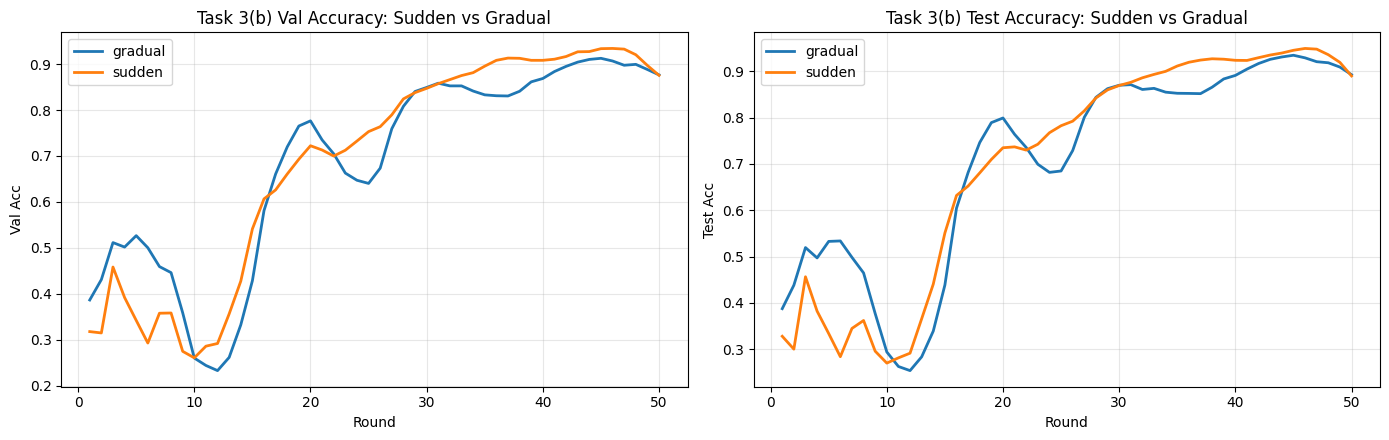

In [ ]:

_need_plot = ["task3b_label_sudden_results", "task3b_label_gradual_results"]
_missing_plot = [n for n in _need_plot if n not in globals()]
if _missing_plot:
    raise RuntimeError(f"Run Task 3(b) sudden and gradual cells first: {_missing_plot}")

plot_df = pd.concat(
    [task3b_label_sudden_results.copy(), task3b_label_gradual_results.copy()],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for mode, g in plot_df.groupby("drift_mode"):
    axes[0].plot(g["round"], g["val_acc"], linewidth=2, label=f"{mode}")
axes[0].set_title("Task 3(b) Val Accuracy: Sudden vs Gradual")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Val Acc")
axes[0].grid(alpha=0.3)
axes[0].legend()

for mode, g in plot_df.groupby("drift_mode"):
    axes[1].plot(g["round"], g["test_acc"], linewidth=2, label=f"{mode}")
axes[1].set_title("Task 3(b) Test Accuracy: Sudden vs Gradual")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Test Acc")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

task3b_label_both_results = plot_df.copy()

Task 2 vs Task 3(b) comparison table:


,final_val_acc,final_test_acc,best_val_acc,best_test_acc,drift_mode,method
0,0.453613,0.4526,0.783691,0.7997,sudden,Task2
1,0.875488,0.8897,0.934082,0.9490,sudden,Task3b
2,0.490723,0.4948,0.833496,0.8600,gradual,Task2
3,0.876465,0.8924,0.912598,0.9343,gradual,Task3b


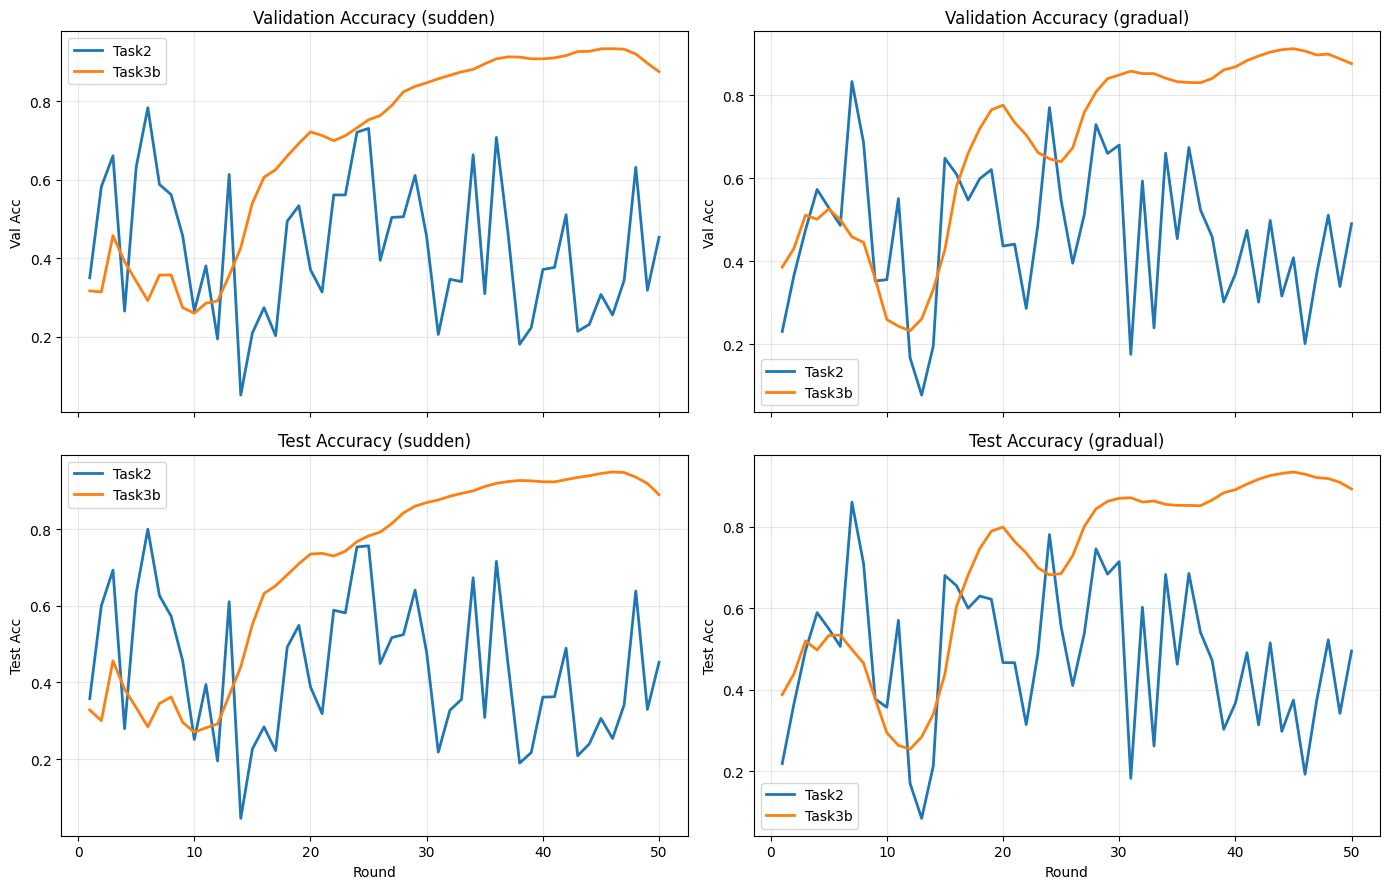

In [ ]:

_need_cmp = ["task2_label_compare_results", "task3b_label_sudden_results", "task3b_label_gradual_results"]
_missing_cmp = [n for n in _need_cmp if n not in globals()]
if _missing_cmp:
    raise RuntimeError(f"Run Task 2 and Task 3(b) sudden/gradual cells first: {_missing_cmp}")


def _to_mode_curve(df, mode, tag):
    d = df.copy()
    d = d[d["drift_mode"].astype(str).str.lower() == str(mode).lower()].copy()
    d["round"] = pd.to_numeric(d["round"], errors="coerce")
    d["val_acc"] = pd.to_numeric(d["val_acc"], errors="coerce")
    d["test_acc"] = pd.to_numeric(d["test_acc"], errors="coerce")
    d = d.dropna(subset=["round", "val_acc", "test_acc"])
    if len(d) == 0:
        return pd.DataFrame(columns=["round", "val_acc", "test_acc", "method", "drift_mode"])
    c = d.groupby("round", as_index=False)[["val_acc", "test_acc"]].mean().sort_values("round")
    c["method"] = str(tag)
    c["drift_mode"] = str(mode).lower()
    return c


def _summ(df):
    d = df.sort_values("round")
    return {
        "final_val_acc": float(d["val_acc"].iloc[-1]),
        "final_test_acc": float(d["test_acc"].iloc[-1]),
        "best_val_acc": float(d["val_acc"].max()),
        "best_test_acc": float(d["test_acc"].max()),
    }


curves = []
for mode in ["sudden", "gradual"]:
    c2 = _to_mode_curve(task2_label_compare_results, mode, "Task2")
    c3 = _to_mode_curve(
        pd.concat([task3b_label_sudden_results, task3b_label_gradual_results], ignore_index=True),
        mode,
        "Task3b",
    )
    if len(c2) > 0:
        curves.append(c2)
    if len(c3) > 0:
        curves.append(c3)

if len(curves) == 0:
    raise RuntimeError("No comparison rows available for Task 2 vs Task 3(b).")

compare_curves = pd.concat(curves, ignore_index=True)

summary_rows = []
for mode in ["sudden", "gradual"]:
    for method in ["Task2", "Task3b"]:
        sub = compare_curves[
            (compare_curves["drift_mode"].astype(str).str.lower() == mode)
            & (compare_curves["method"] == method)
        ].copy()
        if len(sub) == 0:
            continue
        s = _summ(sub)
        s["drift_mode"] = mode
        s["method"] = method
        summary_rows.append(s)

comparison_table = pd.DataFrame(summary_rows)
print("Task 2 vs Task 3(b) comparison table:")
display(comparison_table)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for mode in ["sudden", "gradual"]:
    sub = compare_curves[compare_curves["drift_mode"] == mode]

    ax = axes[0, 0] if mode == "sudden" else axes[0, 1]
    for method, g in sub.groupby("method"):
        ax.plot(g["round"], g["val_acc"], linewidth=2, label=method)
    ax.set_title(f"Validation Accuracy ({mode})")
    ax.set_ylabel("Val Acc")
    ax.grid(alpha=0.3)
    ax.legend()

    ax2 = axes[1, 0] if mode == "sudden" else axes[1, 1]
    for method, g in sub.groupby("method"):
        ax2.plot(g["round"], g["test_acc"], linewidth=2, label=method)
    ax2.set_title(f"Test Accuracy ({mode})")
    ax2.set_xlabel("Round")
    ax2.set_ylabel("Test Acc")
    ax2.grid(alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.show()